# CUTEst

In [7]:
import multiprocessing as mp
import os
import subprocess
import sys
import time
from pathlib import Path

# Each CUTEst task runs in a separate process. Keep BLAS single-threaded to avoid
# oversubscribing the machine when several worker processes run simultaneously.
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[variable] = "1"

working_directory = Path.cwd().resolve()
if (working_directory / "pyproject.toml").exists():
    repository_root = working_directory
elif (working_directory.parent / "pyproject.toml").exists():
    repository_root = working_directory.parent
else:
    raise RuntimeError("Open this notebook from the repository root or notebooks/.")
pycutest_cache = os.environ.get("PYCUTEST_CACHE")
if not pycutest_cache:
    raise RuntimeError(
        "PYCUTEST_CACHE is not set. Before starting Jupyter, run:\n"
        '  mkdir -p "$HOME/.cache/pycutest"\n'
        '  export PYCUTEST_CACHE="$HOME/.cache/pycutest"\n'
        "Then restart Jupyter and run this notebook from the first cell."
    )
pycutest_cache_root = Path(pycutest_cache).expanduser().resolve()
if not pycutest_cache_root.is_dir():
    raise RuntimeError(
        f"PYCUTEST_CACHE is not an existing directory: {pycutest_cache_root}\n"
        "Create it before starting Jupyter, then restart the kernel."
    )

import numpy as np
import pandas as pd

from data.CUTEst.check_CUTEst_problems import problemsToRun
from qnlab.experiment.for_cutest_run import (
    CUTEstTask,
    get_file_path,
    load_npz_with_metadata,
    result_matches_task,
    save_hard_timeout_result,
    scaled_iteration_limit,
    solve_problem_with_timeout,
)
from qnlab.experiment.for_cutest_vis import draw_pp
from qnlab.util.method import COLORS, LINE_STYLES, Method, get_methods

## Experiment workflow

This single workflow covers the floating-point experiments and all explicit-noise experiments reported in the paper. Results are stored under `data/temp/<scenario>/seed_<seed>/`. SciPy runs first with at most 15,000 iterations. If SciPy reaches the scenario tolerance after `k` iterations, each other solver receives at most `min(15,000, 15k)` iterations; otherwise it receives 15,000. Independent tasks run in separate child processes because CUTEst problems should not share mutable Fortran state within one process. Each child handles exactly one task and then exits, releasing its CUTEst interface and solver memory. `PYCUTEST_CACHE` must name an existing cache directory before Jupyter starts; the import cell stops with setup instructions when it is missing or invalid. Before parallel execution, any uncached CUTEst interfaces are built sequentially in that configured cache to avoid concurrent PyCUTEst cache creation. `MAX_WORKERS` controls the parallelism and defaults to at most 8; set it to 1 for sequential execution. The parent terminates a child that exceeds its task time limit plus `HARD_TIMEOUT_GRACE_SECONDS`, saves an empty hard-timeout result, and continues the batch. Start from a fresh kernel so that the cache and single-threaded BLAS settings in the import cell propagate to every child. With `OVERWRITE_EXISTING = False`, a stored result is reused only when its task-defining metadata exactly matches the current task, so an interrupted experiment can be continued without mixing incompatible settings. Crashed tasks leave no valid result and are retried on the next run; hard timeouts and matching completed results are retained. With `OVERWRITE_EXISTING = True`, every selected task is rerun and its existing result is replaced. A full run is long-running.

In [8]:
os.chdir(repository_root)
print(repository_root)
print(f"PYCUTEST_CACHE={os.environ['PYCUTEST_CACHE']}")

/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab
PYCUTEST_CACHE=/home/fifthlab/.cache/pycutest


In [9]:
PRECISION_FUNCTION_ERRORS = {
    64: np.finfo(np.float64).eps * 1e7,
    32: np.finfo(np.float32).eps * 1e4,
    16: np.finfo(np.float16).eps * 1e2,
}

SCENARIOS = {
    "float64": {
        "precision": 64,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[64],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    "float32": {
        "precision": 32,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[32],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    "float16": {
        "precision": 16,
        "function_noise": 0.0,
        "gradient_noise": 0.0,
        "assumed_function_error": PRECISION_FUNCTION_ERRORS[16],
        "solver_gtol": 1e-5,
        "score_gtols": [1e-1, 1e-3, 1e-5],
    },
    # Theory-aligned experiment: the gradient oracle is exact.
    "function_only": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    # Deliberately adverse stress test outside the exact-gradient theorem.
    "joint_noise": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 1e-3,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_under": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-4,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_nominal": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-2,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
    "eps_over": {
        "precision": 64,
        "function_noise": 1e-3,
        "gradient_noise": 0.0,
        "assumed_function_error": 1e-1,
        "solver_gtol": 1e-2,
        "score_gtols": [1e-2],
    },
}

# The checked-in configuration runs the full suite; narrow these selectors for a pilot.
MEMORY_SIZE = 10
OFFO_SQUARED_OFFSET = 1e-20
ASTR1_ADAGRAD_VARSIGMA = 1e-2
ASTR1_ADAGRAD_THETA = 1.0
RESTART_THRESHOLD = 1.0
MAX_RESTARTS = 10
MODIFIED_SECANT_MAX_RATIO = 1.0
SCENARIOS_TO_RUN = [
    "float64",
    "float32",
    "float16",
    "function_only",
    "joint_noise",
    "eps_under",
    "eps_over",
    # "eps_nominal" is unnecessary
]
RESULT_SCENARIO_ALIASES = {"eps_nominal": "function_only"}
NOISY_SEEDS = list(range(1))
PROBLEMS_TO_RUN = None  # or int to limit the number of problems for testing
METHODS_TO_RUN = None
TIME_LIMIT = 600.0
MAX_ITERATIONS = 15000
MAX_WORKERS = min(22, os.cpu_count() or 1)  # Set to 1 for sequential execution.
HARD_TIMEOUT_GRACE_SECONDS = 30
OVERWRITE_EXISTING = False
ERROR_CAUSING_TASKS = [
    (16, "INDEFM", "SciPy"),
    (16, "INDEFM", "NTRQN"),
    (16, "INDEFM", "NTRQN-MS"),
    (16, "INDEFM", "Reg-Sec"),
    (16, "OSCIGRAD", "NTRQN-MS"),
    (32, "INDEFM", "NTRQN"),
    (32, "INDEFM", "NTRQN-MS"),
    (32, "OSCIGRAD", "NTRQN-MS"),
]

## Methods and execution


In [10]:
STANDARD_LABELS = {
    "NTRQN",
    "NTRQN-MS",
    "Line",
    "Line-MS",
    "ASTR1-Adagrad",
    "Reg",
    "Reg-Sec",
    "SciPy",
    "NTQN",
}
SCENARIO_DEFAULT_LABELS = {
    "function_only": STANDARD_LABELS | {"NTRQN-Restart", "NTRQN-MS-Restart"},
    "joint_noise": STANDARD_LABELS,
    "eps_under": {"NTRQN", "NTRQN-MS", "NTRQN-Restart", "NTRQN-MS-Restart"},
    "eps_nominal": {"NTRQN", "NTRQN-MS", "NTRQN-Restart", "NTRQN-MS-Restart"},
    "eps_over": {"NTRQN", "NTRQN-MS", "NTRQN-Restart", "NTRQN-MS-Restart"},
}
# Additional diagnostic runs excluded from the primary profiles.
SCENARIO_ADDITIONAL_LABELS = {
    "function_only": {"NTQN-Default-Termination"},
}
for scenario in ("float64", "float32", "float16"):
    SCENARIO_DEFAULT_LABELS[scenario] = STANDARD_LABELS

In [11]:
def warm_cutest_cache(tasks):
    cache_entries = pycutest_cache_root / "pycutest_cache_holder"
    problem_names = sorted({task.problem_name for task in tasks})
    missing = [name for name in problem_names if not (cache_entries / name).is_dir()]
    if not missing:
        return
    print(f"Preparing {len(missing)} uncached CUTEst problem(s) sequentially.")
    command = "import pycutest, sys; pycutest.import_problem(sys.argv[1])"
    for index, problem_name in enumerate(missing, start=1):
        subprocess.run(
            [sys.executable, "-c", command, problem_name],
            check=True,
            env=os.environ.copy(),
        )
        print(f"[{index}/{len(missing)}] Cached: {problem_name}")


def run_tasks_with_workers(
    tasks, error_causing_tasks, time_limit, result_subdir=None, overwrite=False
):
    if MAX_WORKERS < 1:
        raise ValueError("MAX_WORKERS must be positive.")
    pending = [
        task
        for task in tasks
        if overwrite or not result_matches_task(task, result_subdir)
    ]
    print(f"Total tasks to run: {len(pending)} with up to {MAX_WORKERS} workers")
    if not pending:
        return
    warm_cutest_cache(pending)
    known_errors = set(error_causing_tasks)
    errors = []
    context = mp.get_context("fork")
    active = {}
    next_task = 0
    completed = 0
    try:
        while next_task < len(pending) or active:
            while next_task < len(pending) and len(active) < MAX_WORKERS:
                task = pending[next_task]
                next_task += 1
                known_error = (
                    task.precision,
                    task.problem_name,
                    task.method.label,
                ) in known_errors
                task_time_limit = 60 if known_error else time_limit
                if known_error:
                    print(
                        f"⚠ Reducing time limit for known error-causing task: "
                        f"{task.problem_name} with {task.method.label}"
                    )
                process = context.Process(
                    target=solve_problem_with_timeout,
                    args=(
                        task,
                        task_time_limit,
                        known_error or time_limit >= 600,
                        result_subdir,
                    ),
                )
                process.start()
                active[process] = (task, task_time_limit, time.monotonic())
                print(
                    f"▶ Started child pid={process.pid}: "
                    f"{task.problem_name} with {task.method.label}"
                )

            made_progress = False
            for process, (task, task_time_limit, started_at) in list(active.items()):
                elapsed = time.monotonic() - started_at
                hard_limit = task_time_limit + HARD_TIMEOUT_GRACE_SECONDS
                hard_timeout = process.is_alive() and elapsed >= hard_limit
                if hard_timeout:
                    process.terminate()
                    process.join(timeout=5)
                    if process.is_alive():
                        process.kill()
                        process.join()
                elif process.is_alive():
                    continue
                else:
                    process.join()

                completed += 1
                file_path = get_file_path(task, result_subdir)
                if hard_timeout:
                    save_hard_timeout_result(
                        task, task_time_limit, elapsed, result_subdir
                    )
                    print(
                        f"[{completed}/{len(pending)}] ⏱ Hard timeout "
                        f"after {hard_limit}s: {file_path}"
                    )
                elif process.exitcode == 0:
                    print(
                        f"[{completed}/{len(pending)}] ✓ Child exited: "
                        f"{task.problem_name} with {task.method.label}"
                    )
                else:
                    print(
                        f"[{completed}/{len(pending)}] ⚠ Child crashed "
                        f"with exit code {process.exitcode}: {file_path}"
                    )
                    errors.append(file_path)
                del active[process]
                process.close()
                made_progress = True
            if not made_progress:
                time.sleep(0.2)
    except BaseException:
        for process in active:
            if process.is_alive():
                process.terminate()
        for process in active:
            process.join()
            process.close()
        raise
    if errors:
        raise RuntimeError(
            f"{len(errors)} CUTEst task(s) crashed or hit a hard timeout. "
            "Rerun this cell to retry them; matching results will be reused."
        )


def get_experiment_methods(max_iterations, solver_gtol=None):
    common = {"m": MEMORY_SIZE, "max_iterations": max_iterations}
    methods = [
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
                "regularization_solver": "compact",
            },
        ),
        (
            Method("NTRQN", "cautious", "damped_modified", "bfgs", label="NTRQN-MS"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "max_restarts": 0,
                "regularization_solver": "compact",
                "modified_secant_max_ratio": MODIFIED_SECANT_MAX_RATIO,
            },
        ),
        (Method("Line", "raw", "raw", "bfgs", label="Line"), common),
        (
            Method("Line", "raw", "modified", "bfgs", label="Line-MS"),
            common,
        ),
        (Method("Kanzow", "raw", "raw", "bfgs", label="Reg"), common),
        (
            Method("KanzowSec", "raw", "raw", "bfgs", label="Reg-Sec"),
            common,
        ),
        (
            Method("SciPy", scipy_method="L-BFGS-B", label="SciPy"),
            {"maxcor": MEMORY_SIZE, "maxiter": max_iterations, "ftol": 0},
        ),
        (
            Method("NTQN", "raw", "raw", "bfgs", label="NTQN"),
            common | {"terminate": 1, "stop_at_gtol": 1},
        ),
        (
            Method("OFFO", label="ASTR1-Adagrad"),
            {
                "max_iterations": max_iterations,
                "varsigma": ASTR1_ADAGRAD_VARSIGMA,
                "theta": ASTR1_ADAGRAD_THETA,
            },
        ),
        (
            Method("NTRQN", "cautious", "damped", "bfgs", label="NTRQN-Restart"),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "restart_threshold": RESTART_THRESHOLD,
                "max_restarts": MAX_RESTARTS,
                "regularization_solver": "compact",
            },
        ),
        (
            Method(
                "NTRQN",
                "cautious",
                "damped_modified",
                "bfgs",
                label="NTRQN-MS-Restart",
            ),
            common
            | {
                "offo_squared_offset": OFFO_SQUARED_OFFSET,
                "restart_threshold": RESTART_THRESHOLD,
                "max_restarts": MAX_RESTARTS,
                "regularization_solver": "compact",
                "modified_secant_max_ratio": MODIFIED_SECANT_MAX_RATIO,
            },
        ),
        (
            Method("NTQN", "raw", "raw", "bfgs", label="NTQN-Default-Termination"),
            common | {"terminate": 3, "stop_at_gtol": 0},
        ),
    ]
    if solver_gtol is not None:
        methods = [
            (method, option | {"gtol": solver_gtol}) for method, option in methods
        ]
    return methods


def get_scipy_method(solver_gtol):
    methods = get_experiment_methods(MAX_ITERATIONS, solver_gtol)
    return next(entry for entry in methods if entry[0].label == "SciPy")


def get_instance_iteration_limit(scenario, seed, problem_name):
    source_scenario = RESULT_SCENARIO_ALIASES.get(scenario, scenario)
    config = SCENARIOS[source_scenario]
    scipy_method, scipy_options = get_scipy_method(config["solver_gtol"])
    scipy_task = make_task(
        source_scenario, seed, problem_name, scipy_method, scipy_options
    )
    callback, _ = load_npz_with_metadata(scipy_task, verbose=False)
    return scaled_iteration_limit(
        callback, config["solver_gtol"], maximum=MAX_ITERATIONS
    )


def get_instance_methods(scenario, seed, problem_name):
    config = SCENARIOS[scenario]
    iteration_limit = get_instance_iteration_limit(scenario, seed, problem_name)
    methods = get_experiment_methods(iteration_limit, config["solver_gtol"])
    scipy_method = get_scipy_method(config["solver_gtol"])
    return [
        scipy_method if method.label == "SciPy" else (method, options)
        for method, options in methods
    ]


def get_scenario_seeds(scenario):
    config = SCENARIOS[scenario]
    has_noise = config["function_noise"] > 0.0 or config["gradient_noise"] > 0.0
    return NOISY_SEEDS if has_noise else [0]


def make_task(scenario, seed, problem_name, method, options):
    config = SCENARIOS[scenario]
    assumed_error = config["assumed_function_error"]
    return CUTEstTask(
        problem_name=problem_name,
        method=method,
        options=options,
        precision=config["precision"],
        function_noise=np.float64(config["function_noise"]),
        gradient_noise=np.float64(config["gradient_noise"]),
        assumed_function_error=(
            None if assumed_error is None else np.float64(assumed_error)
        ),
        seed=seed,
        scenario=scenario,
    )


def result_source(scenario, seed, method):
    source_scenario = RESULT_SCENARIO_ALIASES.get(scenario, scenario)
    assert source_scenario in SCENARIOS, f"Unknown scenario: {source_scenario}"
    return source_scenario, seed


def load_scenario_results(scenario, seeds, gtol, labels=None):
    config = SCENARIOS[scenario]
    problems = problemsToRun(config["precision"])
    if type(PROBLEMS_TO_RUN) is int:
        problems = problems[:PROBLEMS_TO_RUN]
    labels = labels or METHODS_TO_RUN or SCENARIO_DEFAULT_LABELS[scenario]
    all_methods = get_experiment_methods(MAX_ITERATIONS, config["solver_gtol"])
    alg_names = [method.label for method, _ in all_methods if method.label in labels]
    instances = [(seed, problem) for seed in seeds for problem in problems]
    calls = np.full((len(alg_names), len(instances)), np.inf)
    metadata = np.empty((len(alg_names), len(instances)), dtype=object)
    metadata.fill(None)
    for instance_index, (seed, problem) in enumerate(instances):
        method_options = get_instance_methods(scenario, seed, problem)
        method_options = [entry for entry in method_options if entry[0].label in labels]
        for method_index, (method, options) in enumerate(method_options):
            source_scenario, source_seed = result_source(scenario, seed, method)
            task = make_task(source_scenario, source_seed, problem, method, options)
            callback, run_metadata = load_npz_with_metadata(task, verbose=False)
            metadata[method_index, instance_index] = run_metadata
            reached = np.flatnonzero(np.asarray(callback.gnorms) <= gtol)
            if reached.size > 0:
                calls[method_index, instance_index] = max(1, callback.calls[reached[0]])
    instance_names = [f"{problem} (seed={seed})" for seed, problem in instances]
    return alg_names, calls, instance_names, metadata


def summarize_run_metadata(alg_names, metadata):
    rows = []
    for method_index, method in enumerate(alg_names):
        entries = [entry for entry in metadata[method_index] if entry]
        statuses = [entry["status"] for entry in entries]
        return_values = [entry.get("return_code_value") for entry in entries]
        rows.append(
            {
                "method": method,
                "result files": len(entries),
                "missing files": metadata.shape[1] - len(entries),
                "completed": statuses.count("completed"),
                "timeouts": statuses.count("timeout"),
                "exceptions": statuses.count("error"),
                "error return codes": sum(
                    value is not None and value < 0 for value in return_values
                ),
            }
        )
    return pd.DataFrame(rows).set_index("method")


def summarize_diagnostics(alg_names, metadata):
    restart_rows = []
    ntqn_rows = []
    for method_index, method in enumerate(alg_names):
        diagnostics = [
            entry.get("diagnostics", {}) for entry in metadata[method_index] if entry
        ]
        if method in {"NTRQN-Restart", "NTRQN-MS-Restart"} and diagnostics:
            counts = np.asarray(
                [entry.get("OFFO accumulator restart", 0) for entry in diagnostics]
            )
            restart_rows.append(
                {
                    "method": method,
                    "mean": counts.mean(),
                    "median": np.median(counts),
                    "maximum": counts.max(),
                    "cap reached": np.count_nonzero(counts >= MAX_RESTARTS),
                }
            )
        for entry in diagnostics:
            if "NTQN termination flag" in entry:
                ntqn_rows.append(
                    {"method": method, "flag": entry["NTQN termination flag"]}
                )
    restart_summary = pd.DataFrame(restart_rows)
    ntqn_summary = (
        pd.crosstab(
            pd.Series([row["method"] for row in ntqn_rows], name="method"),
            pd.Series([row["flag"] for row in ntqn_rows], name="flag"),
        )
        if ntqn_rows
        else pd.DataFrame()
    )
    return restart_summary, ntqn_summary

In [12]:
unknown_scenarios = sorted(set(SCENARIOS_TO_RUN) - set(SCENARIOS))
if unknown_scenarios:
    raise ValueError(f"Unknown scenarios: {unknown_scenarios}")

scipy_tasks = []
instances_by_scenario = {}
for scenario in SCENARIOS_TO_RUN:
    config = SCENARIOS[scenario]
    selected_problems = problemsToRun(config["precision"])
    if type(PROBLEMS_TO_RUN) is int:
        selected_problems = selected_problems[:PROBLEMS_TO_RUN]
    instances = [
        (seed, problem)
        for seed in get_scenario_seeds(scenario)
        for problem in selected_problems
    ]
    instances_by_scenario[scenario] = instances
    scipy_method, scipy_options = get_scipy_method(config["solver_gtol"])
    scipy_tasks.extend(
        make_task(scenario, seed, problem, scipy_method, scipy_options)
        for seed, problem in instances
    )

print(f"Scenarios: {SCENARIOS_TO_RUN}")
print(f"Prepared {len(scipy_tasks)} SciPy reference tasks.")
run_tasks_with_workers(
    scipy_tasks,
    ERROR_CAUSING_TASKS,
    int(TIME_LIMIT),
    overwrite=OVERWRITE_EXISTING,
)

tasks = []
reused_task_count = 0
for scenario in SCENARIOS_TO_RUN:
    labels = METHODS_TO_RUN or (
        SCENARIO_DEFAULT_LABELS[scenario]
        | SCENARIO_ADDITIONAL_LABELS.get(scenario, set())
    )
    known_labels = {
        method.label for method, _ in get_experiment_methods(MAX_ITERATIONS)
    }
    missing = sorted(set(labels) - known_labels)
    if missing:
        raise ValueError(f"Unknown method labels: {missing}")
    for seed, problem in instances_by_scenario[scenario]:
        selected_method_options = get_instance_methods(scenario, seed, problem)
        selected_method_options = [
            entry
            for entry in selected_method_options
            if entry[0].label in labels and entry[0].label != "SciPy"
        ]
        for method, options in selected_method_options:
            source_scenario, source_seed = result_source(scenario, seed, method)
            if (source_scenario, source_seed) != (scenario, seed):
                reused_task_count += 1
                continue
            tasks.append(make_task(scenario, seed, problem, method, options))

print(f"Prepared {len(tasks)} non-SciPy tasks.")
if reused_task_count:
    print(f"Reusing {reused_task_count} equivalent stored results.")

run_tasks_with_workers(
    tasks, ERROR_CAUSING_TASKS, int(TIME_LIMIT), overwrite=OVERWRITE_EXISTING
)

Scenarios: ['float64', 'float32', 'float16', 'function_only', 'joint_noise', 'eps_under', 'eps_over']
Prepared 1472 SciPy reference tasks.
Total tasks to run: 0 with up to 22 workers
Prepared 10676 non-SciPy tasks.
Total tasks to run: 2431 with up to 22 workers
▶ Started child pid=237589: CURLY10 with NTRQN-MS
▶ Started child pid=237590: CURLY20 with NTRQN-MS
▶ Started child pid=237591: DMN15102LS with NTRQN-MS
▶ Started child pid=237592: DMN15103LS with NTRQN-MS
▶ Started child pid=237593: DMN15332LS with NTRQN-MS
▶ Started child pid=237594: DMN37142LS with NTRQN-MS
▶ Started child pid=237595: DMN37143LS with NTRQN-MS
▶ Started child pid=237596: EIGENALS with NTRQN-MS
▶ Started child pid=237597: EIGENBLS with NTRQN-MS
▶ Started child pid=237598: EIGENCLS with NTRQN-MS
▶ Started child pid=237599: FBRAIN3LS with NTRQN-MS
▶ Started child pid=237600: GENHUMPS with NTRQN-MS
▶ Started child pid=237601: INDEFM with NTRQN-MS
▶ Started child pid=237602: JIMACK with NTRQN-MS
▶ Started child pid

/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/qnlab/problem/cutest.py:70: RuntimeWarning: overflow encountered in cast
  return np.float64(x.astype(np.float32))


▶ Started child pid=242766: GAUSS2LS with NTRQN-MS
✓ FLETBV3M with NTRQN-MS
[148/2431] ✓ Child exited: FLETBV3M with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/GAUSS3LS/NTRQN-MS.npz
▶ Started child pid=242806: GAUSS3LS with NTRQN-MS
✓ FLETCHCR with NTRQN-MS
[149/2431] ✓ Child exited: FLETCHCR with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/GAUSSIAN/NTRQN-MS.npz
✓ GAUSSIAN with NTRQN-MS
▶ Started child pid=242856: GAUSSIAN with NTRQN-MS
[150/2431] ✓ Child exited: GAUSSIAN with NTRQN-MS
▶ Started child pid=242865: GBRAINLS with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/GBRAINLS/NTRQN-MS.npz
✓ GAUSS1LS with NTRQN-MS
[151/2431] ✓ Child exited: GAUSS1LS with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/GENHUMPS/NTRQN-MS.npz
▶ Started child pid=242909: GENHUMPS with NTRQN-MS
✓ GAUSS2LS with NTRQN-MS
[152/2431] ✓

/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/qnlab/problem/cutest.py:70: RuntimeWarning: overflow encountered in cast
  return np.float64(x.astype(np.float32))


✓ EIGENBLS with NTRQN-MS
[154/2431] ✓ Child exited: EIGENBLS with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/GULF/NTRQN-MS.npz
▶ Started child pid=243048: GULF with NTRQN-MS
✓ GROWTHLS with NTRQN-MS
[155/2431] ✓ Child exited: GROWTHLS with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/HAHN1LS/NTRQN-MS.npz
▶ Started child pid=243081: HAHN1LS with NTRQN-MS
✓ GULF with NTRQN-MS
[156/2431] ✓ Child exited: GULF with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/HAIRY/NTRQN-MS.npz
▶ Started child pid=243114: HAIRY with NTRQN-MS
✓ HAIRY with NTRQN-MS
[157/2431] ✓ Child exited: HAIRY with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/float32/seed_0/HATFLDD/NTRQN-MS.npz
✓ HATFLDD with NTRQN-MS
▶ Started child pid=243123: HATFLDD with NTRQN-MS
[158/2431] ✓ Child exited: HATFLDD with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguch

...

▶ Started child pid=251223: ARGTRIGLS with NTRQN-MS-Restart
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/ARGTRIGLS/NTRQN-MS-Restart.npz
✓ ARGTRIGLS with NTRQN-MS
[442/2431] ✓ Child exited: ARGTRIGLS with NTRQN-MS
✓ ARGTRIGLS with NTRQN-MS-Restart
▶ Started child pid=251263: ARWHEAD with NTRQN-MS
[443/2431] ✓ Child exited: ARGTRIGLS with NTRQN-MS-Restart
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/ARWHEAD/NTRQN-MS.npz
▶ Started child pid=251268: ARWHEAD with NTRQN-MS-Restart
✓ ARWHEAD with NTRQN-MS
✓ TOINTQOR with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/ARWHEAD/NTRQN-MS-Restart.npz
[444/2431] ✓ Child exited: ARWHEAD with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/BA-L1LS/NTRQN-MS.npz
✓ ARWHEAD with NTRQN-MS-Restart
✓ BA-L1LS with NTRQN-MS
▶ Started child pid=251285: BA-L1LS with NTRQN-MS
[445/2431] ✓

/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/qnlab/problem/cutest.py:63: RuntimeWarning: overflow encountered in cast
  return x.astype(np.float16).astype(np.float64)


[454/2431] ✓ Child exited: BEALE with NTRQN-MS-Restart
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/BENNETT5LS/NTRQN-MS.npz
✓ BENNETT5LS with NTRQN-MS


/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/qnlab/util/check_termination.py:21: RuntimeWarning: invalid value encountered in scalar subtract
  if 0 < param.past <= len(pf) and abs(max(pf) - fx) < param.ftol * abs(fx):
/home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/qnlab/util/check_termination.py:21: RuntimeWarning: invalid value encountered in scalar multiply
  if 0 < param.past <= len(pf) and abs(max(pf) - fx) < param.ftol * abs(fx):


▶ Started child pid=251394: BENNETT5LS with NTRQN-MS
[455/2431] ✓ Child exited: BENNETT5LS with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/BENNETT5LS/NTRQN-MS-Restart.npz
✓ BENNETT5LS with NTRQN-MS-Restart
▶ Started child pid=251428: BENNETT5LS with NTRQN-MS-Restart
[456/2431] ✓ Child exited: BENNETT5LS with NTRQN-MS-Restart
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/BIGGS6/NTRQN-MS.npz
✓ BIGGS6 with NTRQN-MS
▶ Started child pid=251437: BIGGS6 with NTRQN-MS
[457/2431] ✓ Child exited: BIGGS6 with NTRQN-MS
▶ Running: /home/fifthlab/ドキュメント/HirokiHamaguchi/qnlab/data/temp/function_only/seed_0/BIGGS6/NTRQN-MS-Restart.npz
✓ BIGGS6 with NTRQN-MS-Restart
▶ Started child pid=251446: BIGGS6 with NTRQN-MS-Restart
[458/2431] ✓ Child exited: BIGGS6 with NTRQN-MS-Restart
✓ BDQRTIC with NTRQN-MS-Restart
▶ Started child pid=251457: BOX with NTRQN-MS
[459/2431] ✓ Child exited: BDQRTIC with NTRQN-MS-Restart
▶ 

## Visualize saved results

Select scenarios after their runs have completed. The default empty list avoids overwriting existing figures accidentally.

Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-01.pdf


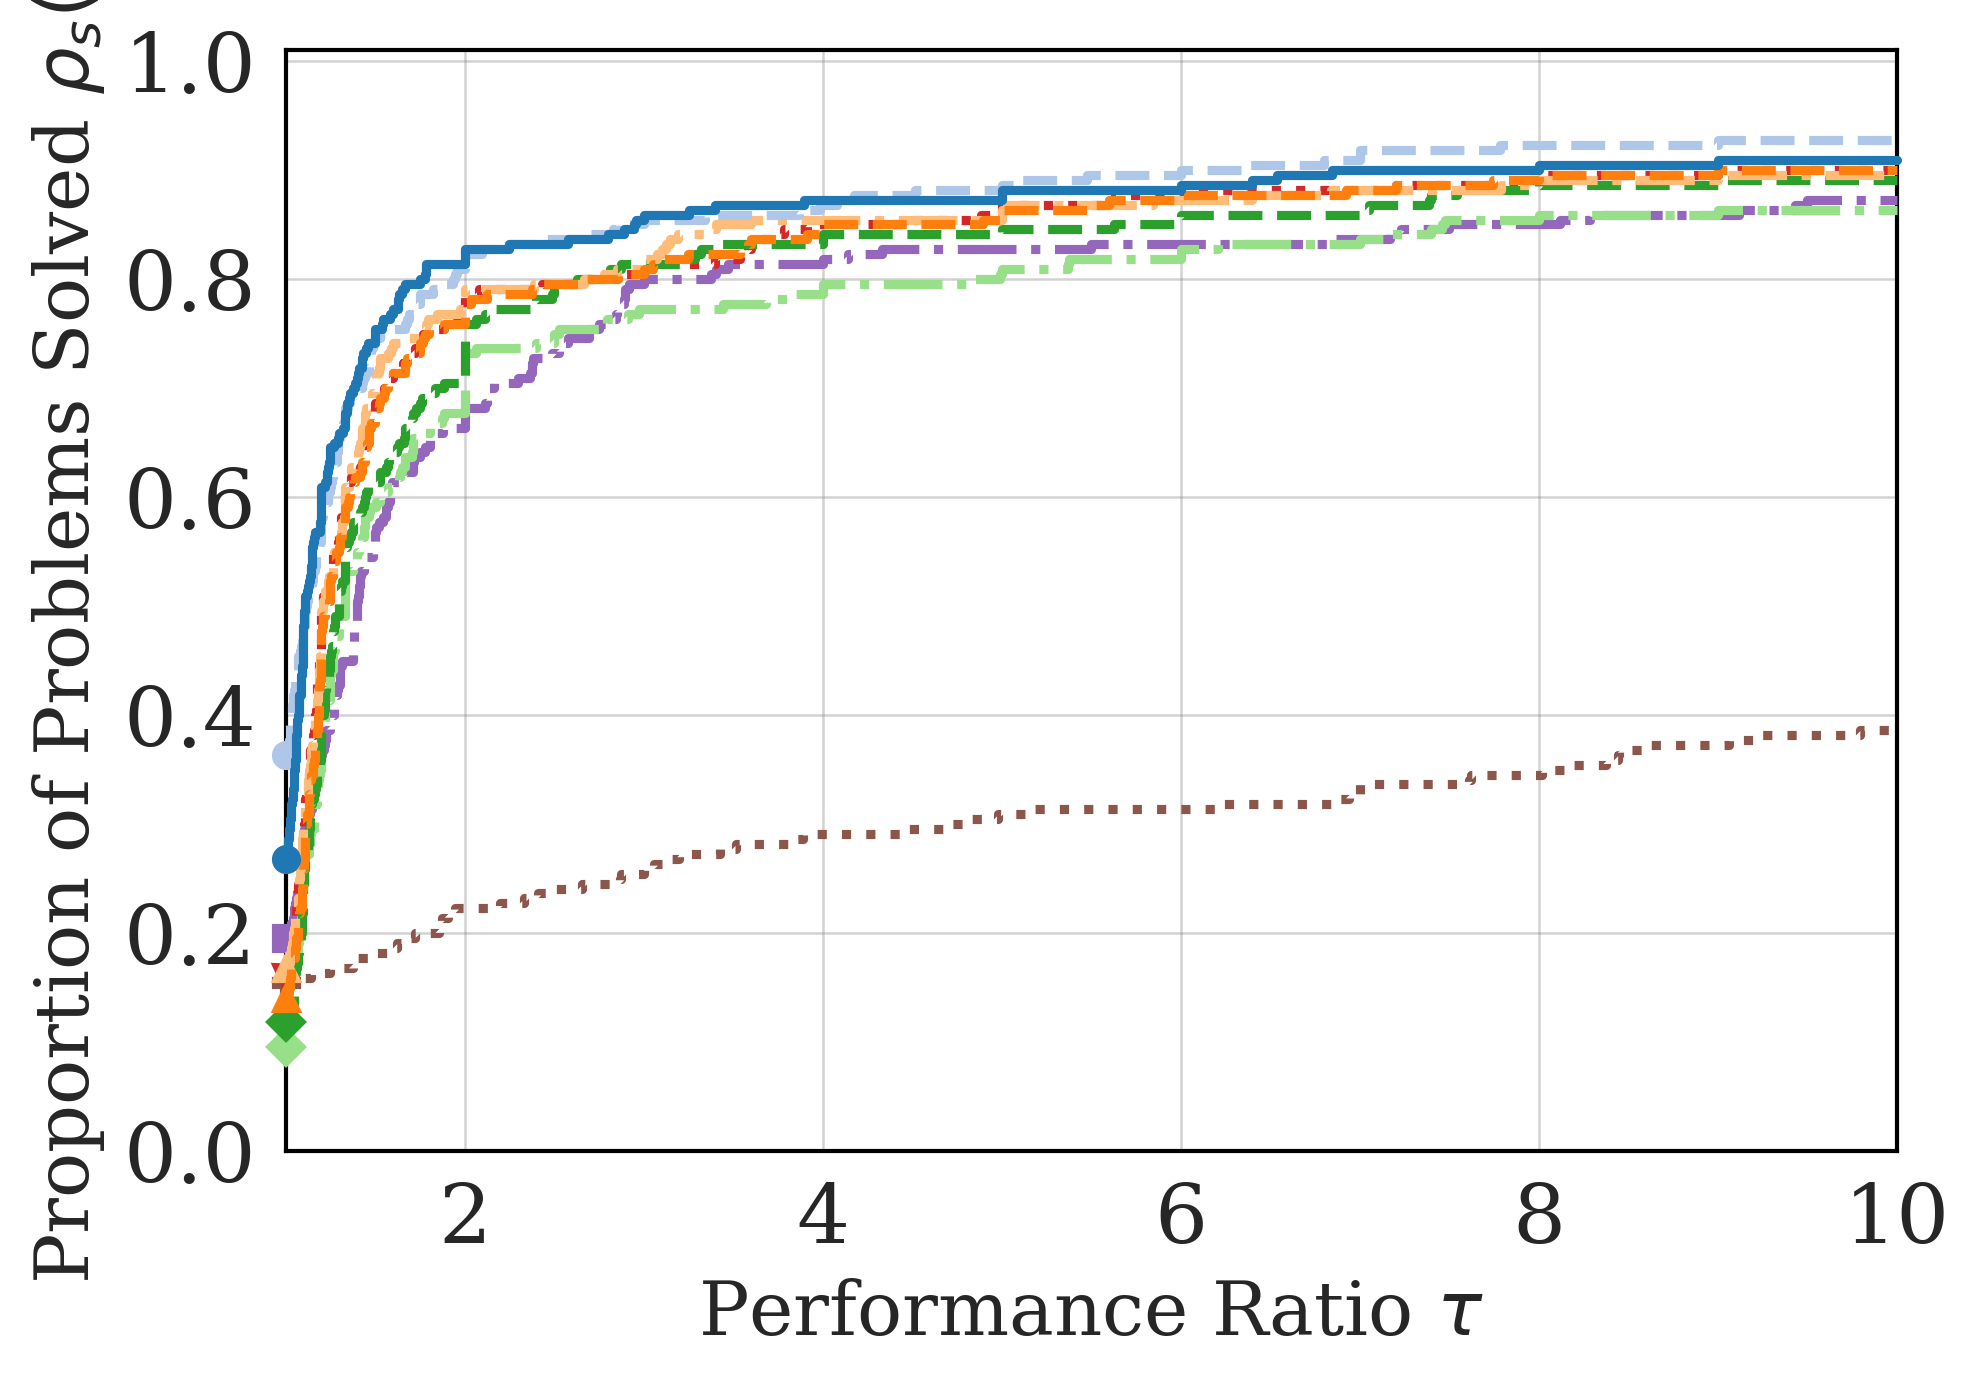

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-01.pdf


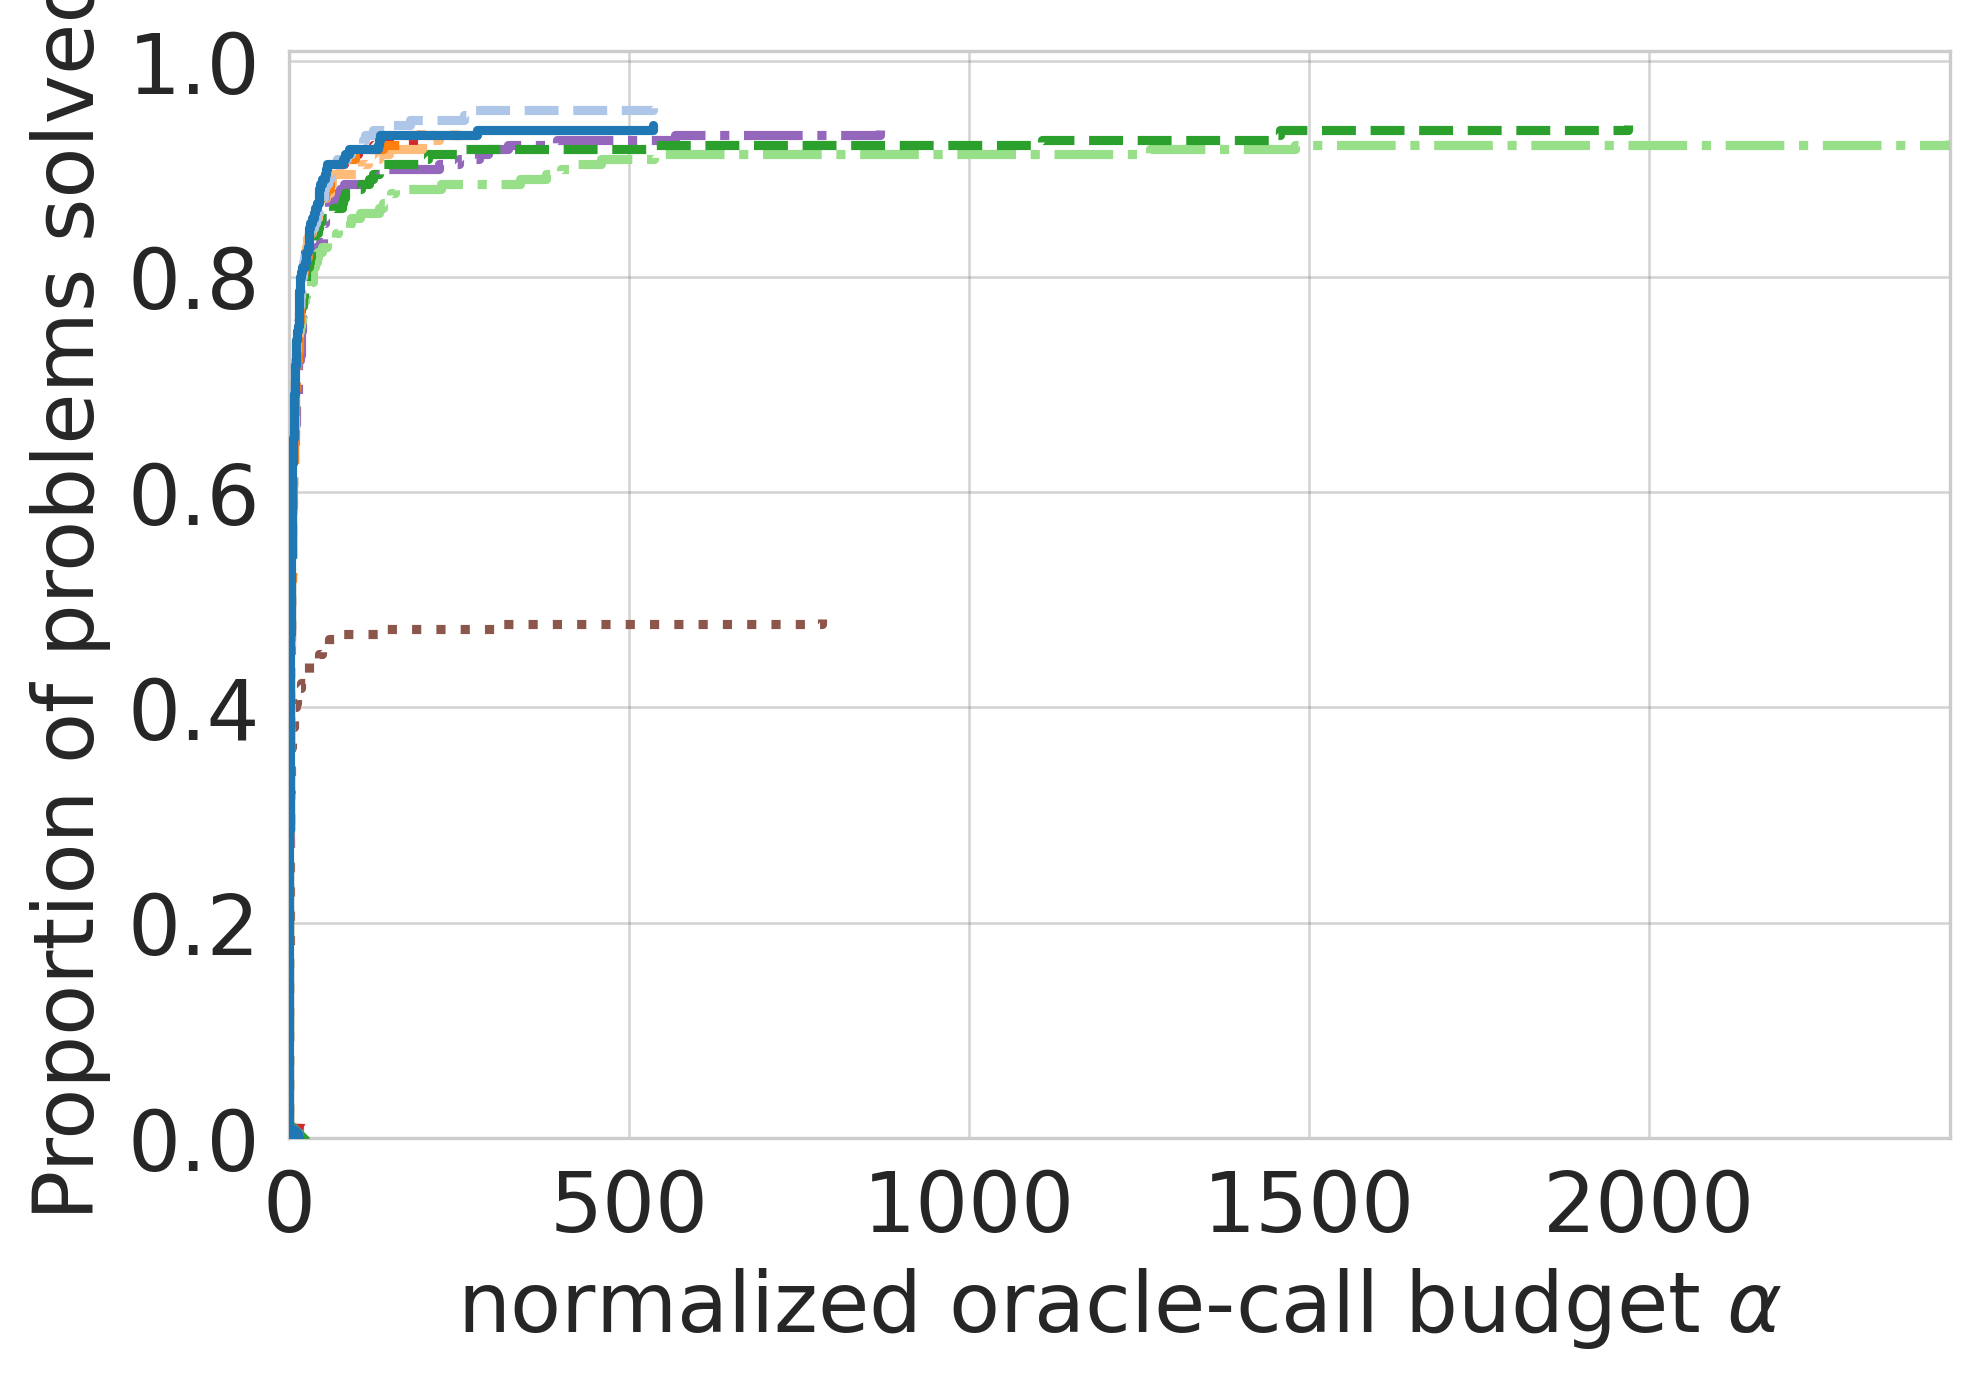

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),45.0,43.0,40.0,36.0,41.0,39.0,40.0,inf,inf
ALLINITU (seed=0),19.0,19.0,20.0,20.0,20.0,20.0,20.0,21.0,37.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,12.0,12.0,8.0,5.0,8.0
ARGLINB (seed=0),8.0,8.0,8.0,8.0,10.0,10.0,8.0,42.0,4.0
ARGLINC (seed=0),6.0,8.0,8.0,8.0,10.0,10.0,8.0,42.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),40.0,36.0,40.0,42.0,44.0,44.0,40.0,65.0,770.0
YATP1LS (seed=0),37.0,36.0,50.0,50.0,46.0,46.0,50.0,77.0,inf
YATP2LS (seed=0),38.0,35.0,46.0,48.0,49.0,49.0,46.0,26.0,inf
YFITU (seed=0),172.0,155.0,186.0,178.0,168.0,223.0,182.0,198.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,94.090909,26.818182
NTRQN-MS,95.909091,36.363636
Line,93.636364,14.090909
Line-MS,93.636364,16.818182
Reg,94.090909,11.818182
Reg-Sec,92.727273,9.545455
SciPy,93.636364,15.909091
NTQN,93.636364,19.545455
ASTR1-Adagrad,48.181818,15.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,217,3,0,31
NTRQN-MS,220,0,215,5,0,27
Line,220,0,219,1,0,53
Line-MS,220,0,219,1,0,50
Reg,220,0,217,3,0,36
Reg-Sec,220,0,217,3,0,44
SciPy,220,0,215,5,0,22
NTQN,220,0,214,6,0,7
ASTR1-Adagrad,220,0,217,3,0,181


flag,0,1,6
method,,,
NTQN,184,7,23


Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-03.pdf


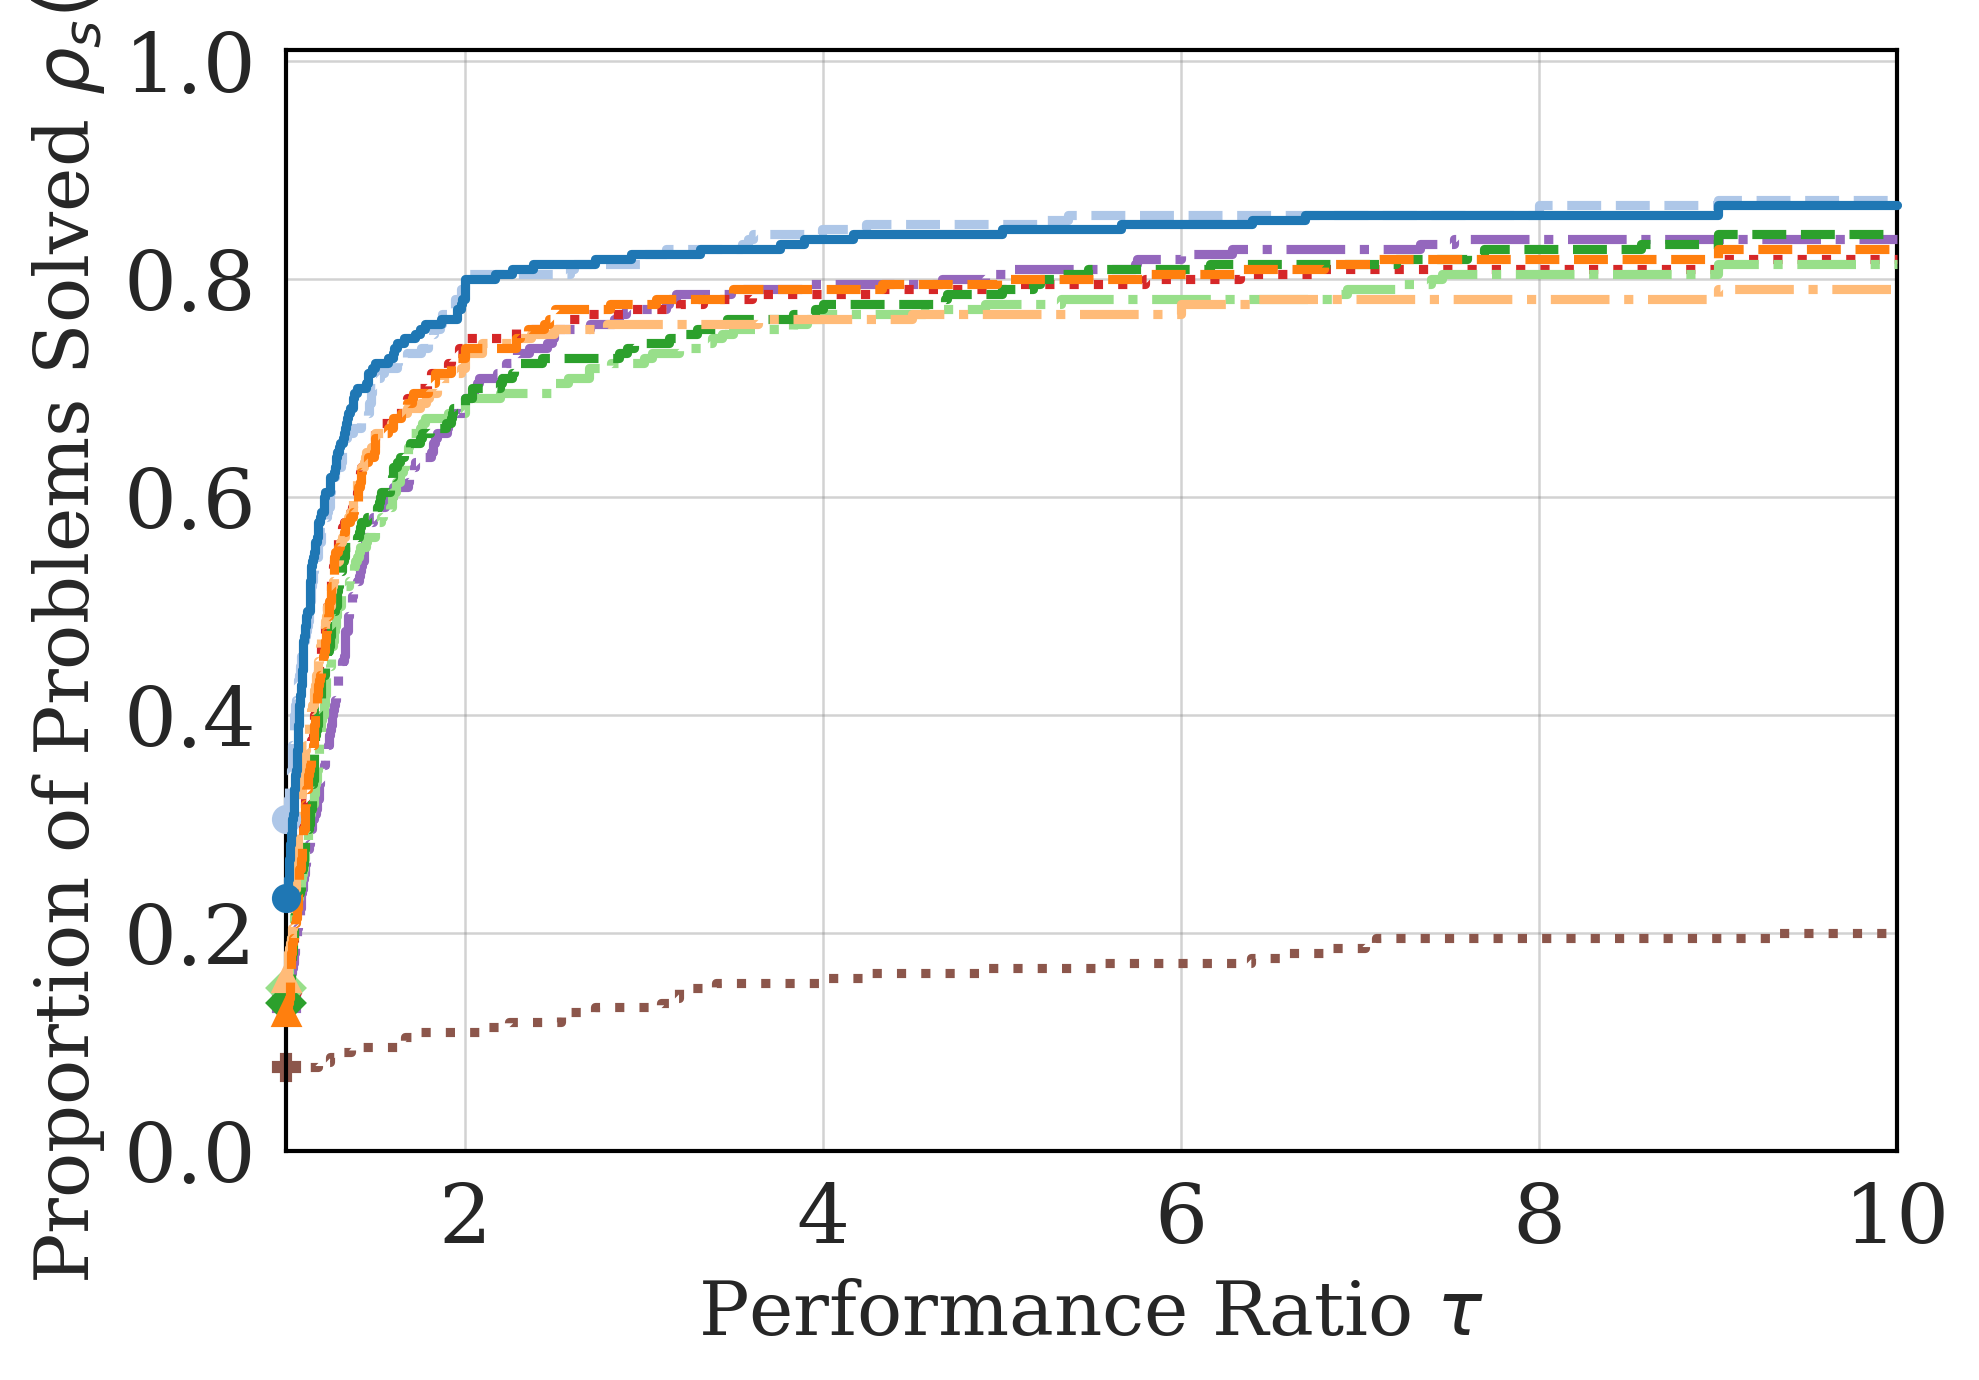

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-03.pdf


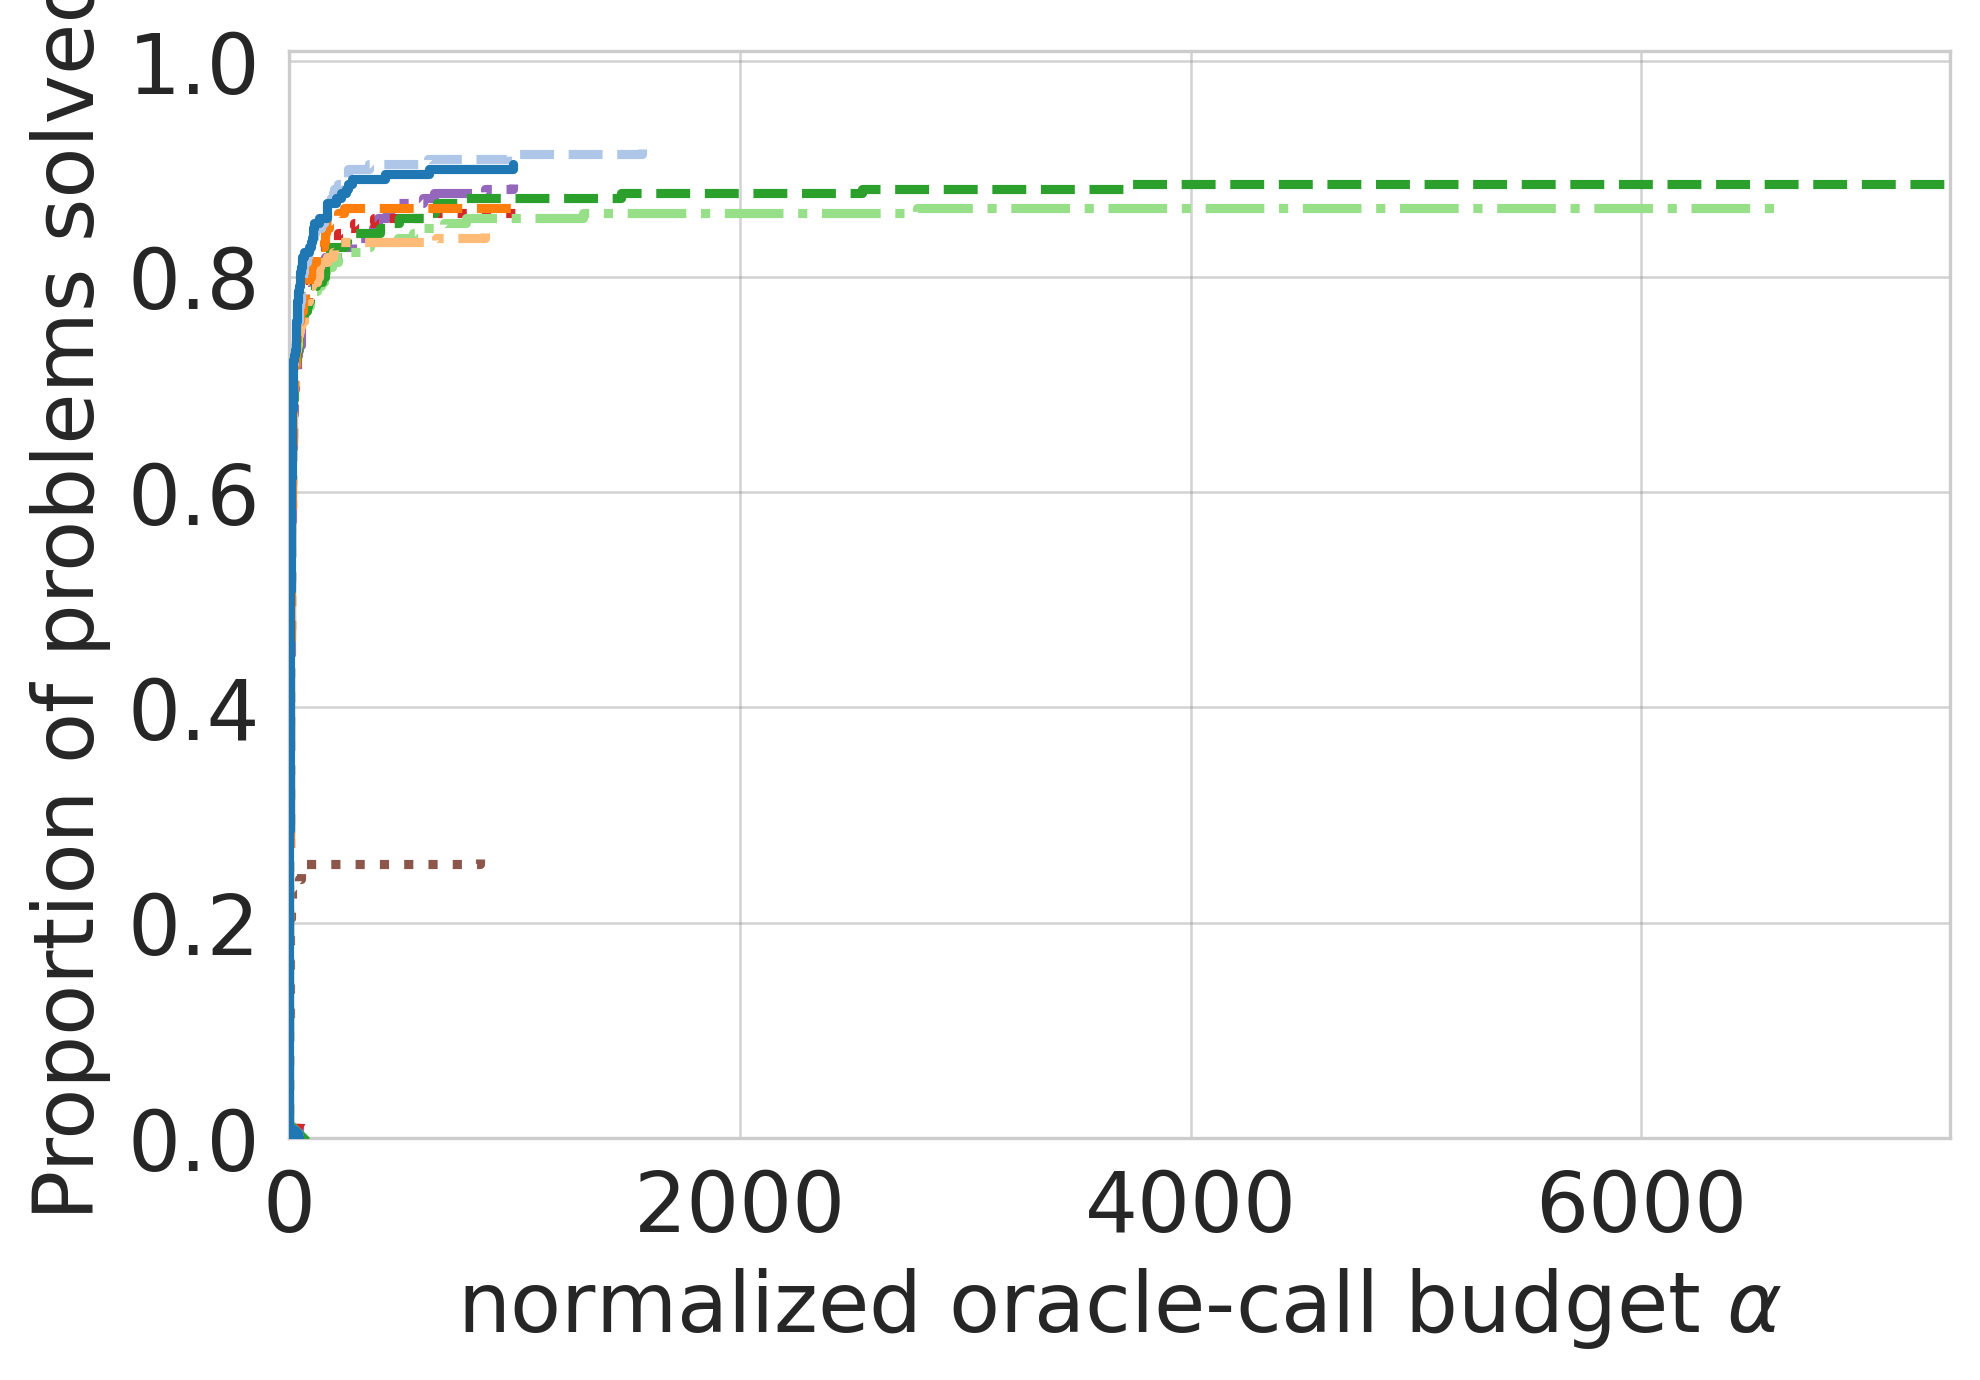

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),49.0,47.0,44.0,38.0,49.0,49.0,44.0,inf,inf
ALLINITU (seed=0),23.0,23.0,24.0,26.0,22.0,24.0,24.0,25.0,60.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,16.0,16.0,8.0,5.0,16.0
ARGLINB (seed=0),8.0,12.0,inf,inf,inf,12.0,inf,69.0,4.0
ARGLINC (seed=0),8.0,8.0,10.0,10.0,inf,10.0,inf,58.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),214.0,189.0,224.0,204.0,289.0,247.0,234.0,73.0,inf
YATP1LS (seed=0),41.0,36.0,54.0,52.0,46.0,46.0,54.0,79.0,inf
YATP2LS (seed=0),38.0,37.0,50.0,48.0,53.0,53.0,50.0,26.0,inf
YFITU (seed=0),176.0,163.0,190.0,182.0,315.0,260.0,188.0,204.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,90.454545,23.181818
NTRQN-MS,91.818182,30.454545
Line,86.818182,12.727273
Line-MS,84.090909,15.909091
Reg,89.090909,13.636364
Reg-Sec,86.818182,15.000000
SciPy,86.363636,13.181818
NTQN,88.636364,14.090909
ASTR1-Adagrad,25.909091,7.727273


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,217,3,0,31
NTRQN-MS,220,0,215,5,0,27
Line,220,0,219,1,0,53
Line-MS,220,0,219,1,0,50
Reg,220,0,217,3,0,36
Reg-Sec,220,0,217,3,0,44
SciPy,220,0,215,5,0,22
NTQN,220,0,214,6,0,7
ASTR1-Adagrad,220,0,217,3,0,181


flag,0,1,6
method,,,
NTQN,184,7,23


Saved figure to doc/imgs/compare/_pp_precision64_gtol1e-05.pdf


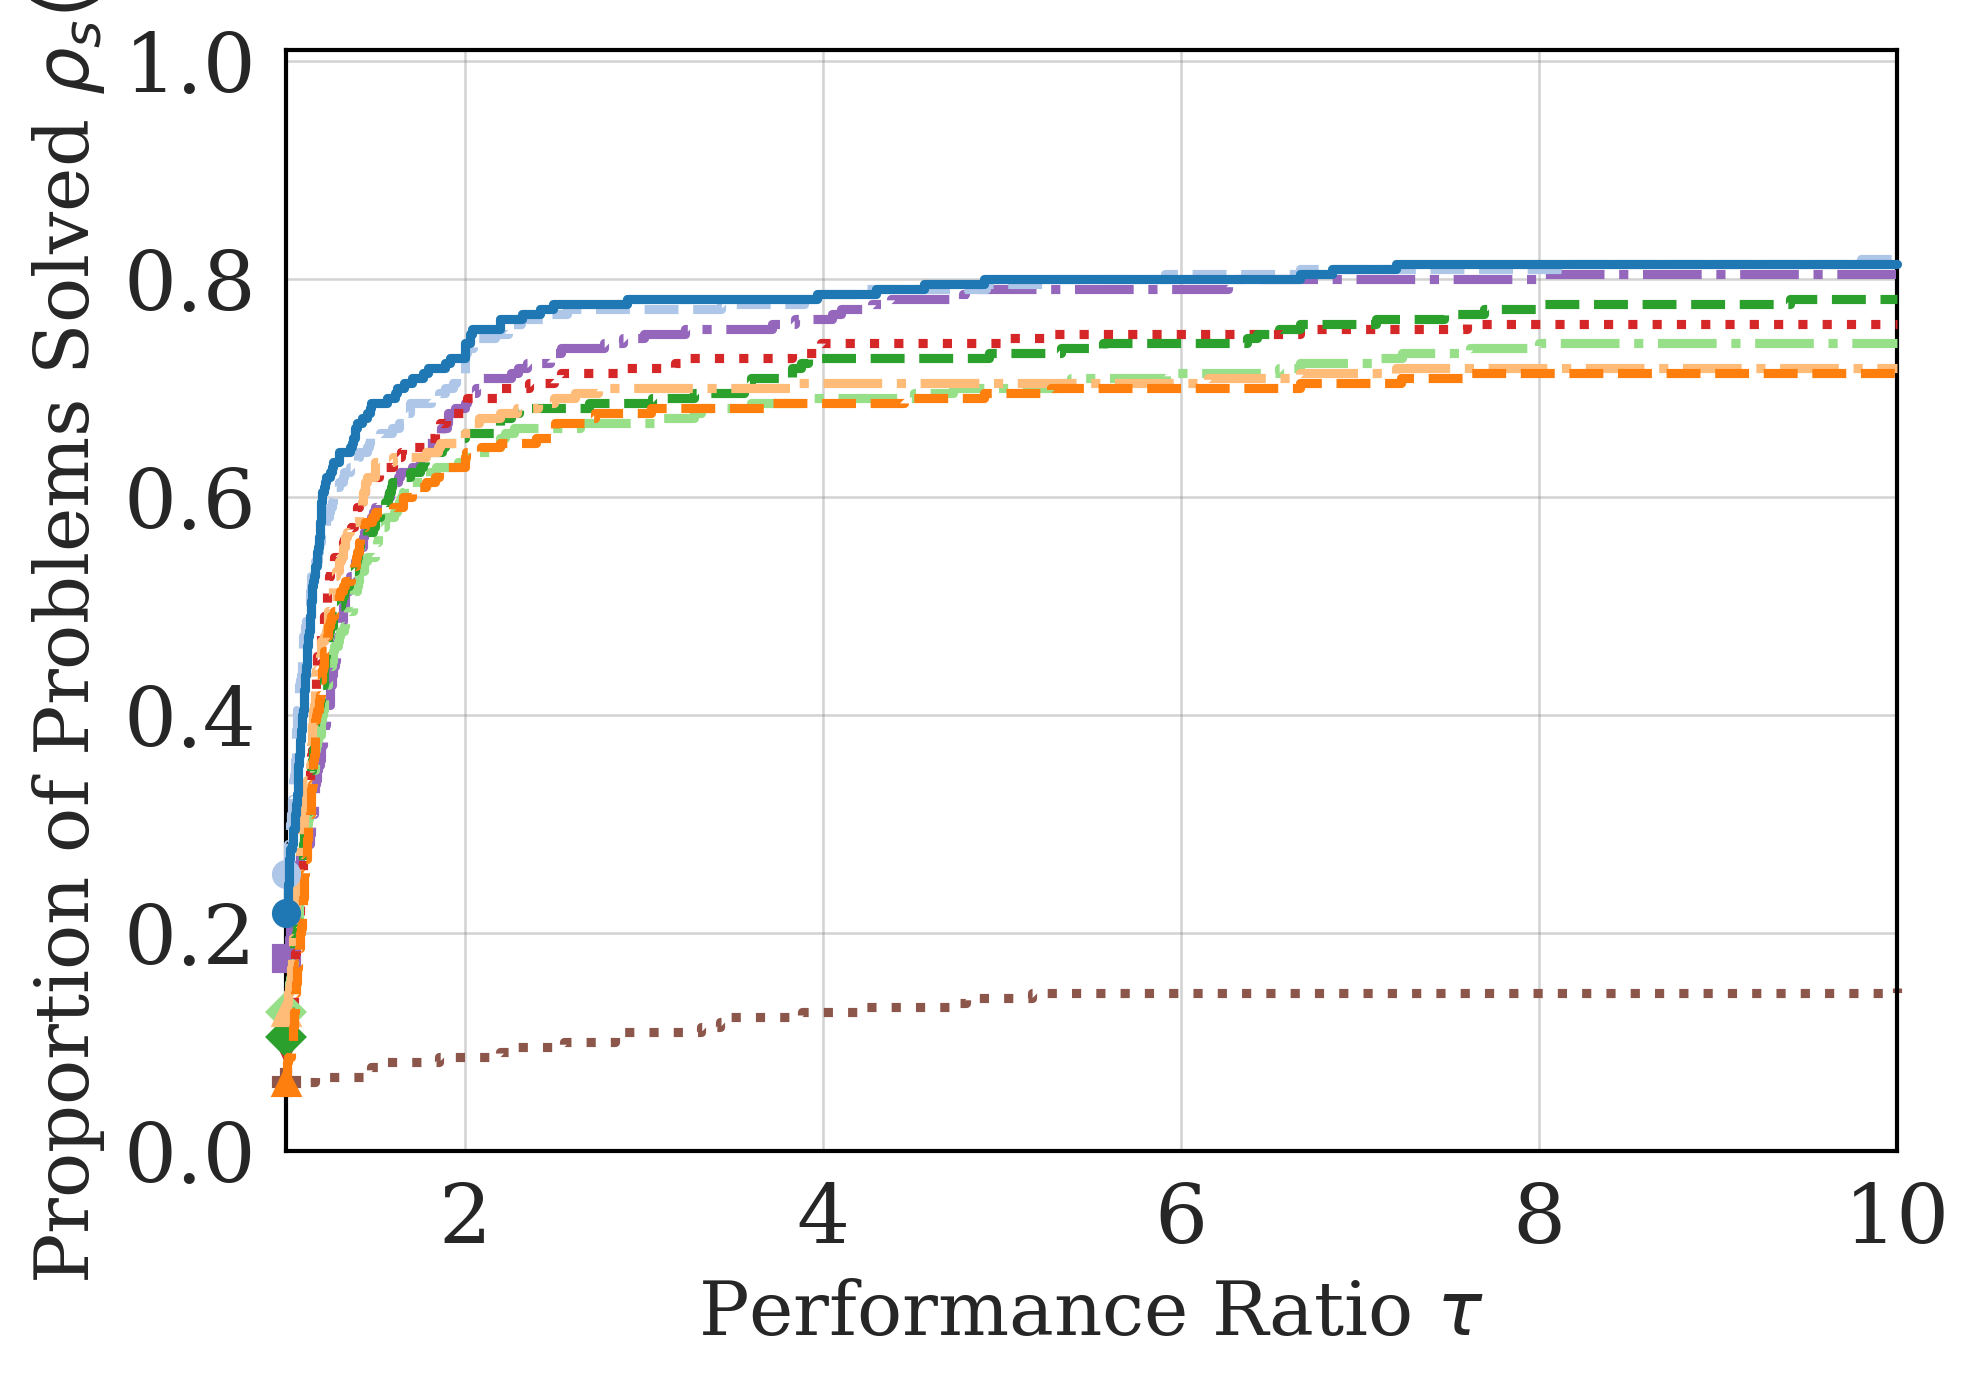

Saved figure to doc/imgs/compare/_dp_float64_gtol1e-05.pdf


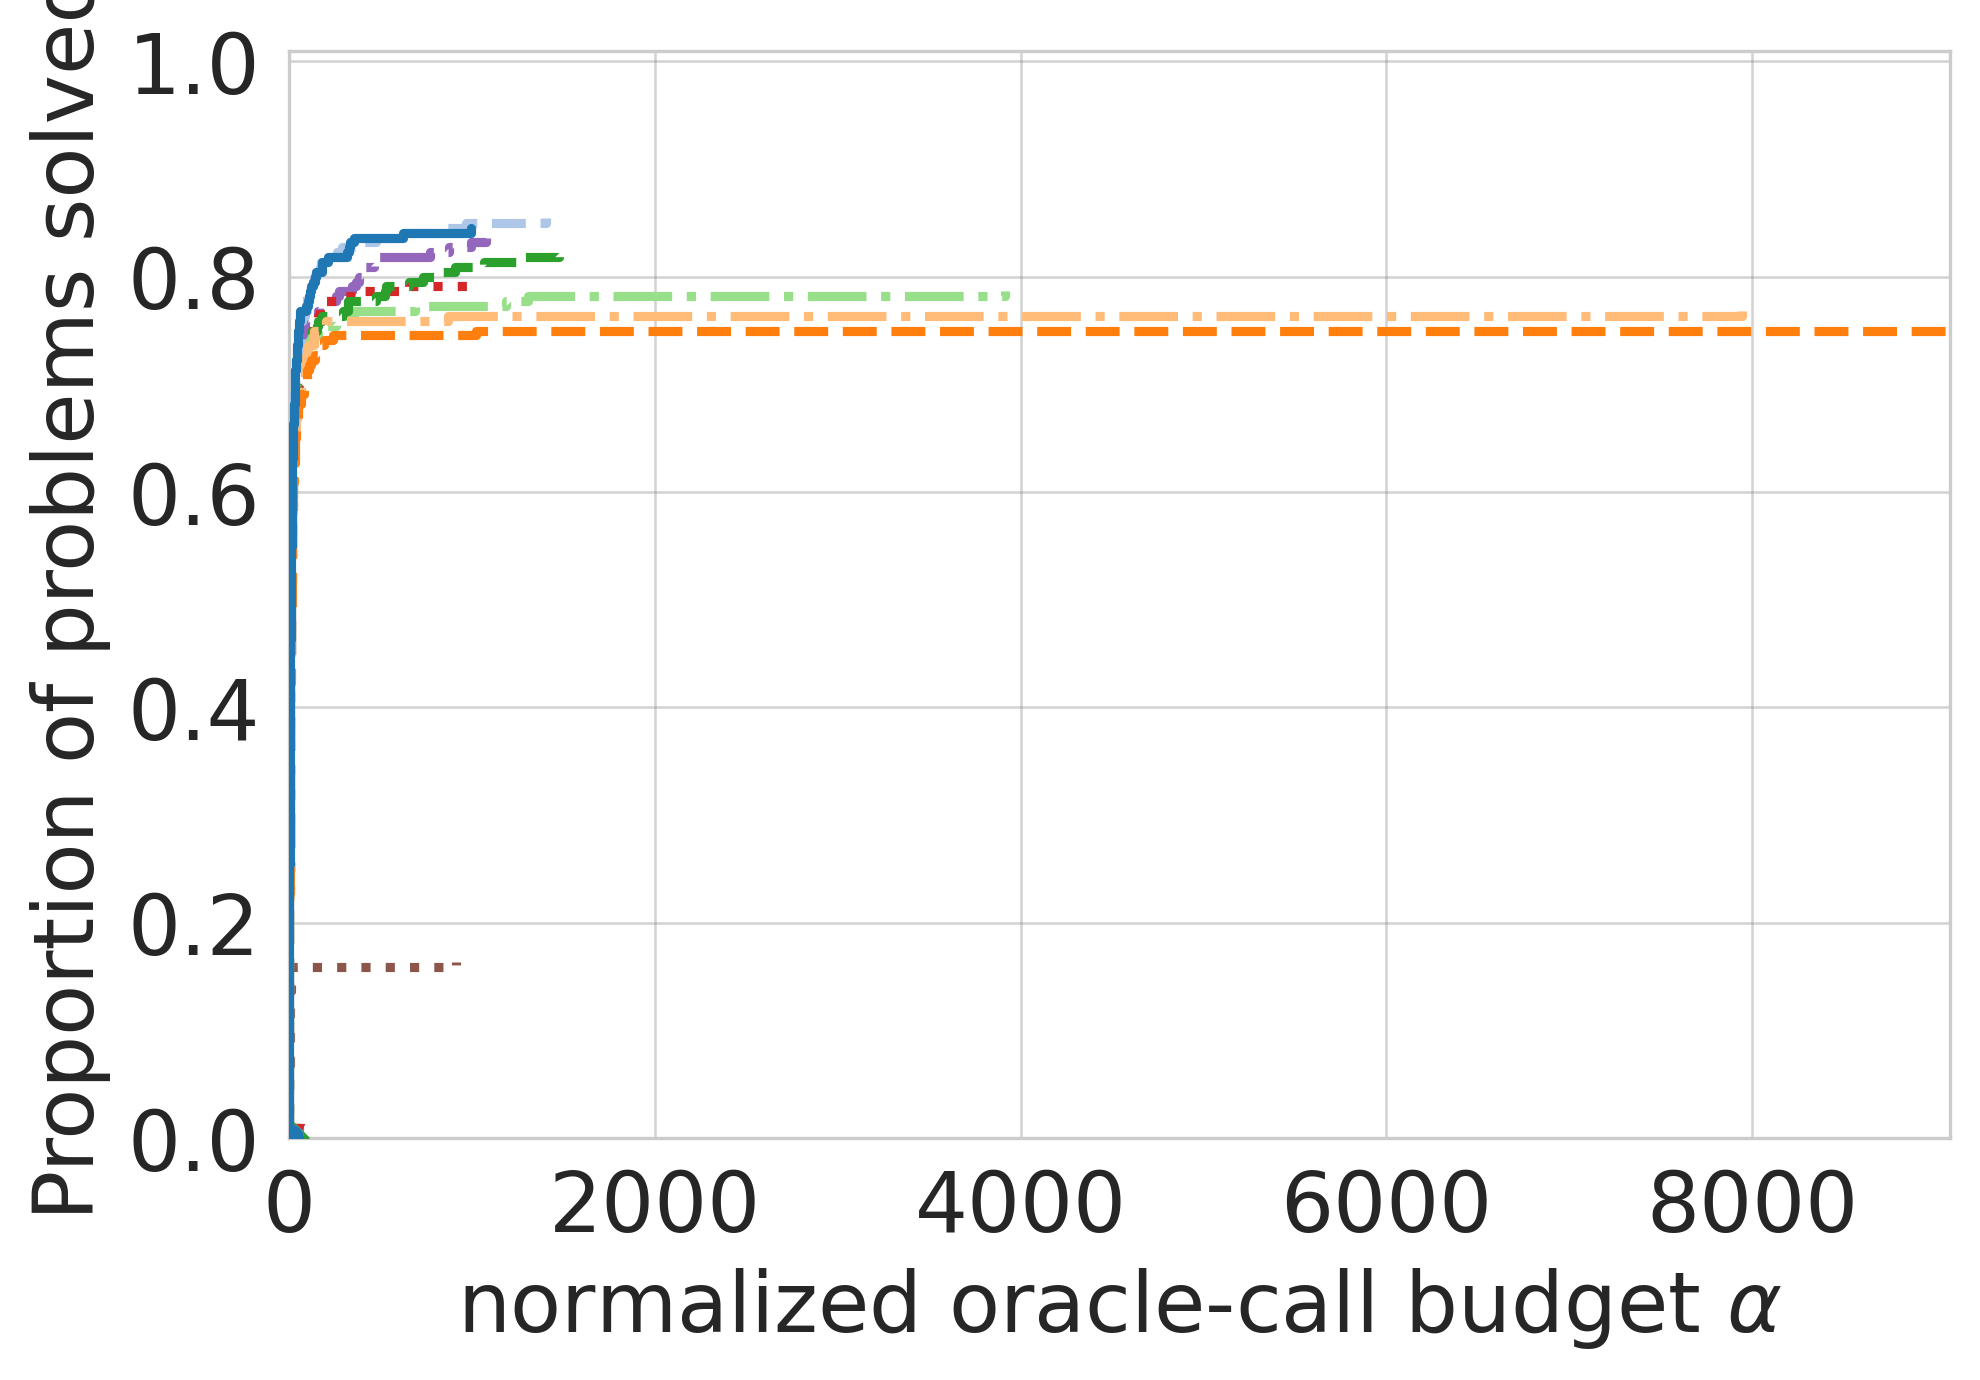

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),51.0,49.0,46.0,42.0,51.0,51.0,46.0,inf,inf
ALLINITU (seed=0),25.0,27.0,26.0,28.0,26.0,26.0,26.0,29.0,83.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,18.0,18.0,8.0,5.0,24.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,63.0,inf,inf,4.0
ARGLINC (seed=0),inf,540.0,inf,inf,inf,inf,inf,97.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),218.0,193.0,228.0,206.0,291.0,249.0,238.0,75.0,inf
YATP1LS (seed=0),43.0,38.0,54.0,54.0,48.0,48.0,54.0,79.0,inf
YATP2LS (seed=0),38.0,39.0,50.0,50.0,53.0,55.0,50.0,28.0,inf
YFITU (seed=0),180.0,163.0,196.0,190.0,323.0,262.0,190.0,206.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,84.545455,21.818182
NTRQN-MS,85.454545,25.454545
Line,75.454545,6.363636
Line-MS,76.818182,12.727273
Reg,82.272727,10.454545
Reg-Sec,78.636364,12.727273
SciPy,79.545455,9.545455
NTQN,83.636364,17.727273
ASTR1-Adagrad,16.363636,6.363636


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,217,3,0,31
NTRQN-MS,220,0,215,5,0,27
Line,220,0,219,1,0,53
Line-MS,220,0,219,1,0,50
Reg,220,0,217,3,0,36
Reg-Sec,220,0,217,3,0,44
SciPy,220,0,215,5,0,22
NTQN,220,0,214,6,0,7
ASTR1-Adagrad,220,0,217,3,0,181


flag,0,1,6
method,,,
NTQN,184,7,23


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-01.pdf


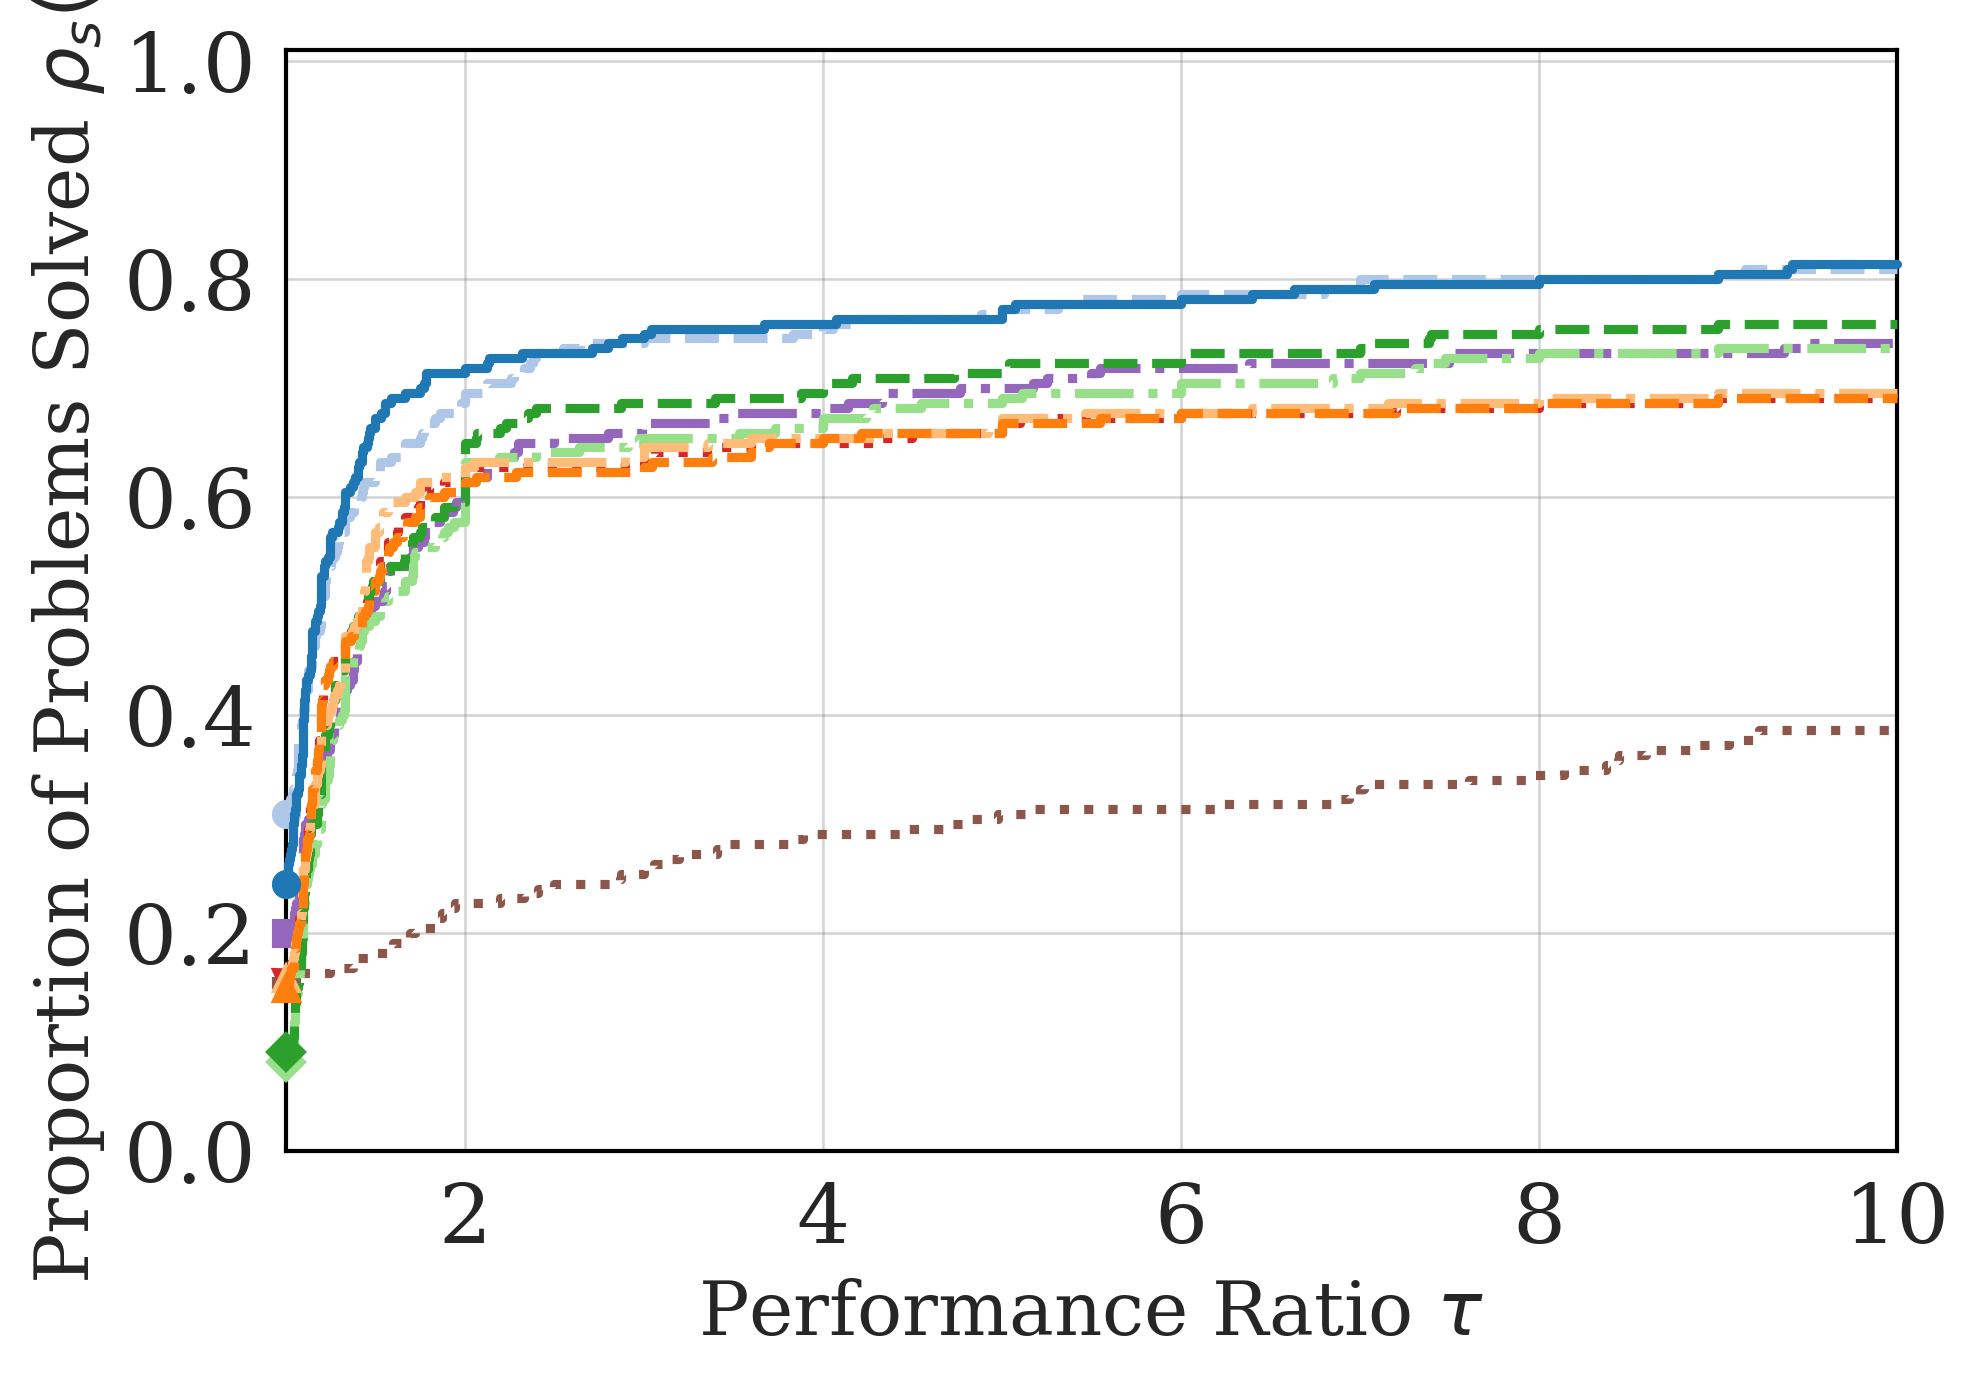

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-01.pdf


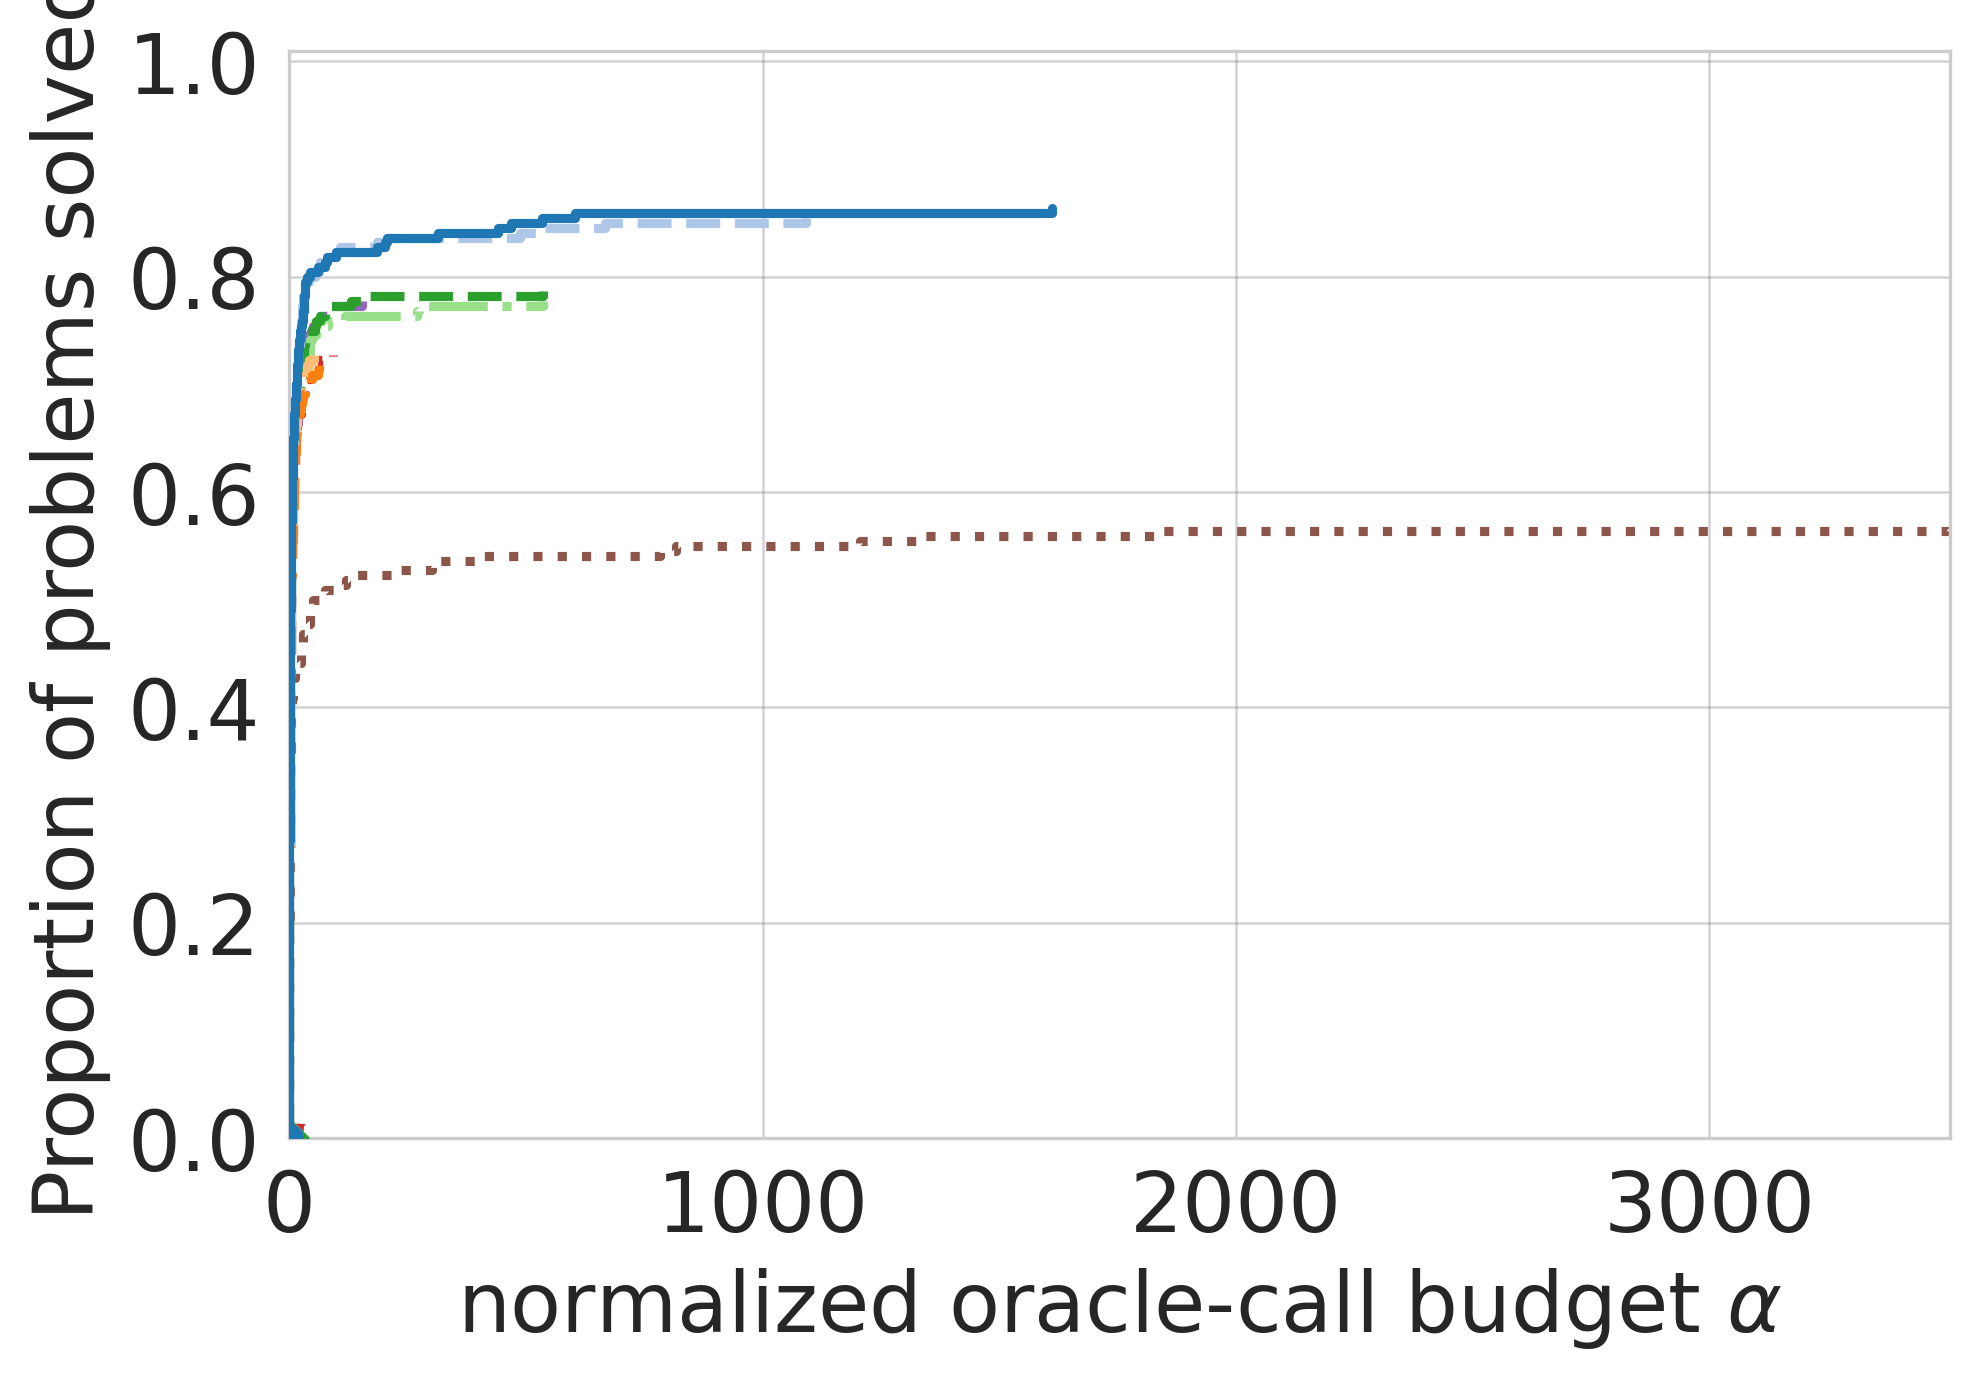

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),45.0,43.0,40.0,36.0,41.0,39.0,40.0,inf,3615.0
ALLINITU (seed=0),19.0,19.0,20.0,20.0,20.0,20.0,20.0,21.0,37.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,12.0,12.0,8.0,5.0,8.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,4.0
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,5.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),40.0,36.0,40.0,42.0,44.0,44.0,40.0,65.0,770.0
YATP1LS (seed=0),35.0,35.0,50.0,50.0,44.0,48.0,50.0,77.0,inf
YATP2LS (seed=0),244.0,238.0,46.0,48.0,49.0,49.0,46.0,26.0,inf
YFITU (seed=0),129.0,116.0,192.0,168.0,259.0,221.0,192.0,183.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,86.363636,24.545455
NTRQN-MS,85.454545,30.909091
Line,71.818182,15.000000
Line-MS,72.727273,15.909091
Reg,78.636364,9.090909
Reg-Sec,77.727273,8.181818
SciPy,72.727273,15.454545
NTQN,77.727273,20.000000
ASTR1-Adagrad,56.818182,15.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,213,7,0,98
NTRQN-MS,220,0,207,13,0,91
Line,220,0,220,0,0,155
Line-MS,220,0,220,0,0,154
Reg,220,0,217,1,2,120
Reg-Sec,220,0,219,1,0,125
SciPy,220,0,220,0,0,18
NTQN,220,0,217,3,0,2
ASTR1-Adagrad,220,0,216,4,0,173


flag,0,1,2,6
method,,,,
NTQN,108,1,1,107


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-03.pdf


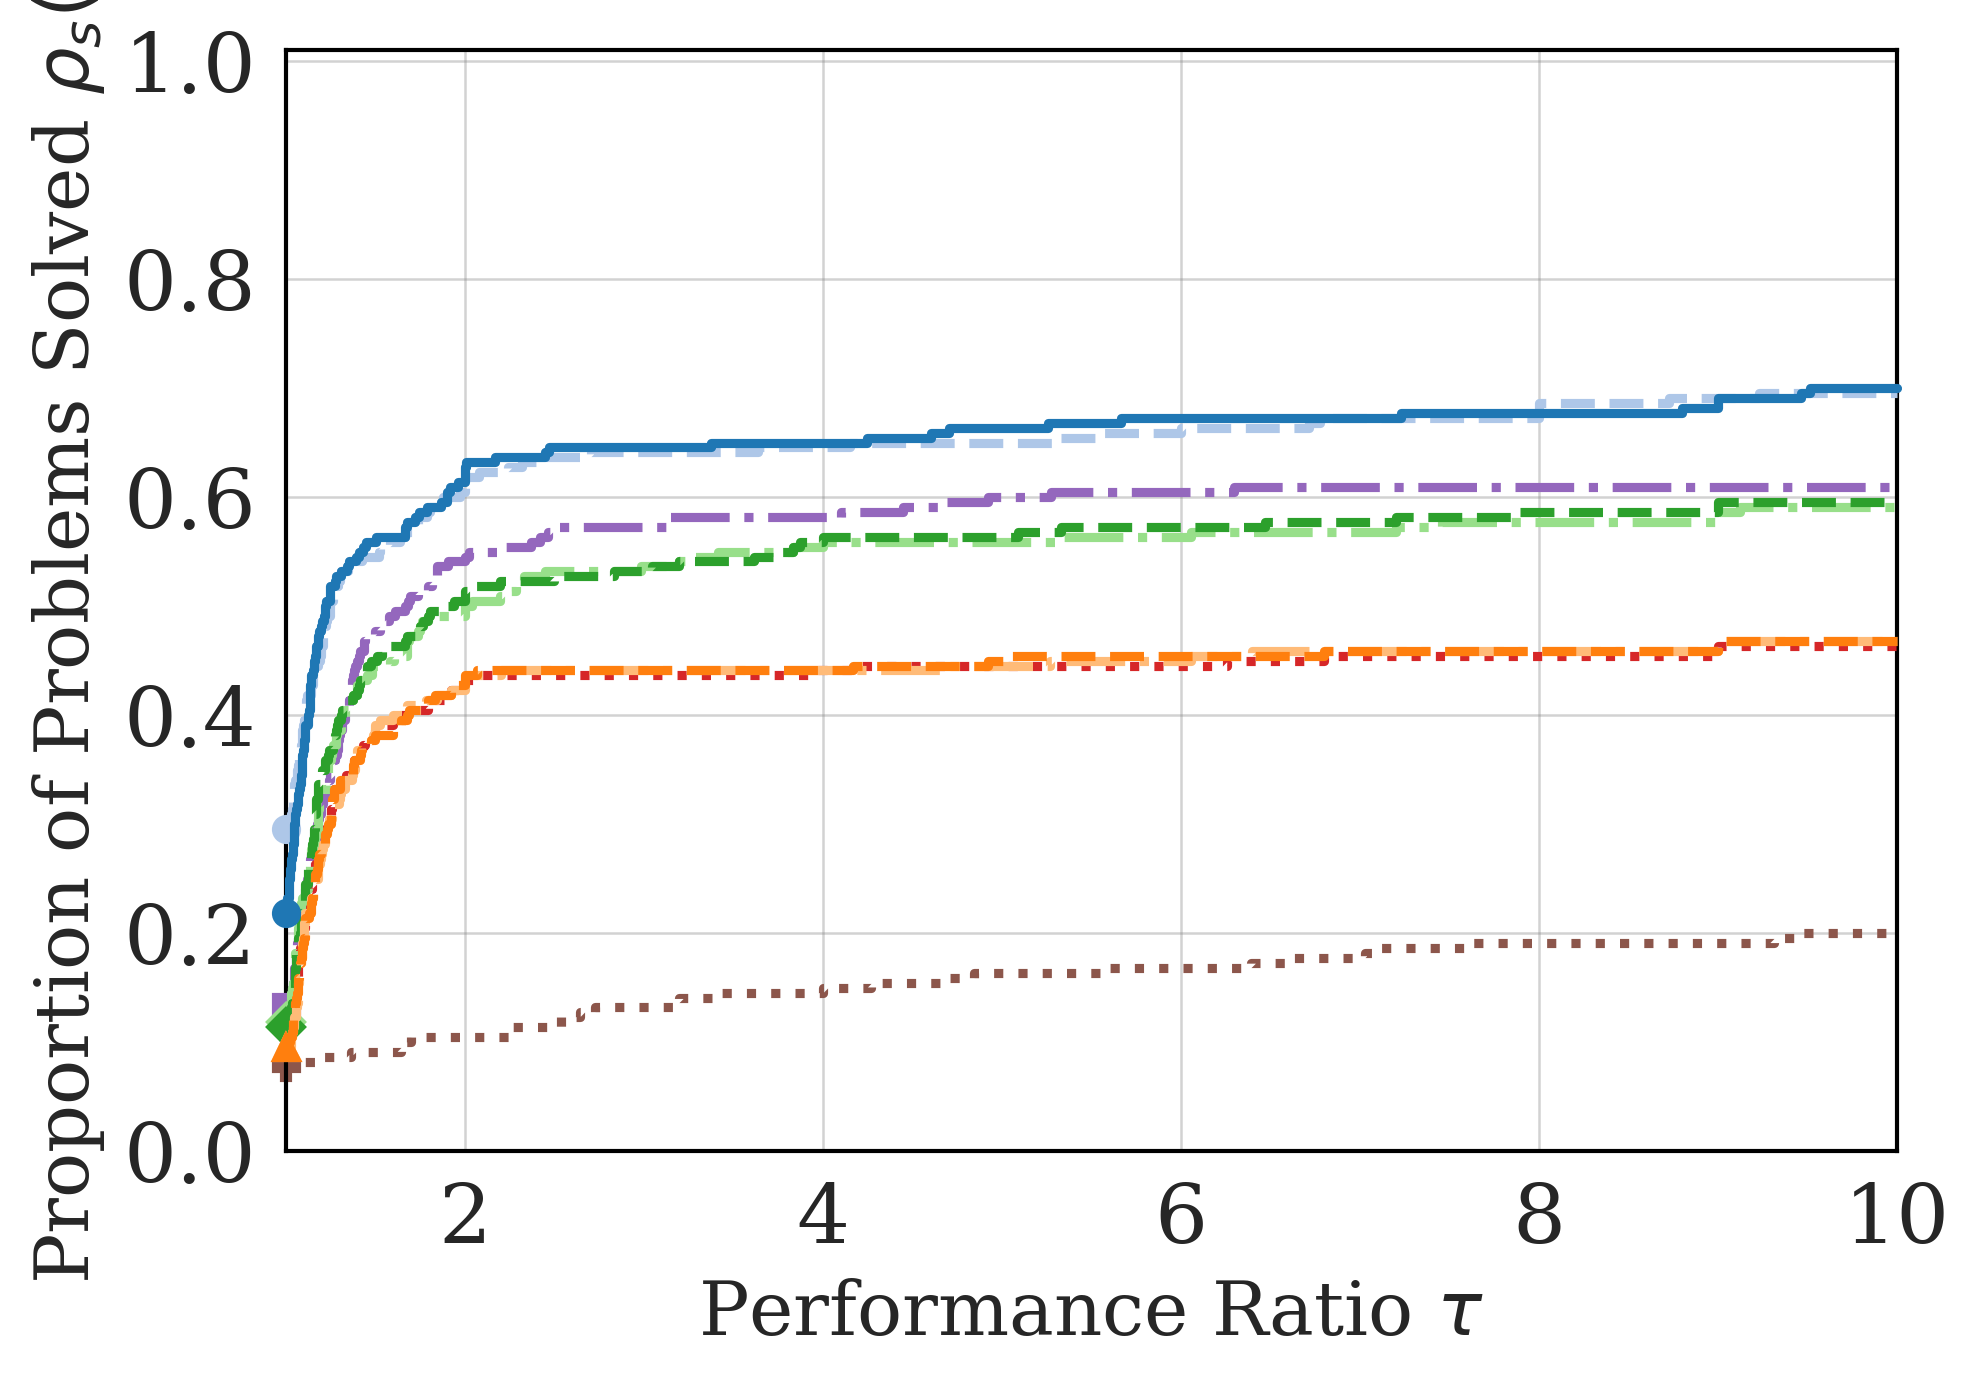

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-03.pdf


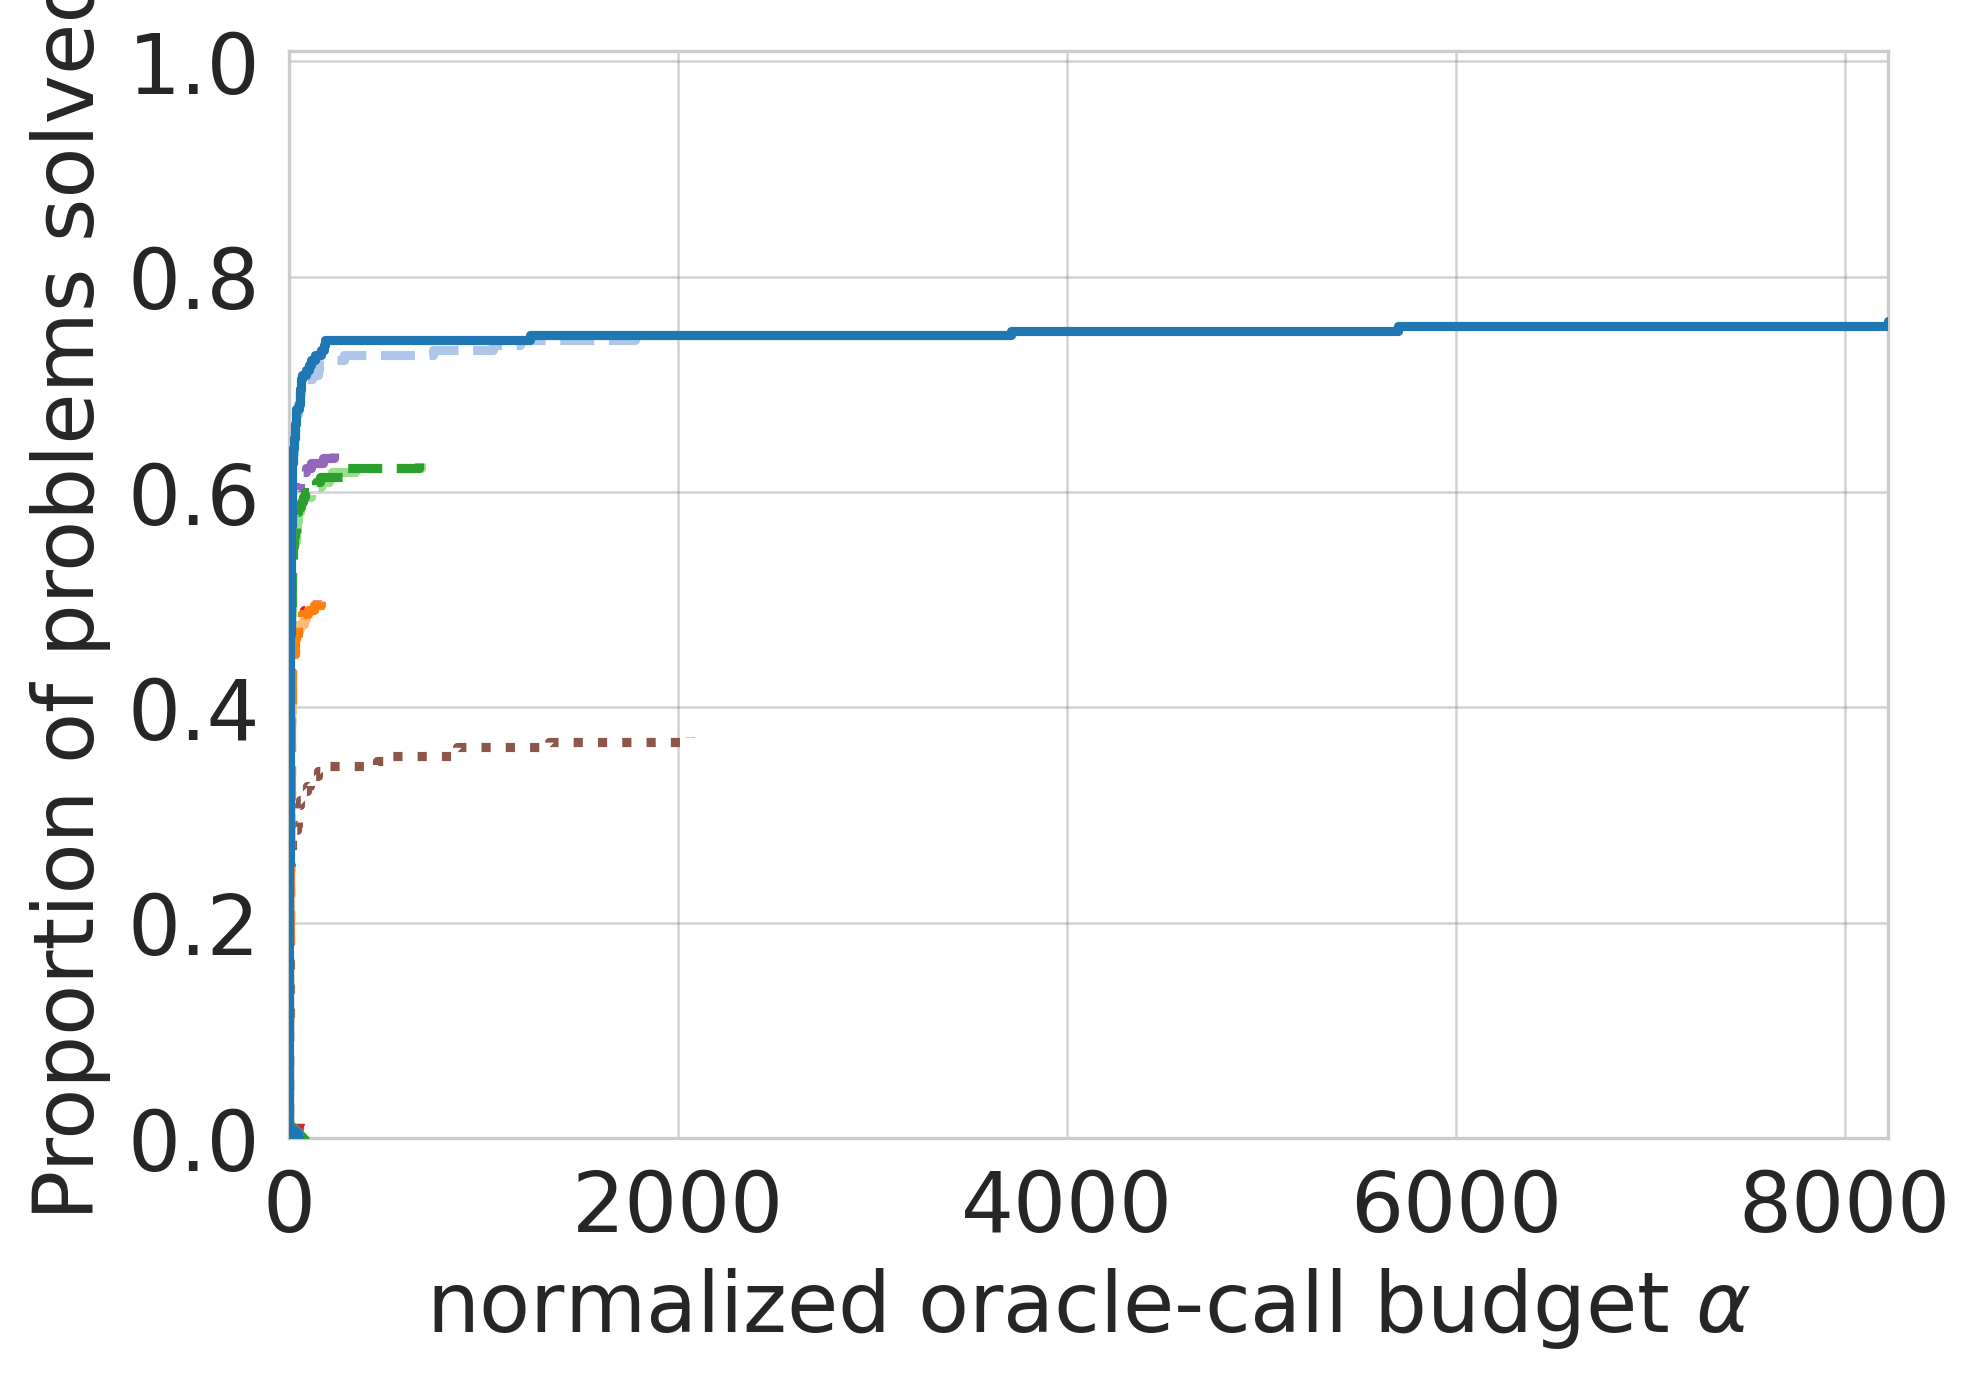

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),47.0,47.0,inf,inf,49.0,49.0,inf,inf,6179.0
ALLINITU (seed=0),27.0,27.0,24.0,26.0,22.0,24.0,24.0,25.0,60.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,16.0,16.0,8.0,5.0,16.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),336.0,303.0,inf,inf,264.0,240.0,inf,73.0,inf
YATP1LS (seed=0),inf,inf,inf,inf,44.0,inf,inf,inf,inf
YATP2LS (seed=0),246.0,240.0,50.0,48.0,53.0,53.0,50.0,26.0,inf
YFITU (seed=0),201.0,465.0,198.0,172.0,287.0,255.0,198.0,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,75.909091,21.818182
NTRQN-MS,74.545455,29.545455
Line,50.454545,9.545455
Line-MS,50.000000,9.545455
Reg,62.727273,11.363636
Reg-Sec,62.727273,11.818182
SciPy,50.000000,10.454545
NTQN,63.636364,13.181818
ASTR1-Adagrad,37.272727,7.727273


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,213,7,0,98
NTRQN-MS,220,0,207,13,0,91
Line,220,0,220,0,0,155
Line-MS,220,0,220,0,0,154
Reg,220,0,217,1,2,120
Reg-Sec,220,0,219,1,0,125
SciPy,220,0,220,0,0,18
NTQN,220,0,217,3,0,2
ASTR1-Adagrad,220,0,216,4,0,173


flag,0,1,2,6
method,,,,
NTQN,108,1,1,107


Saved figure to doc/imgs/compare/_pp_precision32_gtol1e-05.pdf


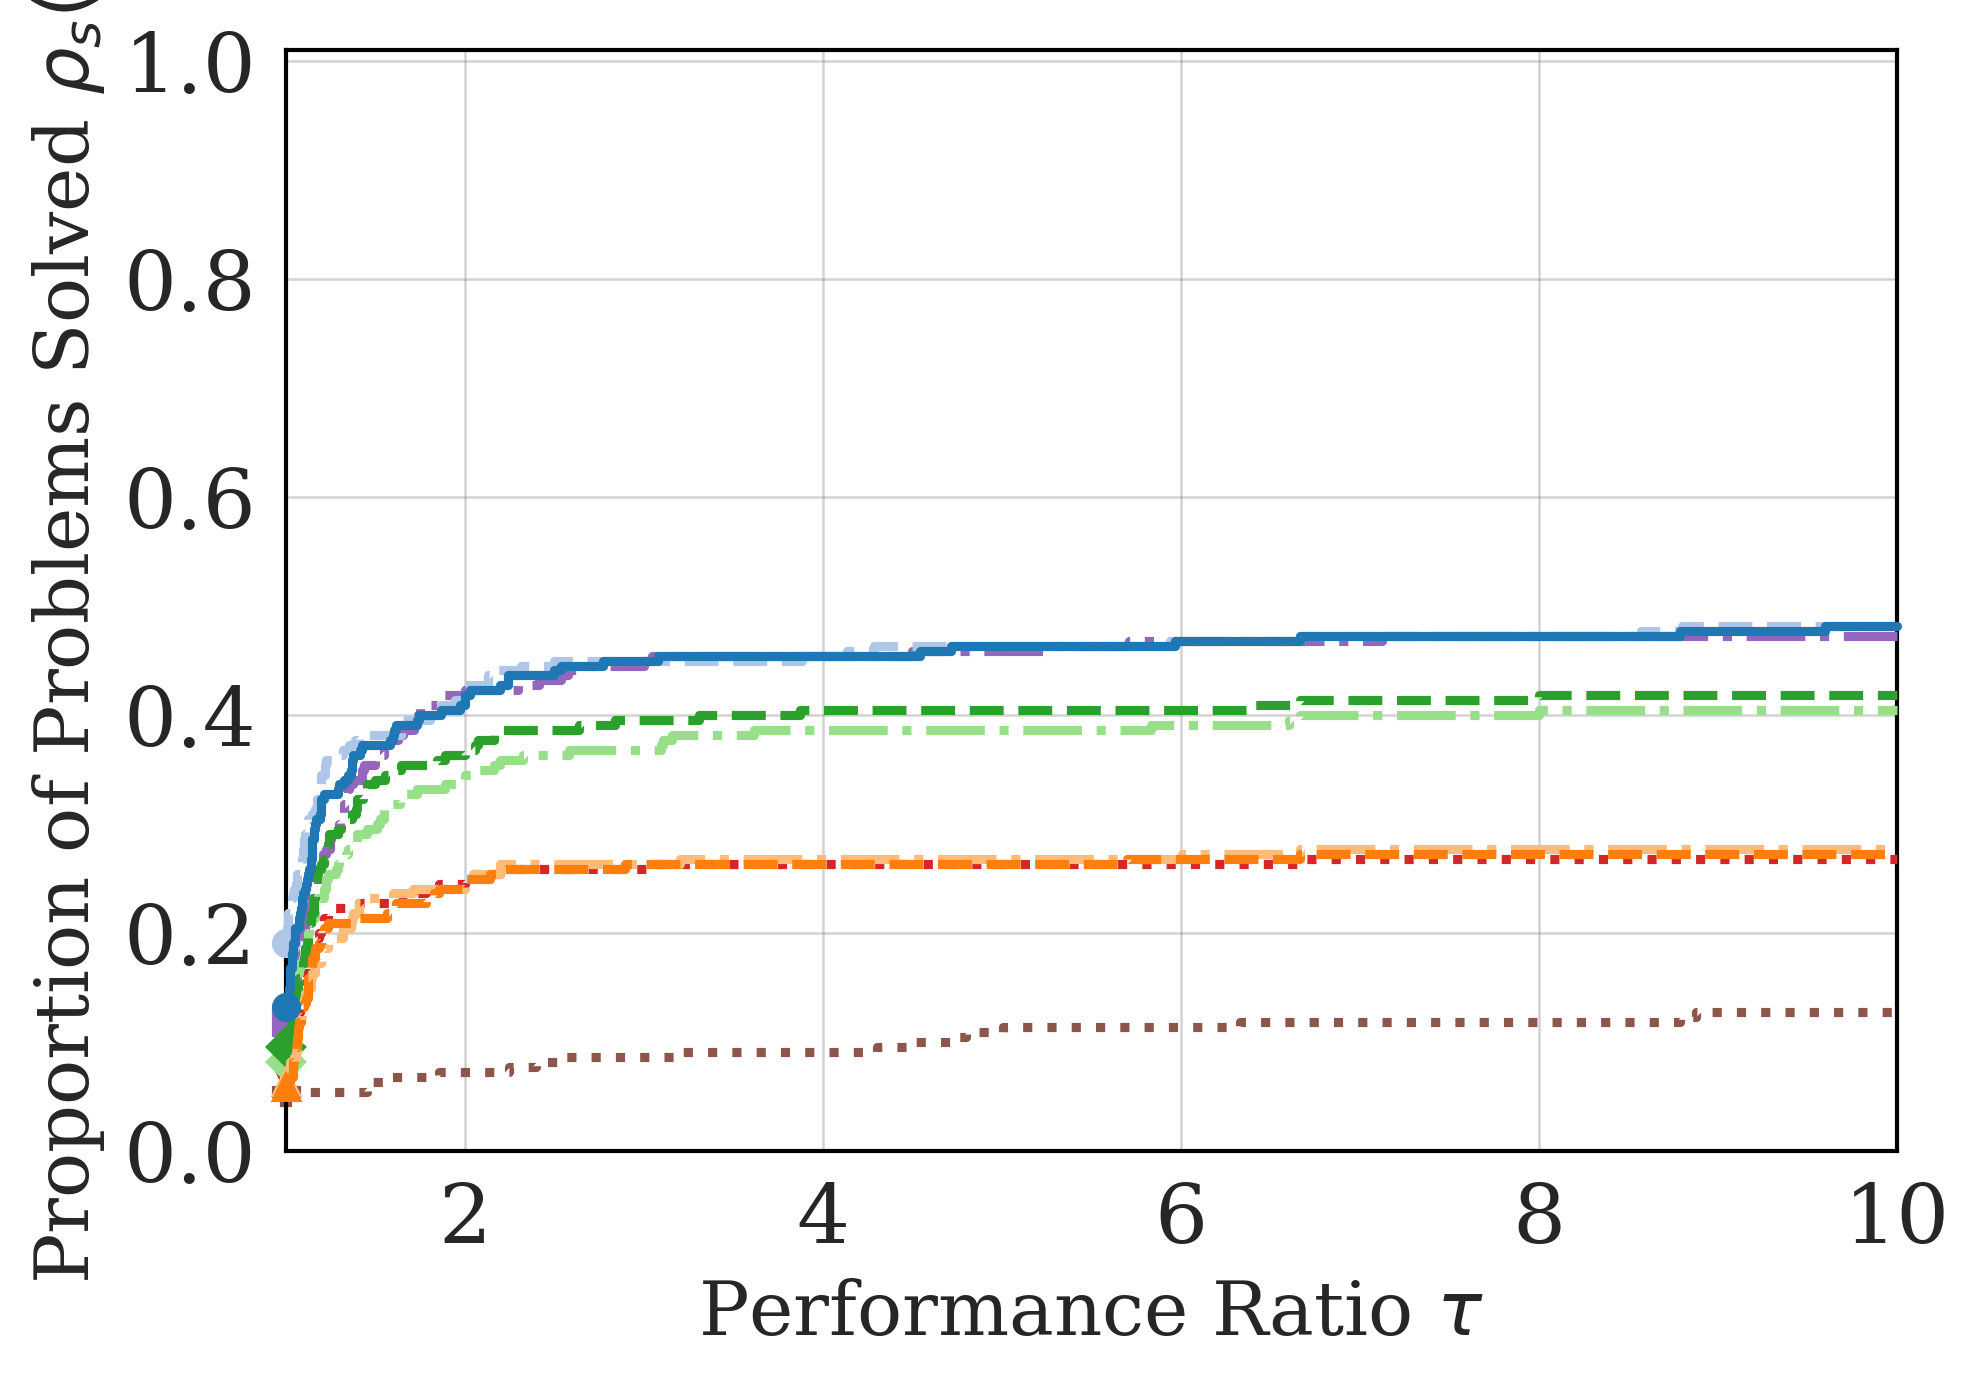

Saved figure to doc/imgs/compare/_dp_float32_gtol1e-05.pdf


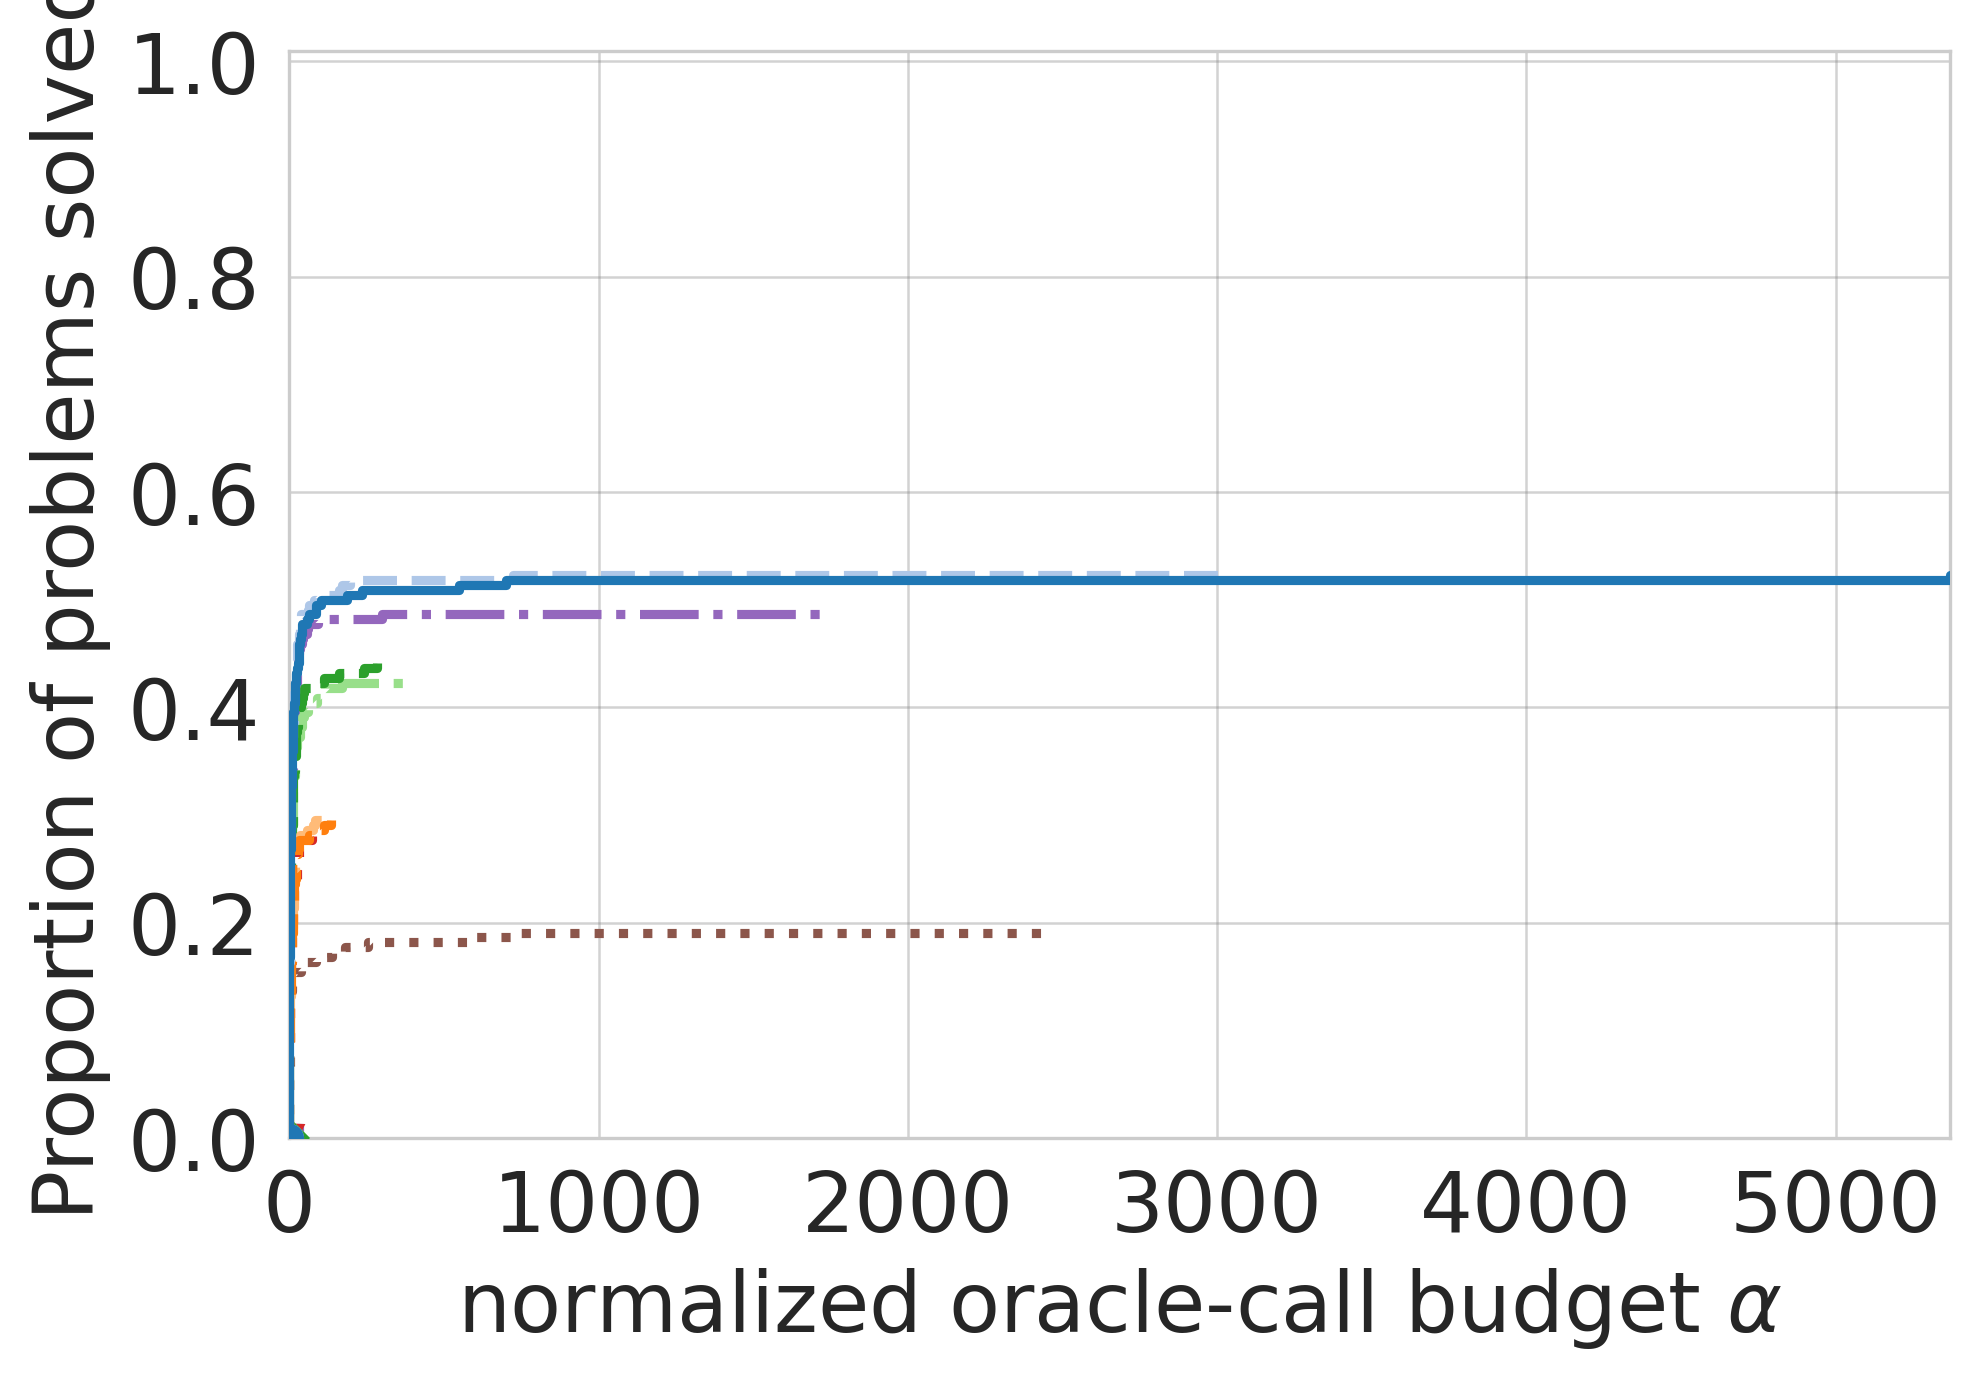

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),49.0,49.0,inf,inf,51.0,51.0,inf,inf,7289.0
ALLINITU (seed=0),29.0,29.0,inf,inf,26.0,26.0,inf,43.0,83.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,inf,inf,8.0,5.0,24.0
ARGLINB (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINC (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),382.0,335.0,inf,inf,268.0,256.0,inf,81.0,inf
YATP1LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
YATP2LS (seed=0),246.0,240.0,50.0,48.0,53.0,53.0,50.0,28.0,inf
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,52.272727,13.181818
NTRQN-MS,52.727273,19.090909
Line,29.545455,5.909091
Line-MS,30.000000,6.363636
Reg,44.090909,9.545455
Reg-Sec,42.727273,8.181818
SciPy,28.636364,6.818182
NTQN,49.090909,11.818182
ASTR1-Adagrad,19.545455,5.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,213,7,0,98
NTRQN-MS,220,0,207,13,0,91
Line,220,0,220,0,0,155
Line-MS,220,0,220,0,0,154
Reg,220,0,217,1,2,120
Reg-Sec,220,0,219,1,0,125
SciPy,220,0,220,0,0,18
NTQN,220,0,217,3,0,2
ASTR1-Adagrad,220,0,216,4,0,173


flag,0,1,2,6
method,,,,
NTQN,108,1,1,107


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-01.pdf


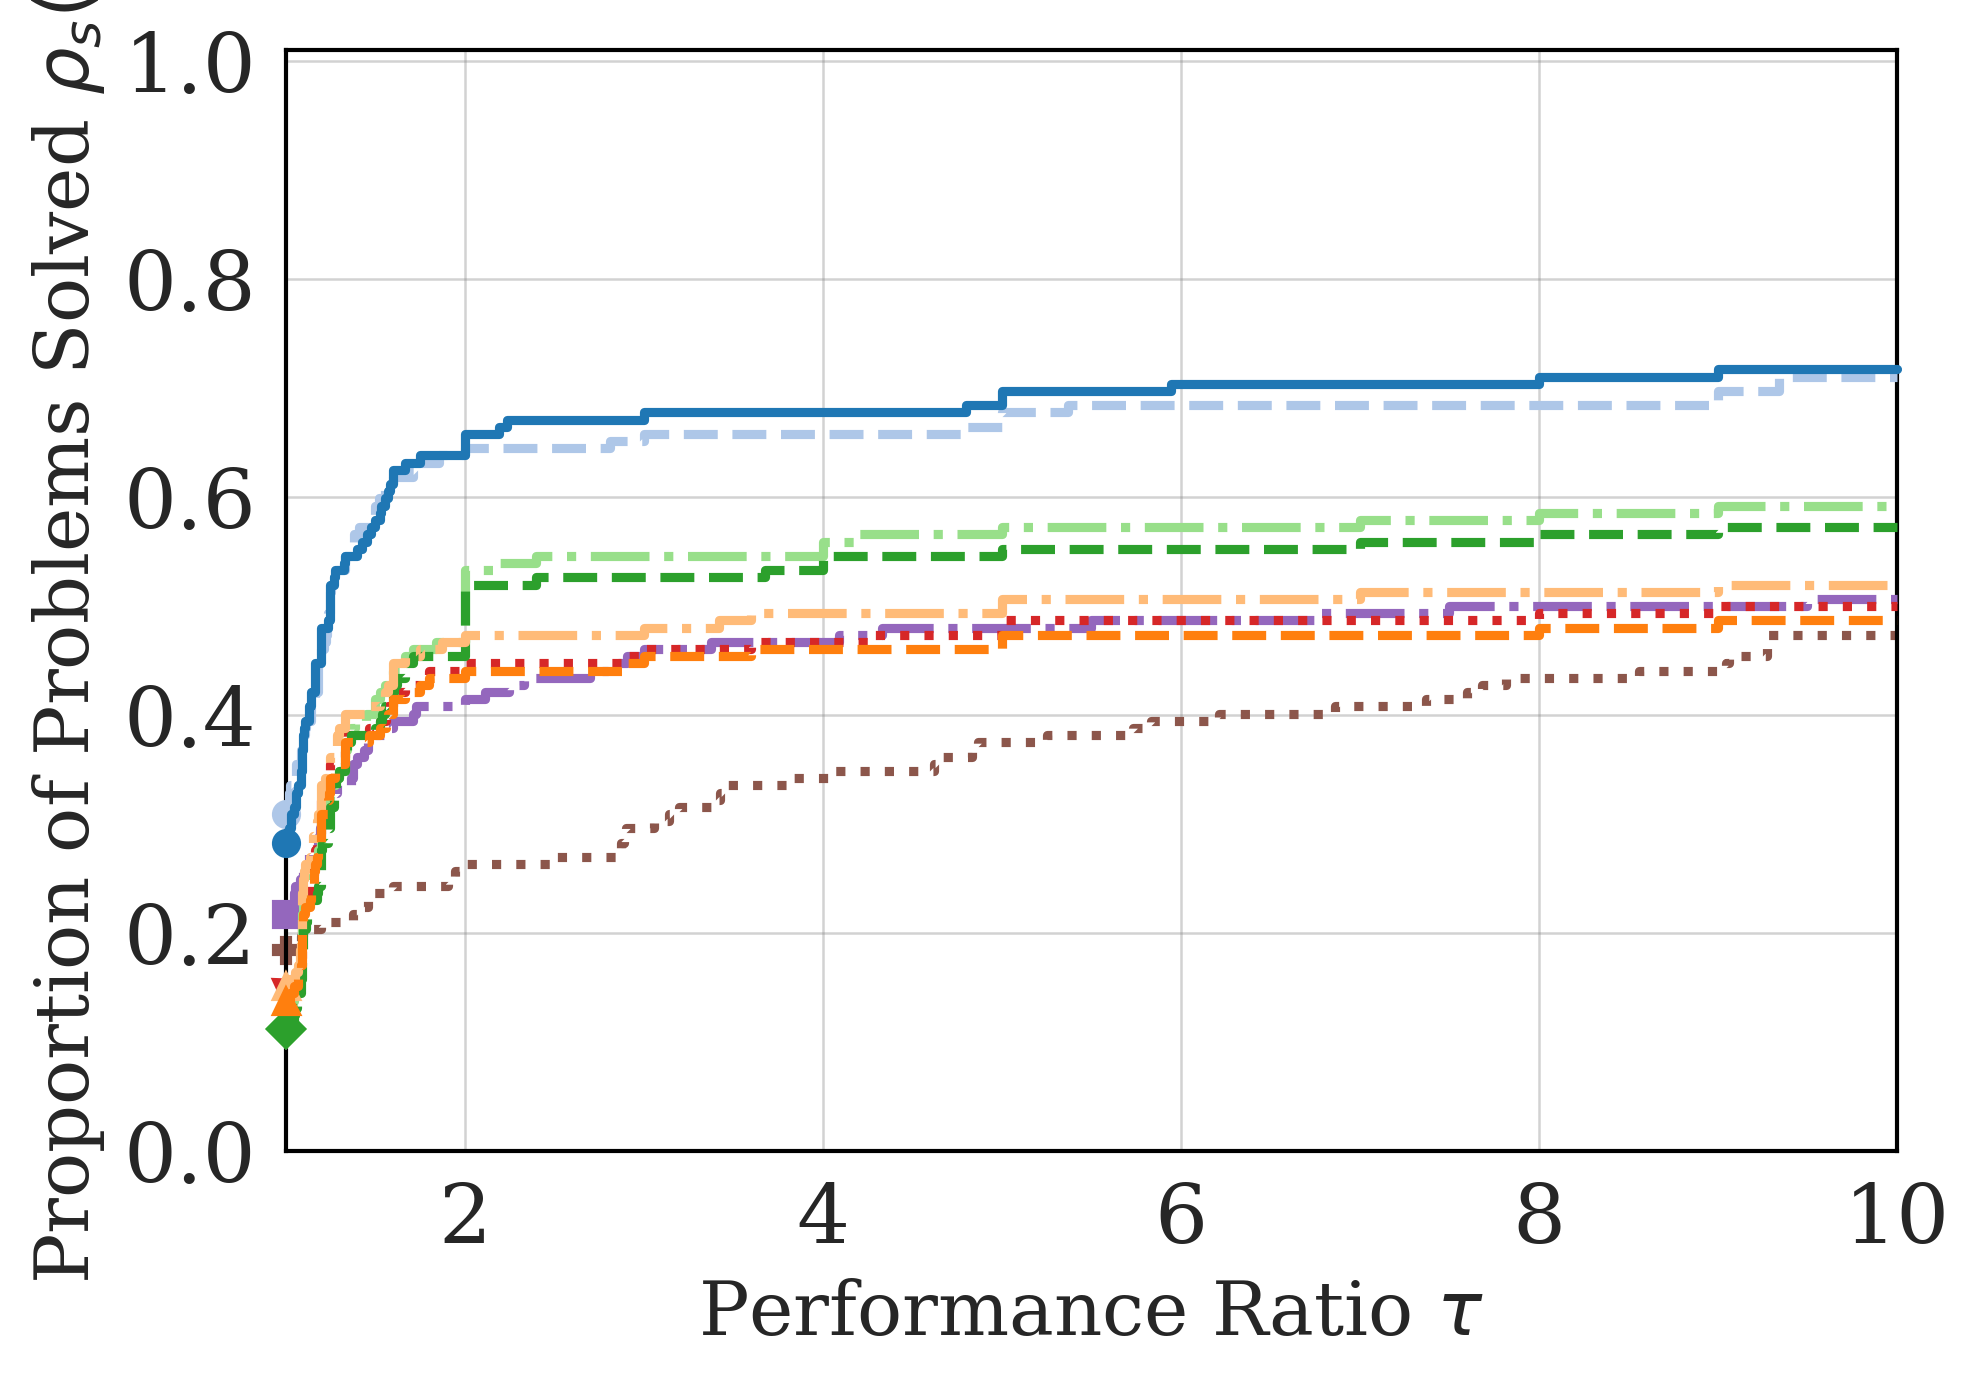

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-01.pdf


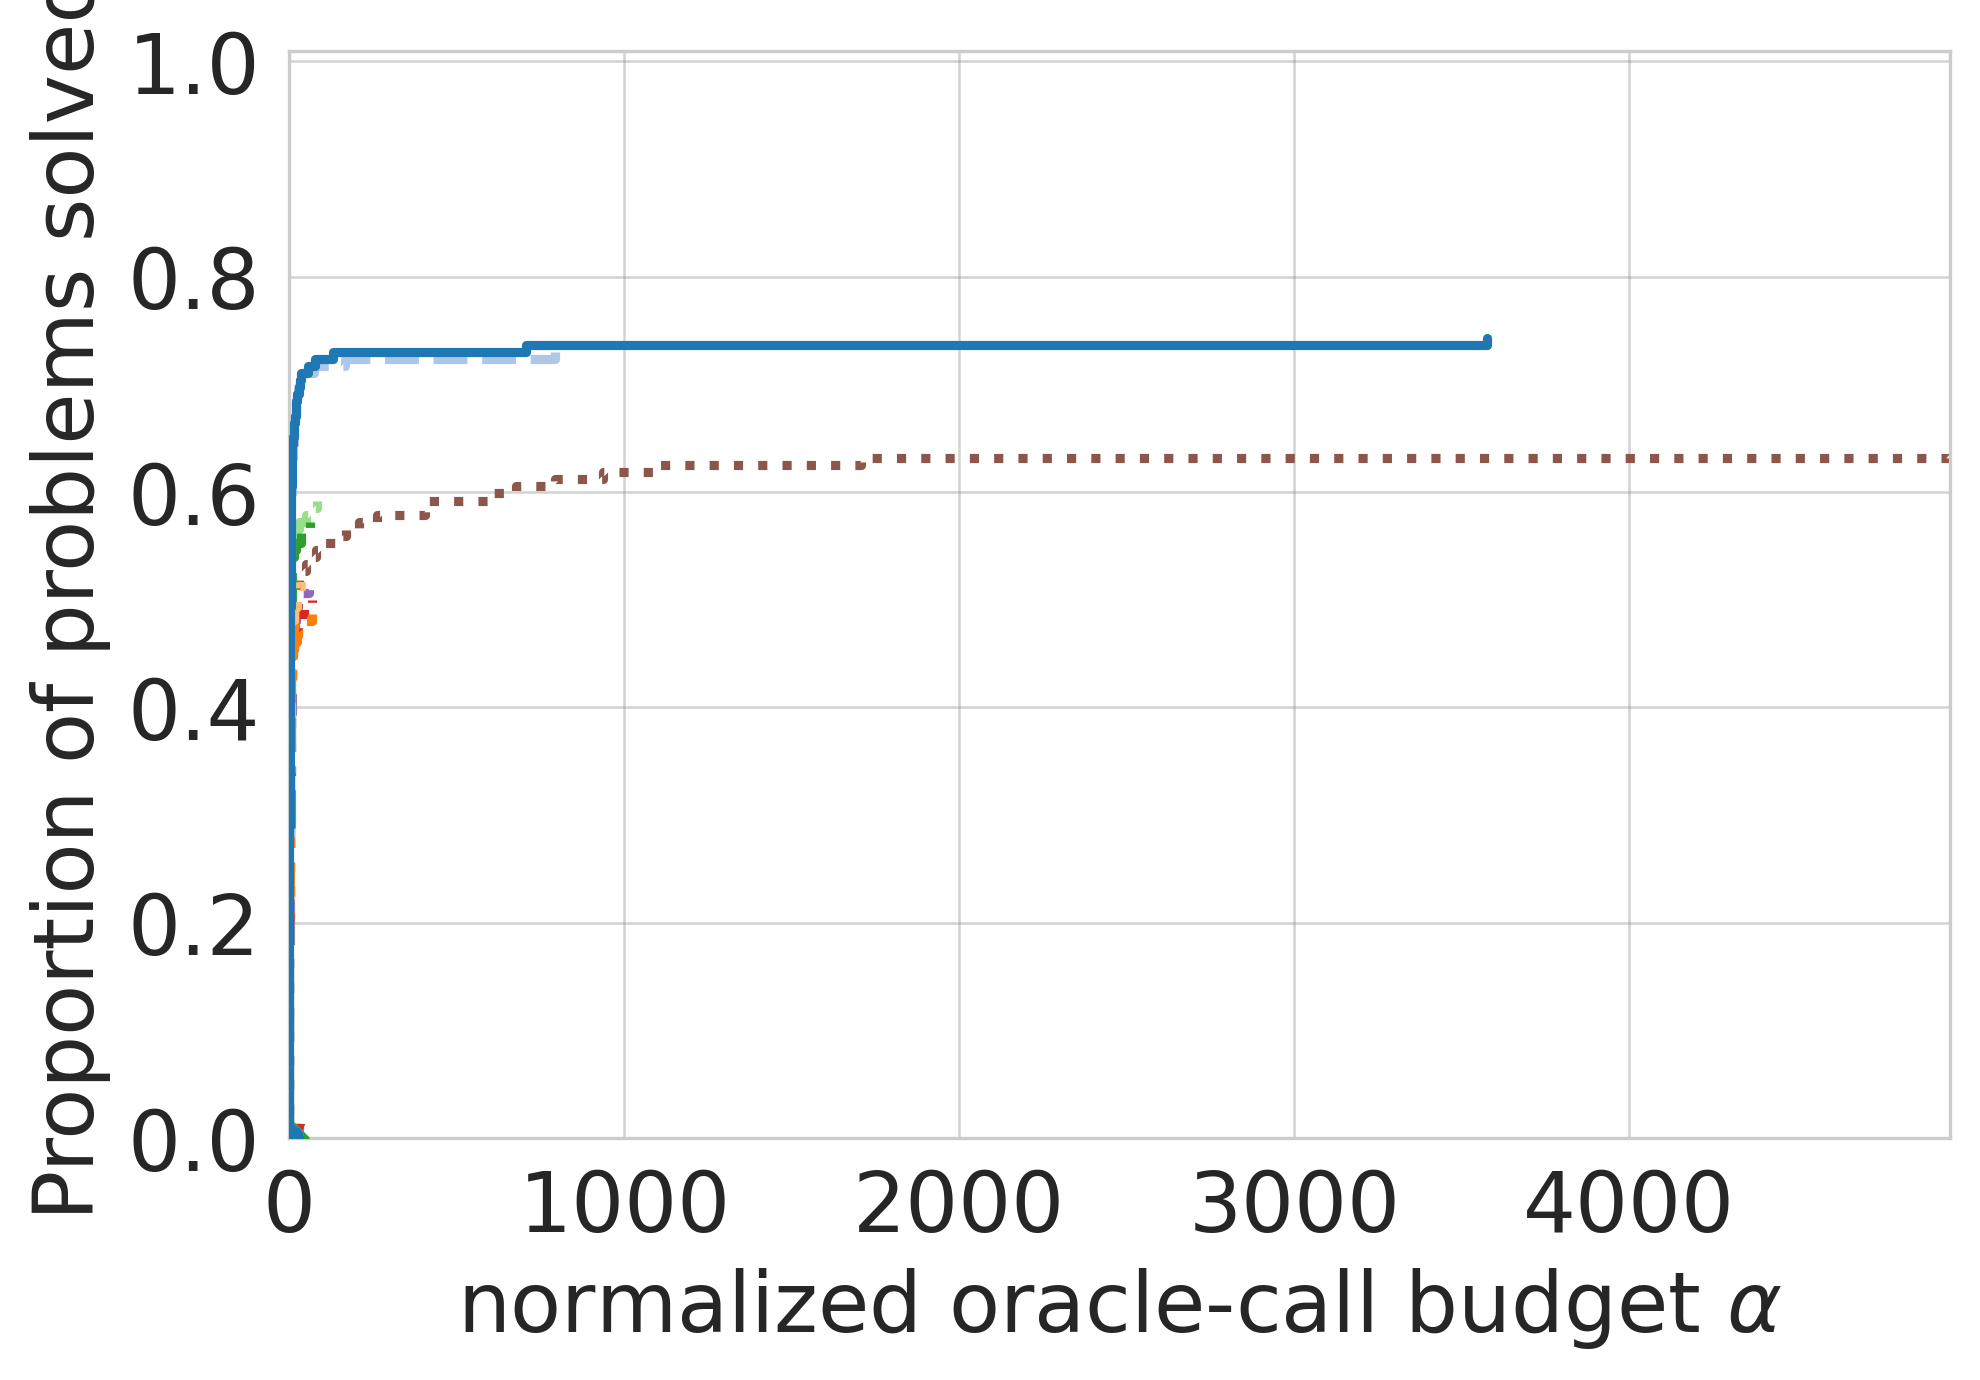

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),43.0,43.0,inf,inf,inf,inf,inf,inf,2811.0
ALLINITU (seed=0),21.0,19.0,inf,20.0,20.0,20.0,inf,24.0,37.0
ARGLINA (seed=0),8.0,8.0,8.0,8.0,12.0,12.0,8.0,5.0,8.0
ARGTRIGLS (seed=0),163.0,189.0,158.0,188.0,154.0,158.0,158.0,174.0,inf
ARWHEAD (seed=0),10.0,8.0,8.0,8.0,8.0,8.0,8.0,27.0,16.0
...,...,...,...,...,...,...,...,...,...
WATSON (seed=0),43.0,39.0,38.0,42.0,38.0,38.0,38.0,65.0,1993.0
WOODS (seed=0),43.0,13008.0,inf,inf,48.0,48.0,inf,inf,810.0
YATP2LS (seed=0),inf,inf,54.0,54.0,42.0,42.0,inf,inf,1167.0
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,74.342105,28.289474
NTRQN-MS,73.026316,30.921053
Line,48.684211,13.815789
Line-MS,51.973684,15.131579
Reg,57.236842,11.184211
Reg-Sec,59.210526,11.184211
SciPy,50.000000,14.473684
NTQN,51.315789,21.710526
ASTR1-Adagrad,63.815789,18.421053


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,152,0,147,5,0,103
NTRQN-MS,152,0,146,6,0,102
Line,152,0,152,0,0,140
Line-MS,152,0,152,0,0,143
Reg,152,0,146,1,5,122
Reg-Sec,152,0,151,1,0,125
SciPy,152,0,151,1,0,83
NTQN,152,0,152,0,0,0
ASTR1-Adagrad,152,0,150,2,0,123


flag,0,6
method,,
NTQN,25,127


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-03.pdf


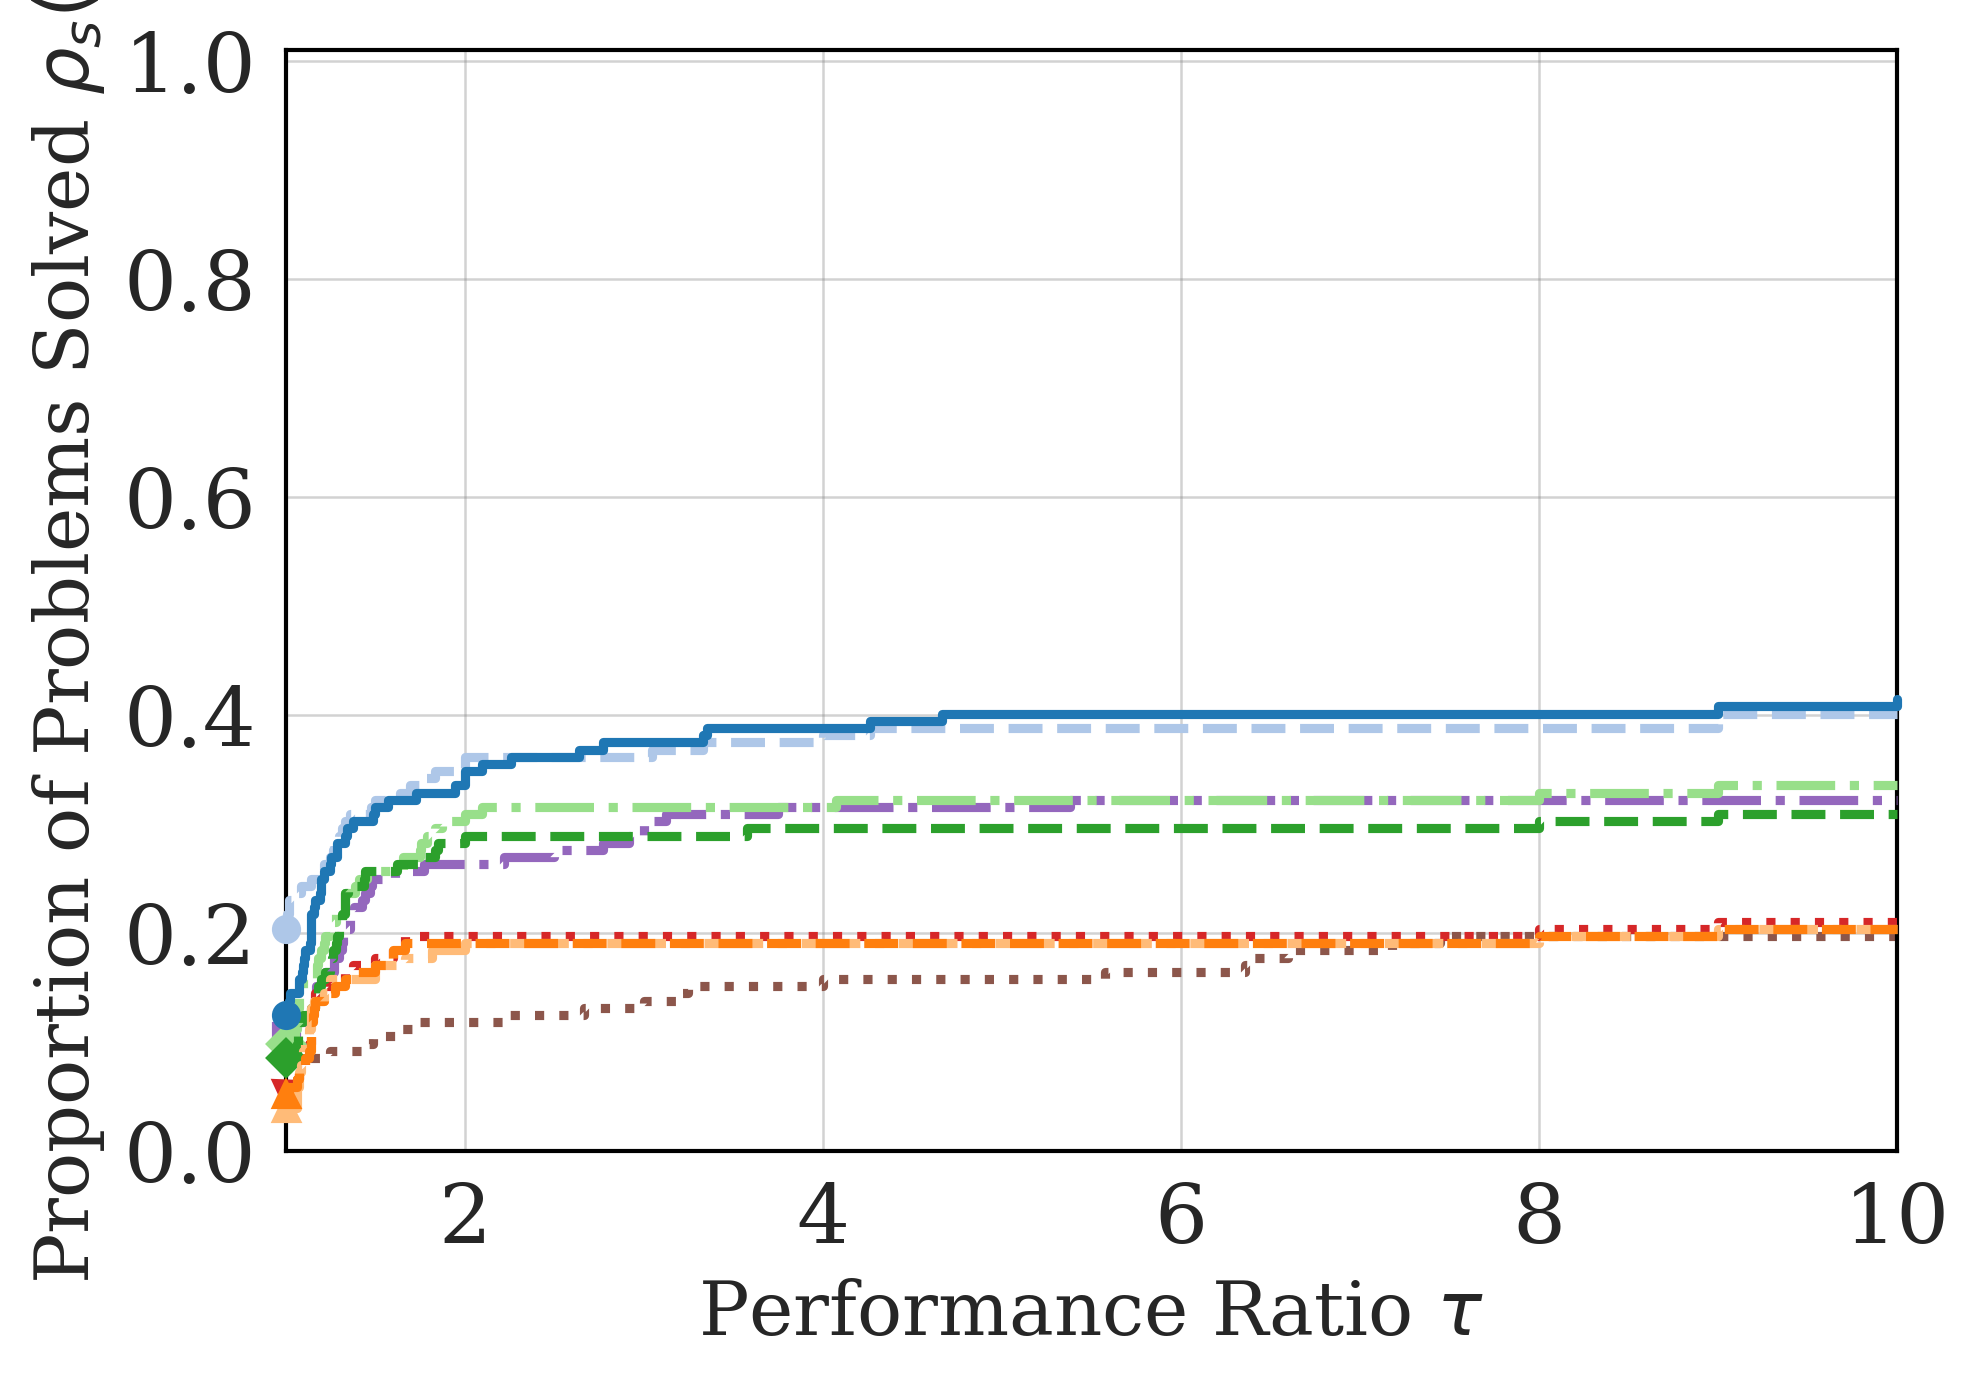

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-03.pdf


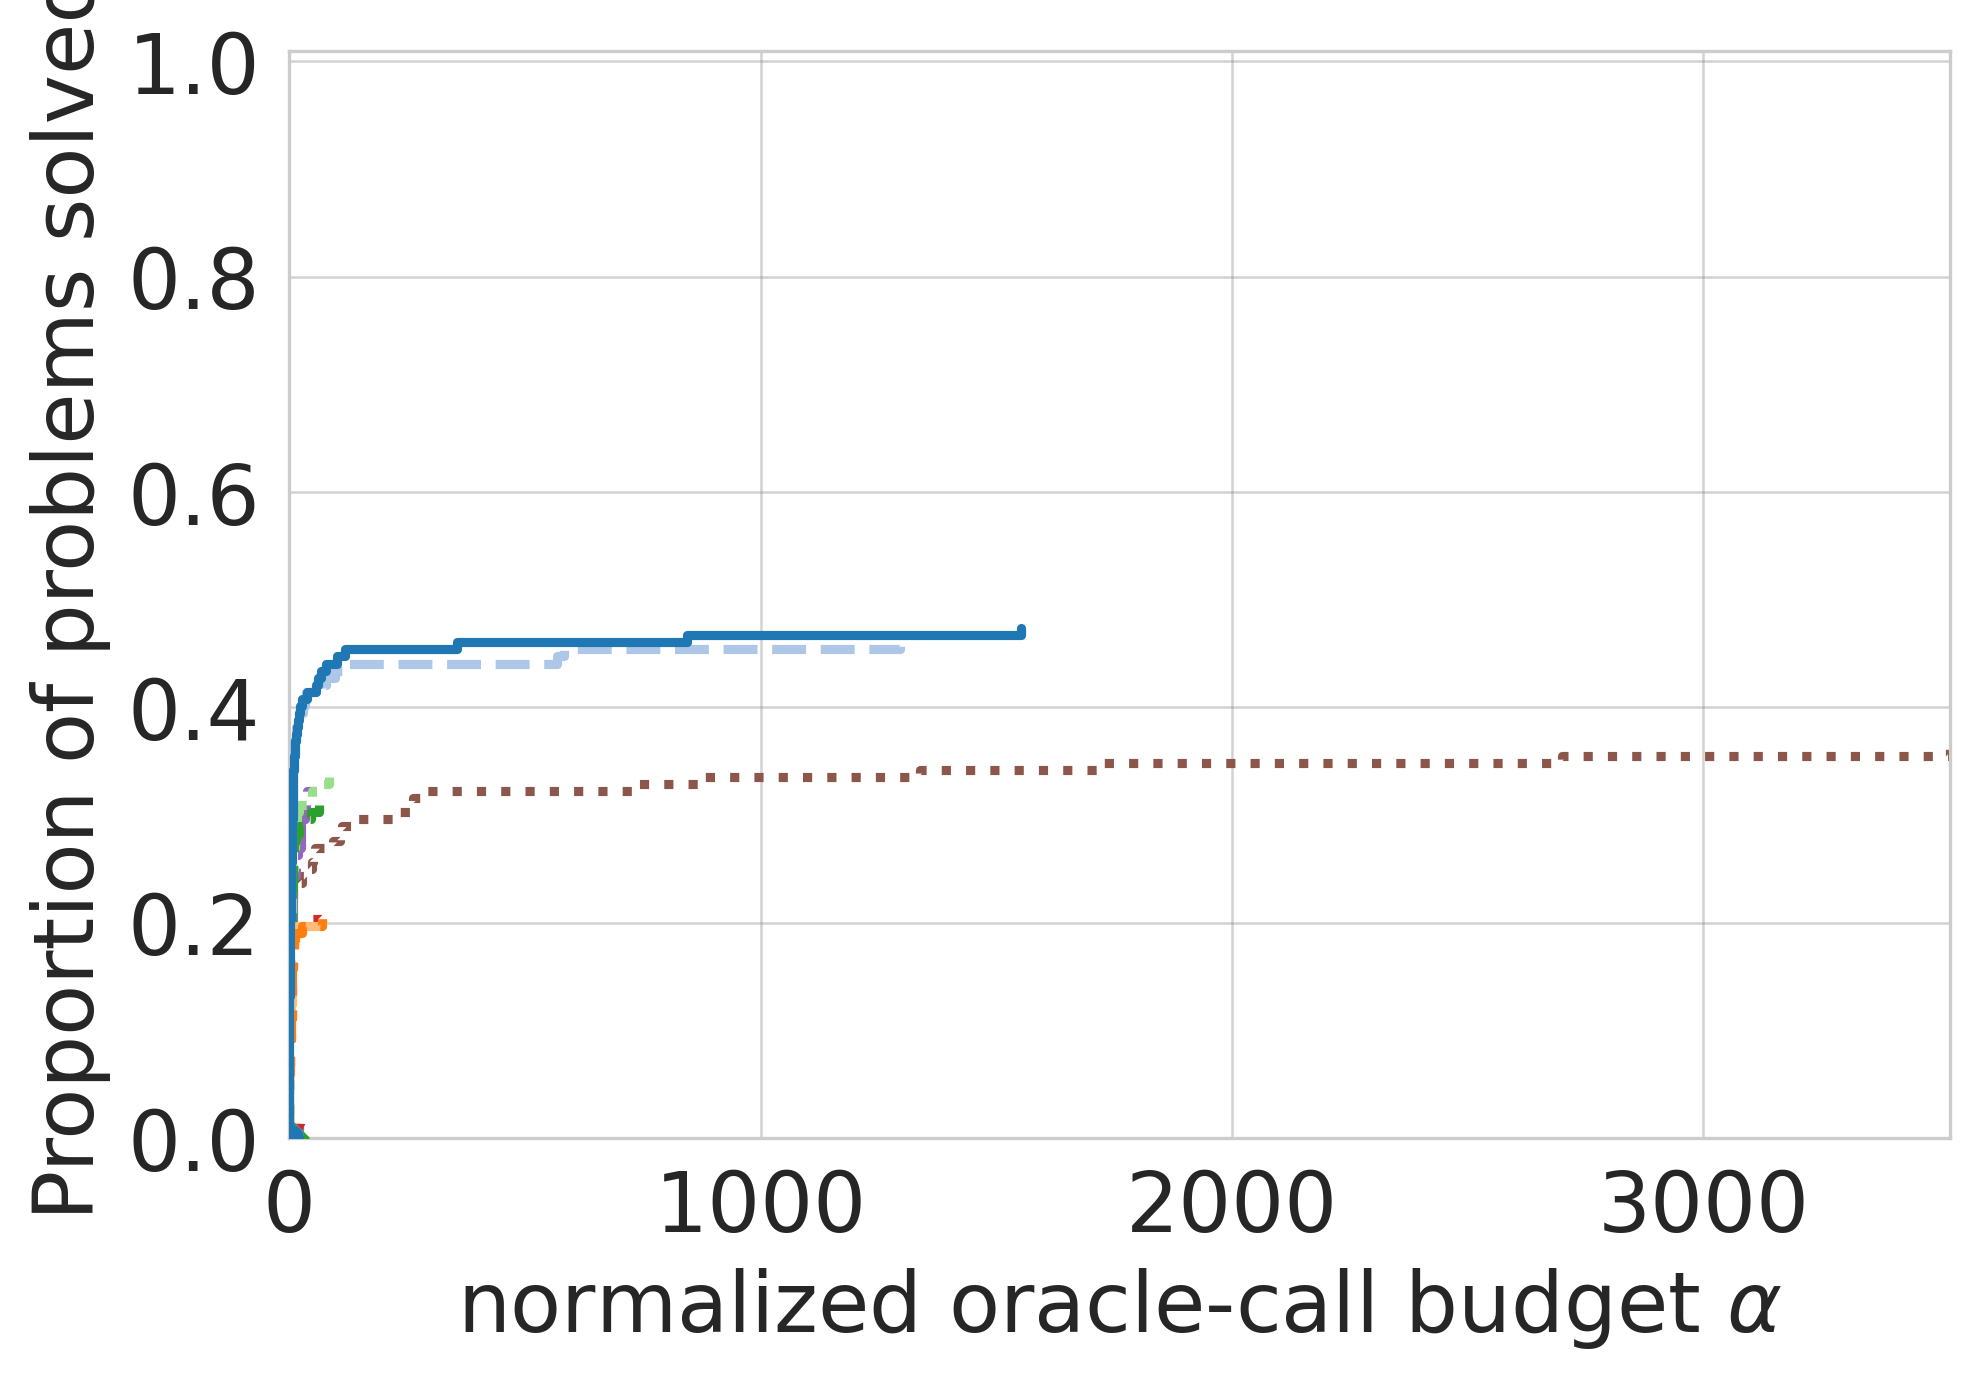

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINA (seed=0),10.0,10.0,8.0,10.0,inf,inf,8.0,5.0,15.0
ARGTRIGLS (seed=0),1457.0,1163.0,inf,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),12.0,8.0,inf,inf,8.0,8.0,inf,30.0,26.0
...,...,...,...,...,...,...,...,...,...
WATSON (seed=0),inf,inf,inf,inf,inf,inf,inf,454.0,inf
WOODS (seed=0),inf,13752.0,inf,inf,inf,inf,inf,inf,inf
YATP2LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,47.368421,12.500000
NTRQN-MS,46.052632,20.394737
Line,20.394737,5.263158
Line-MS,20.394737,3.947368
Reg,30.921053,8.552632
Reg-Sec,33.552632,9.868421
SciPy,21.052632,5.263158
NTQN,32.894737,10.526316
ASTR1-Adagrad,36.184211,8.552632


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,152,0,147,5,0,103
NTRQN-MS,152,0,146,6,0,102
Line,152,0,152,0,0,140
Line-MS,152,0,152,0,0,143
Reg,152,0,146,1,5,122
Reg-Sec,152,0,151,1,0,125
SciPy,152,0,151,1,0,83
NTQN,152,0,152,0,0,0
ASTR1-Adagrad,152,0,150,2,0,123


flag,0,6
method,,
NTQN,25,127


Saved figure to doc/imgs/compare/_pp_precision16_gtol1e-05.pdf


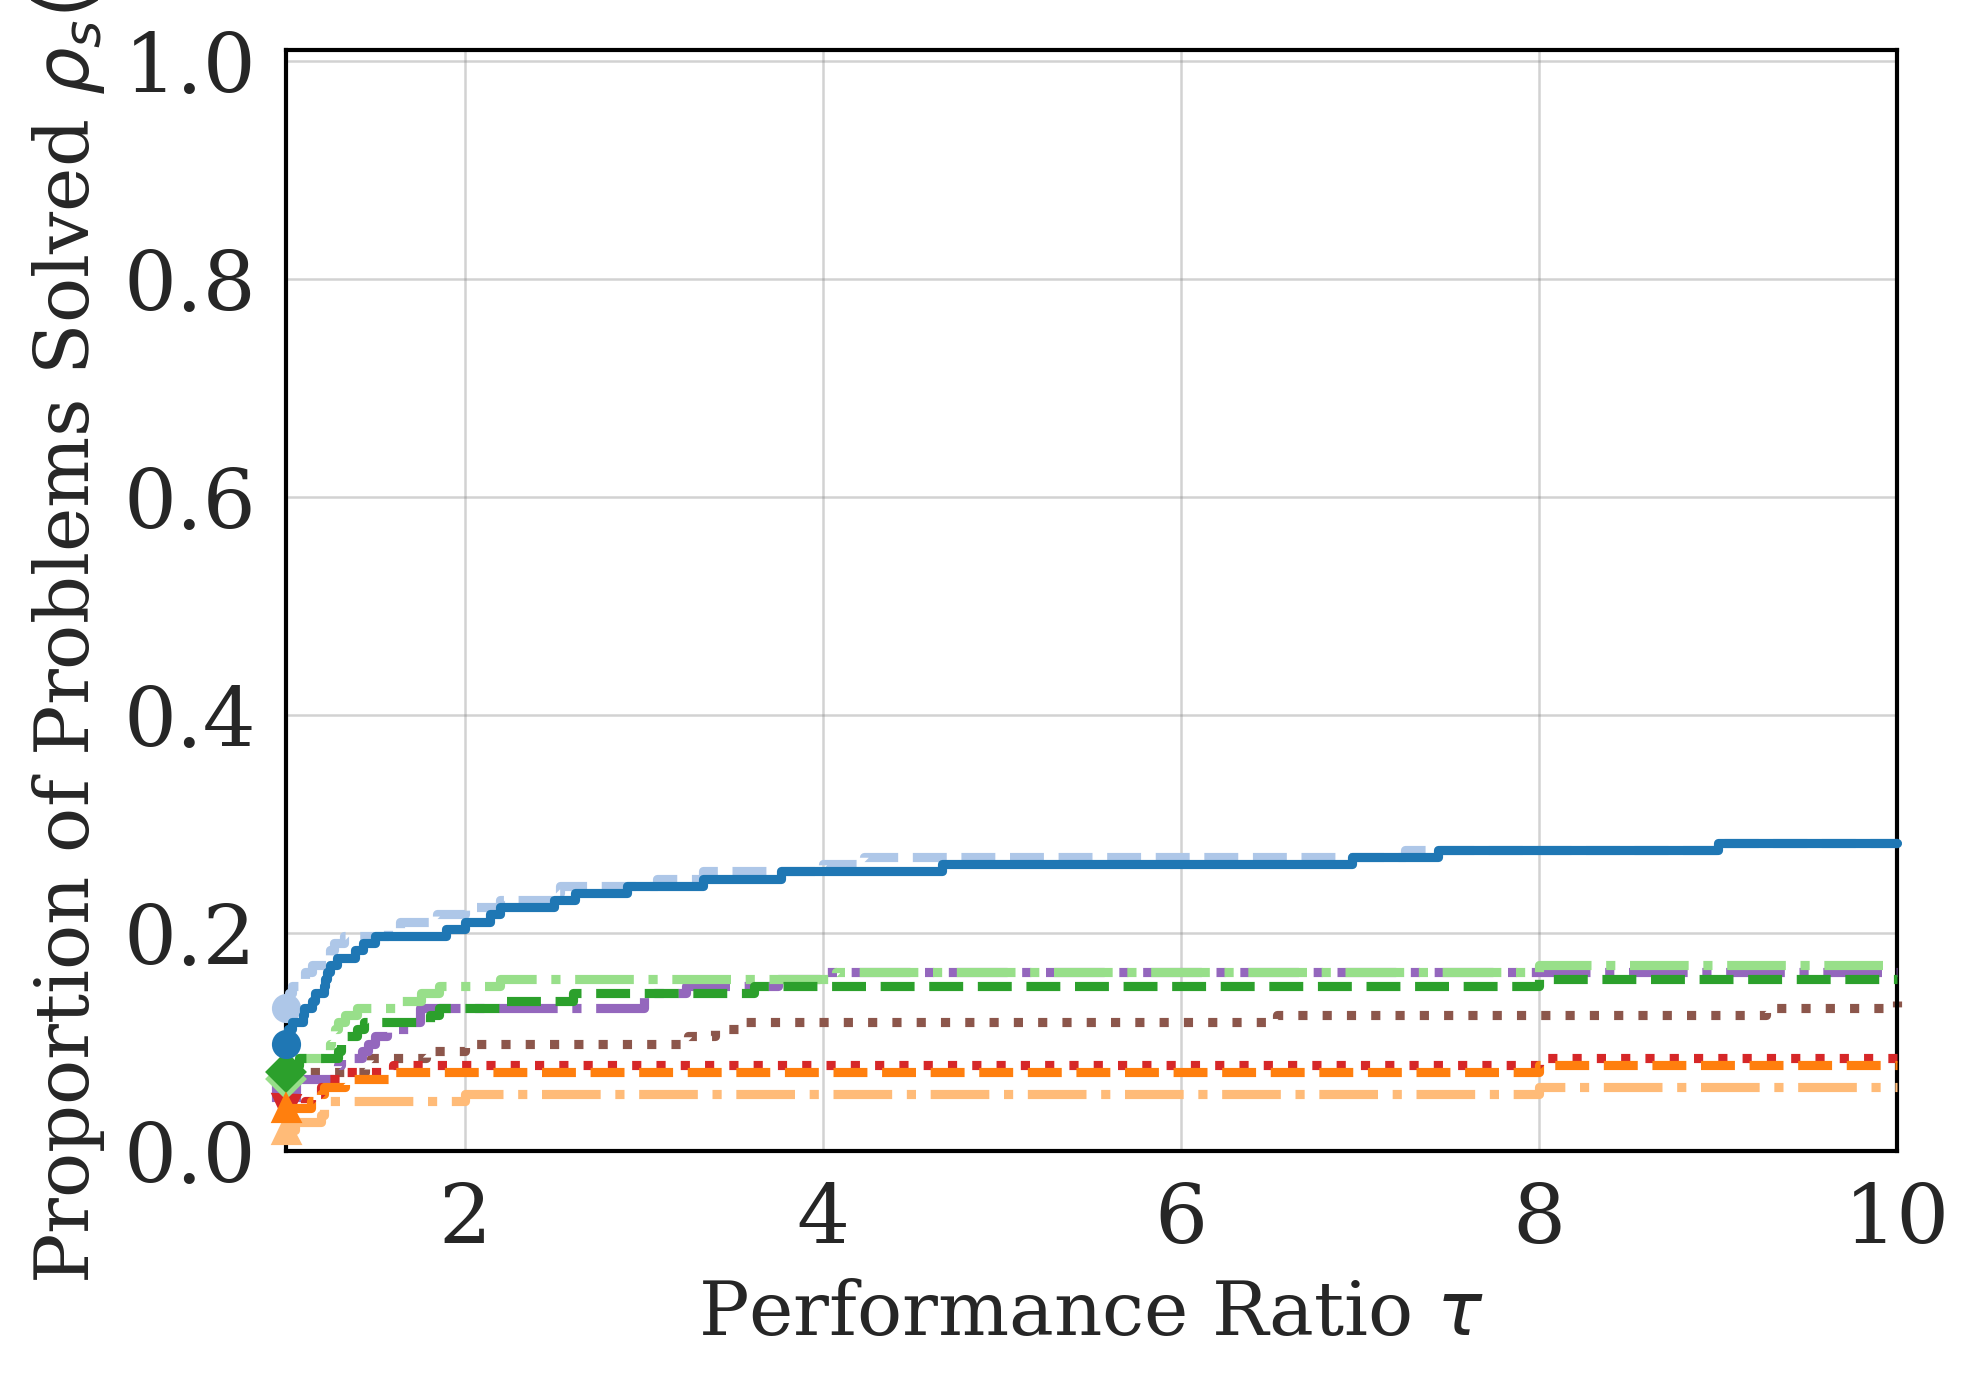

Saved figure to doc/imgs/compare/_dp_float16_gtol1e-05.pdf


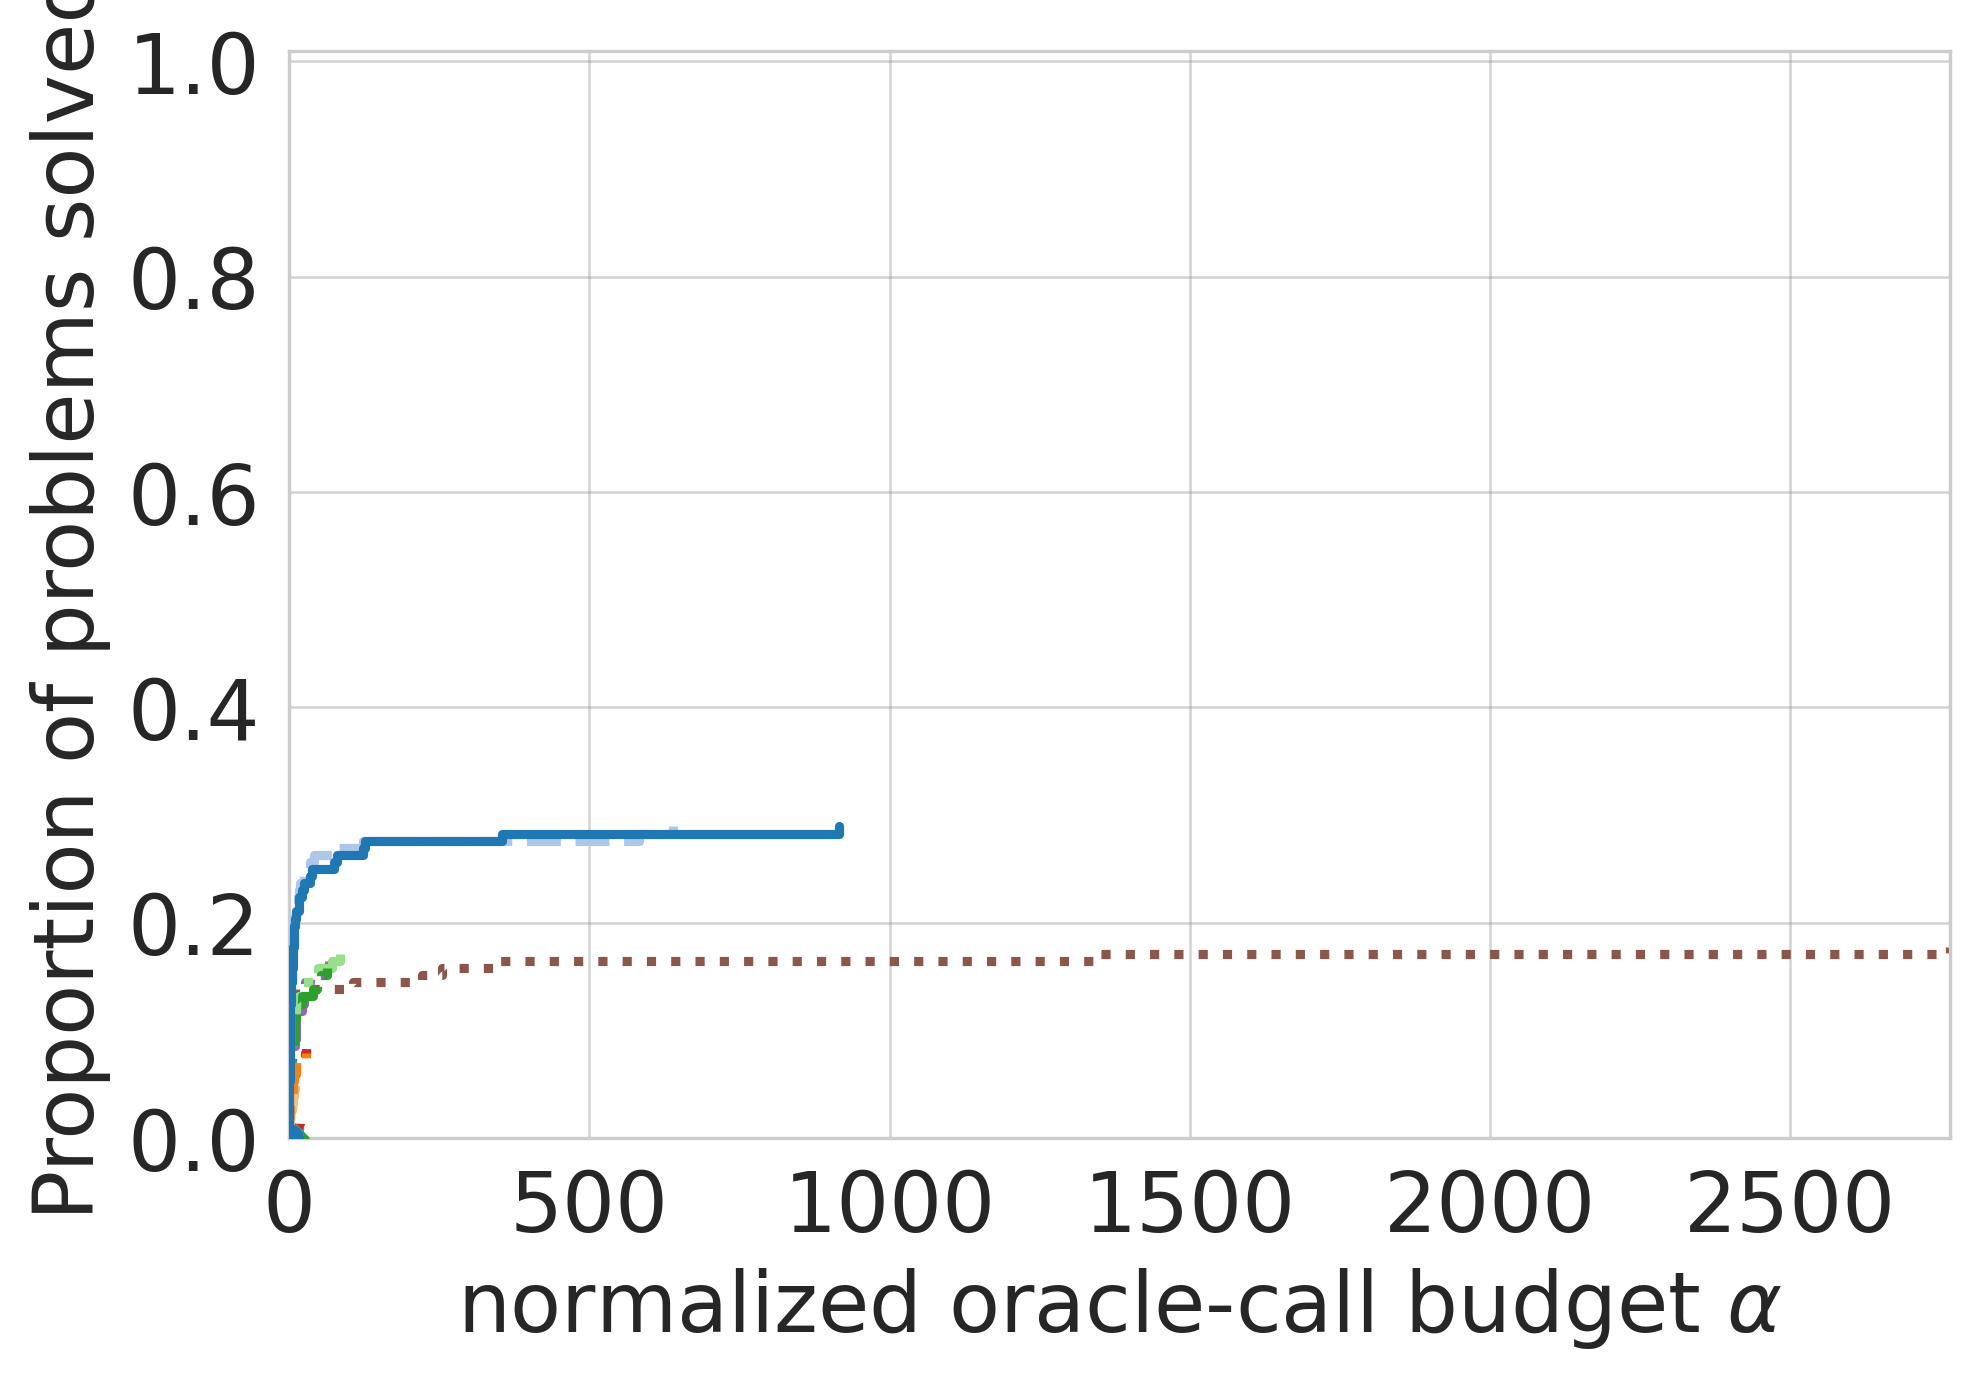

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ALLINITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
ARGLINA (seed=0),10.0,10.0,8.0,10.0,inf,inf,8.0,5.0,17.0
ARGTRIGLS (seed=0),3281.0,2995.0,inf,inf,inf,inf,inf,inf,inf
ARWHEAD (seed=0),12.0,8.0,inf,inf,8.0,8.0,inf,30.0,26.0
...,...,...,...,...,...,...,...,...,...
WATSON (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
WOODS (seed=0),inf,13752.0,inf,inf,inf,inf,inf,inf,inf
YATP2LS (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf
YFITU (seed=0),inf,inf,inf,inf,inf,inf,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,28.947368,9.868421
NTRQN-MS,28.947368,13.157895
Line,7.894737,3.947368
Line-MS,5.921053,1.973684
Reg,15.789474,7.236842
Reg-Sec,17.105263,6.578947
SciPy,8.552632,3.947368
NTQN,16.447368,5.921053
ASTR1-Adagrad,17.763158,7.236842


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,152,0,147,5,0,103
NTRQN-MS,152,0,146,6,0,102
Line,152,0,152,0,0,140
Line-MS,152,0,152,0,0,143
Reg,152,0,146,1,5,122
Reg-Sec,152,0,151,1,0,125
SciPy,152,0,151,1,0,83
NTQN,152,0,152,0,0,0
ASTR1-Adagrad,152,0,150,2,0,123


flag,0,6
method,,
NTQN,25,127


Saved figure to doc/imgs/compare/_pp_function_only_gtol1e-02.pdf


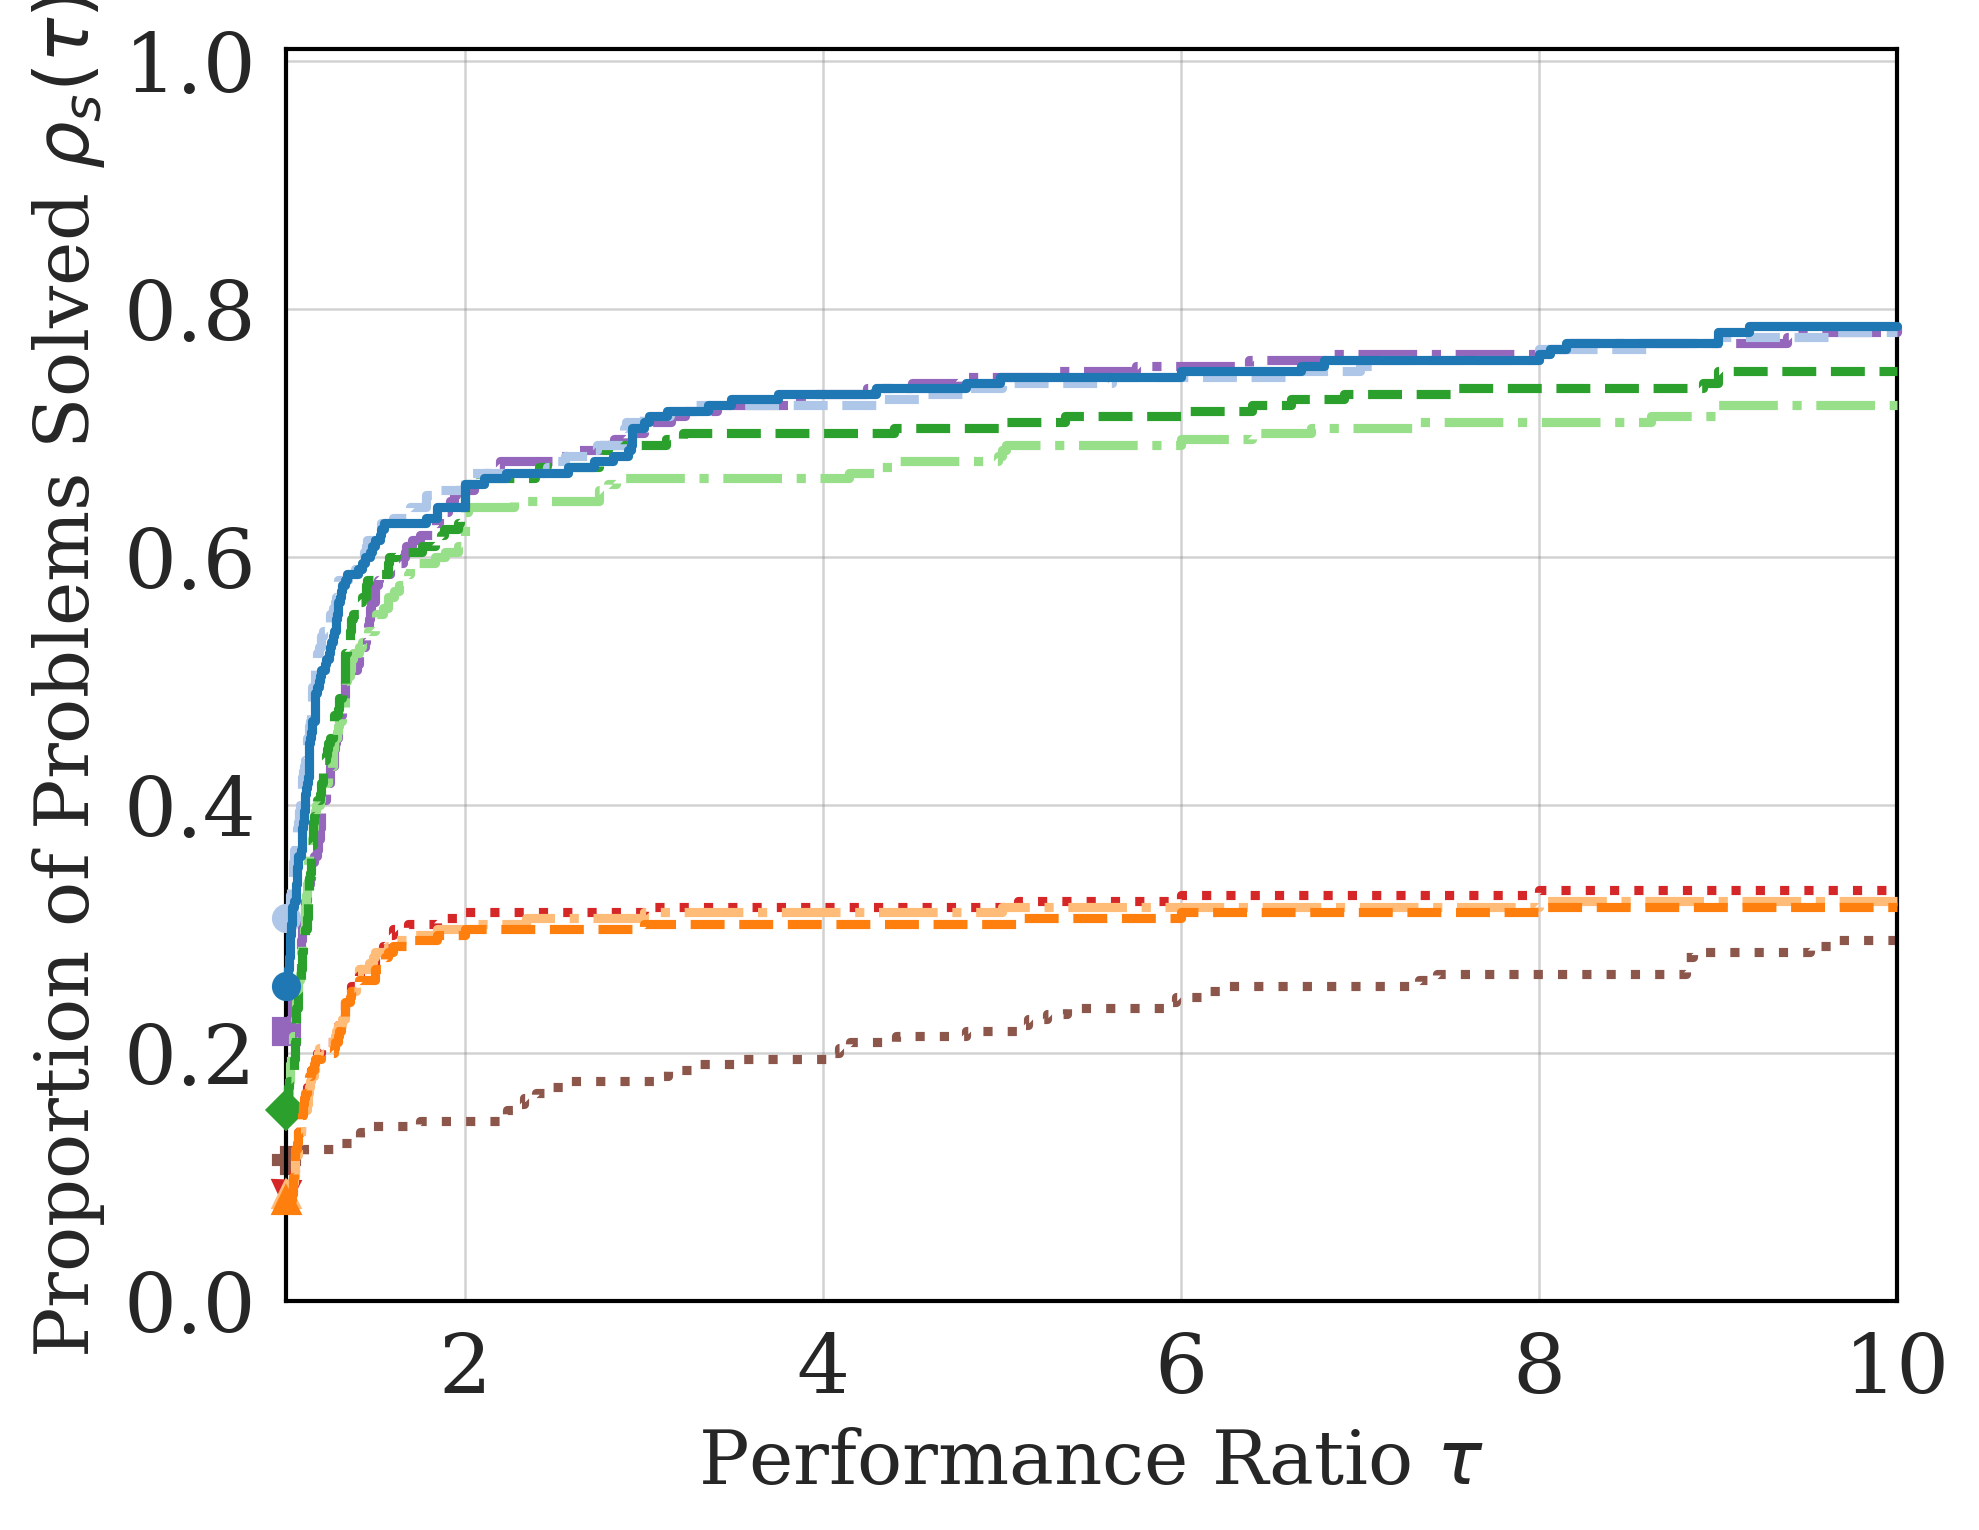

Saved figure to doc/imgs/compare/_dp_function_only_gtol1e-02.pdf


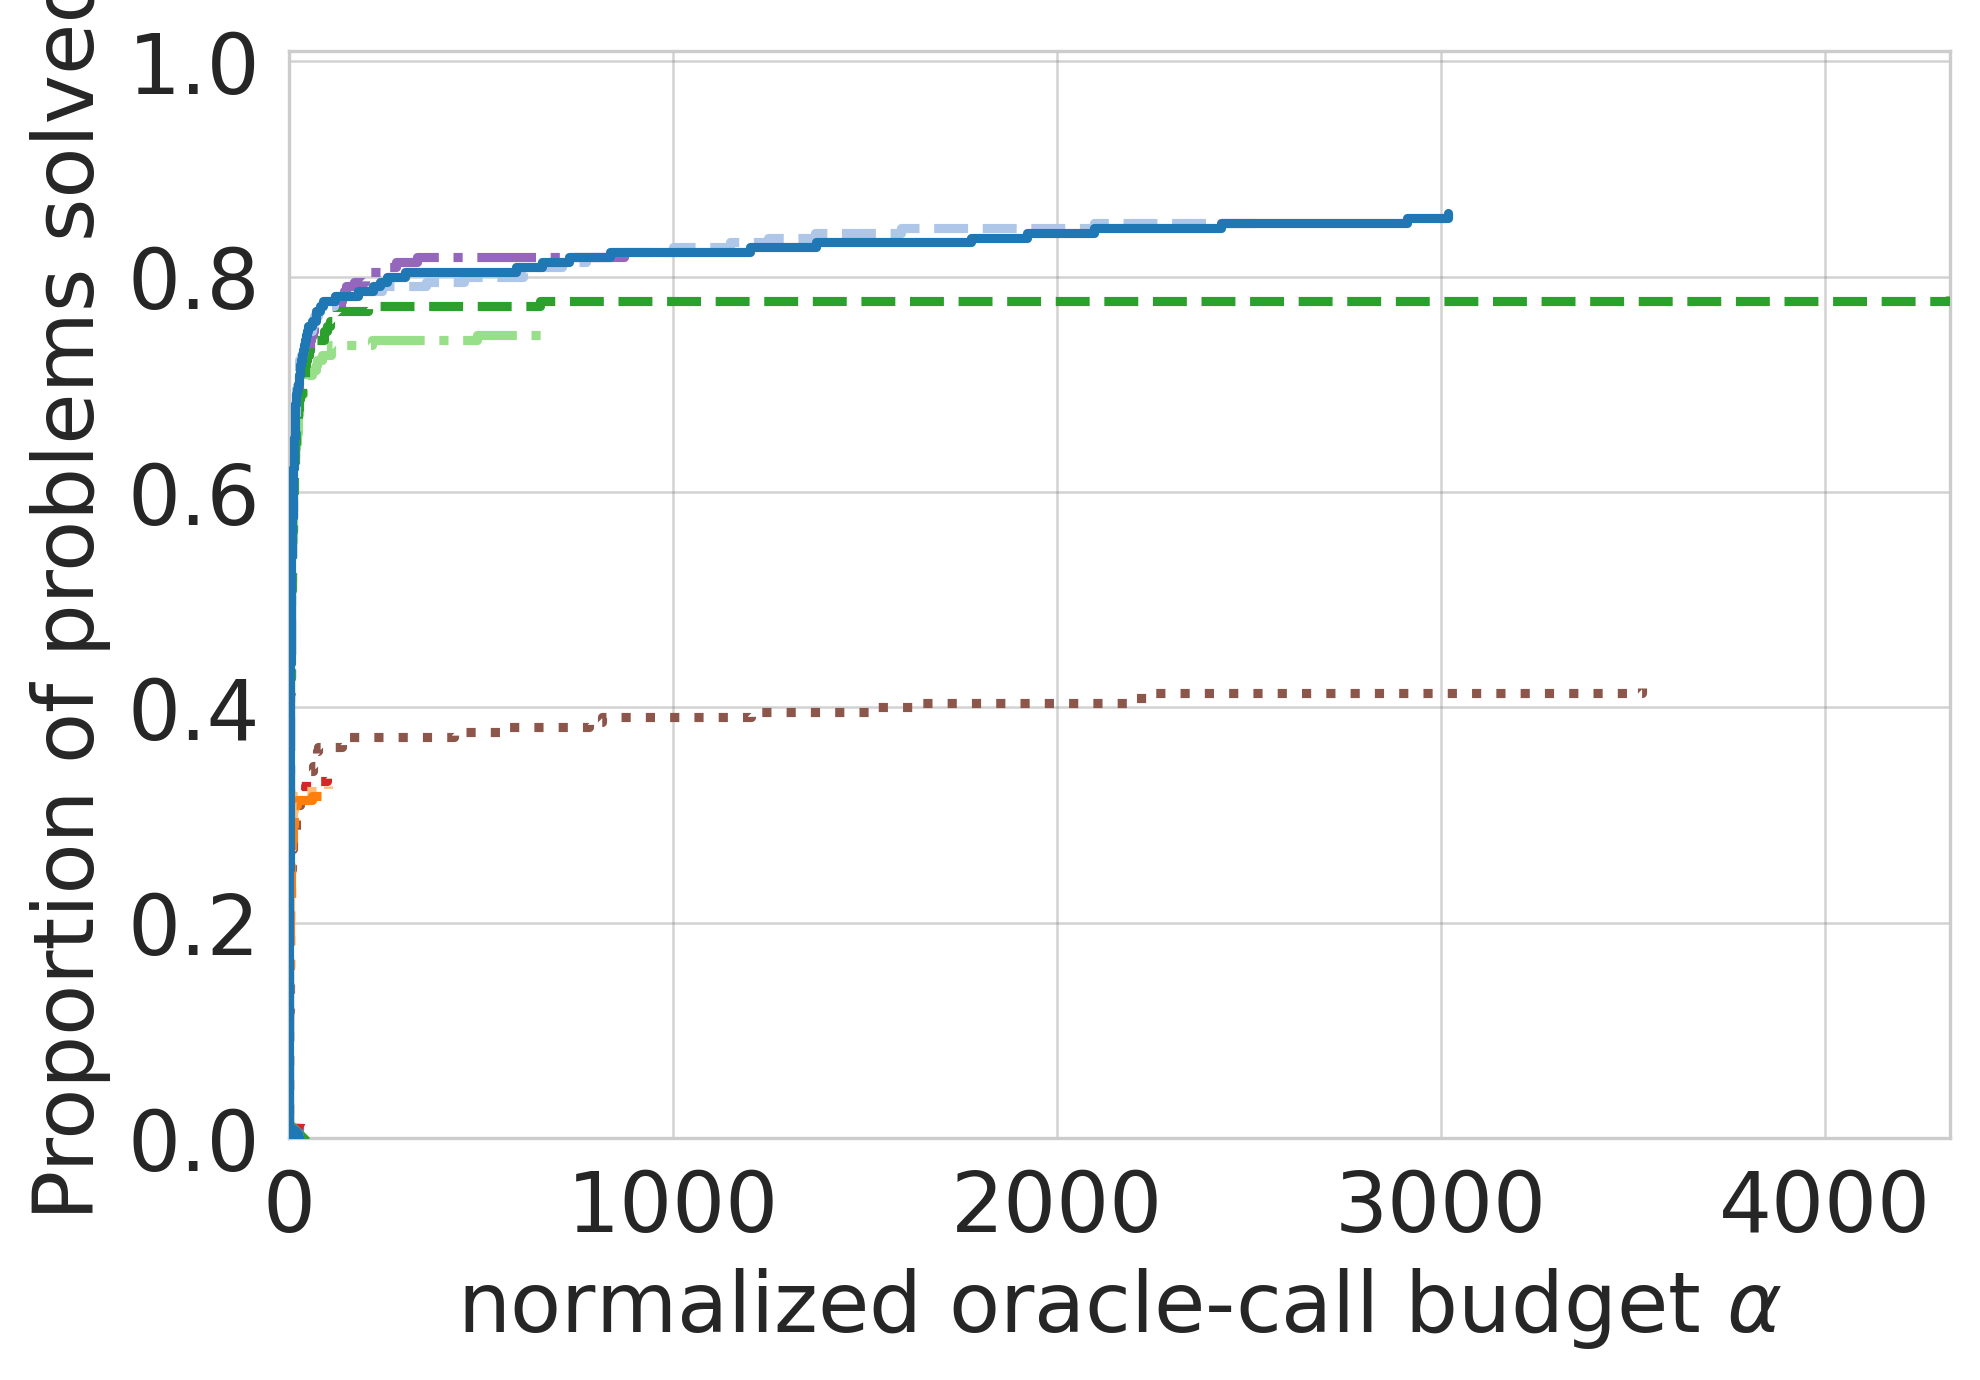

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),35.0,42.0,inf,inf,47.0,47.0,inf,inf,4924.0
ALLINITU (seed=0),23.0,25.0,22.0,24.0,20.0,22.0,22.0,23.0,49.0
ARGLINA (seed=0),6.0,6.0,8.0,8.0,14.0,14.0,8.0,5.0,12.0
ARGLINB (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0
ARGLINC (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),42.0,38.0,44.0,44.0,48.0,48.0,44.0,71.0,inf
YATP1LS (seed=0),130.0,126.0,inf,inf,46.0,46.0,inf,77.0,inf
YATP2LS (seed=0),inf,inf,48.0,48.0,51.0,51.0,48.0,26.0,inf
YFITU (seed=0),111.0,101.0,inf,inf,244.0,230.0,inf,213.0,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,85.909091,25.454545
NTRQN-MS,85.454545,30.909091
Line,32.272727,8.181818
Line-MS,32.727273,8.636364
Reg,78.181818,15.454545
Reg-Sec,75.000000,15.454545
SciPy,33.636364,8.636364
NTQN,82.272727,21.818182
ASTR1-Adagrad,41.818182,11.363636


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,216,4,0,27
NTRQN-MS,220,0,213,7,0,25
Line,220,0,220,0,0,149
Line-MS,220,0,220,0,0,148
Reg,220,0,217,1,2,45
Reg-Sec,220,0,219,1,0,54
SciPy,220,0,220,0,0,0
NTQN,220,0,219,1,0,1
ASTR1-Adagrad,220,0,216,4,0,124


flag,0,2,6
method,,,
NTQN,181,1,37


Saved figure to doc/imgs/compare/_pp_function_only_restart_gtol1e-02.pdf


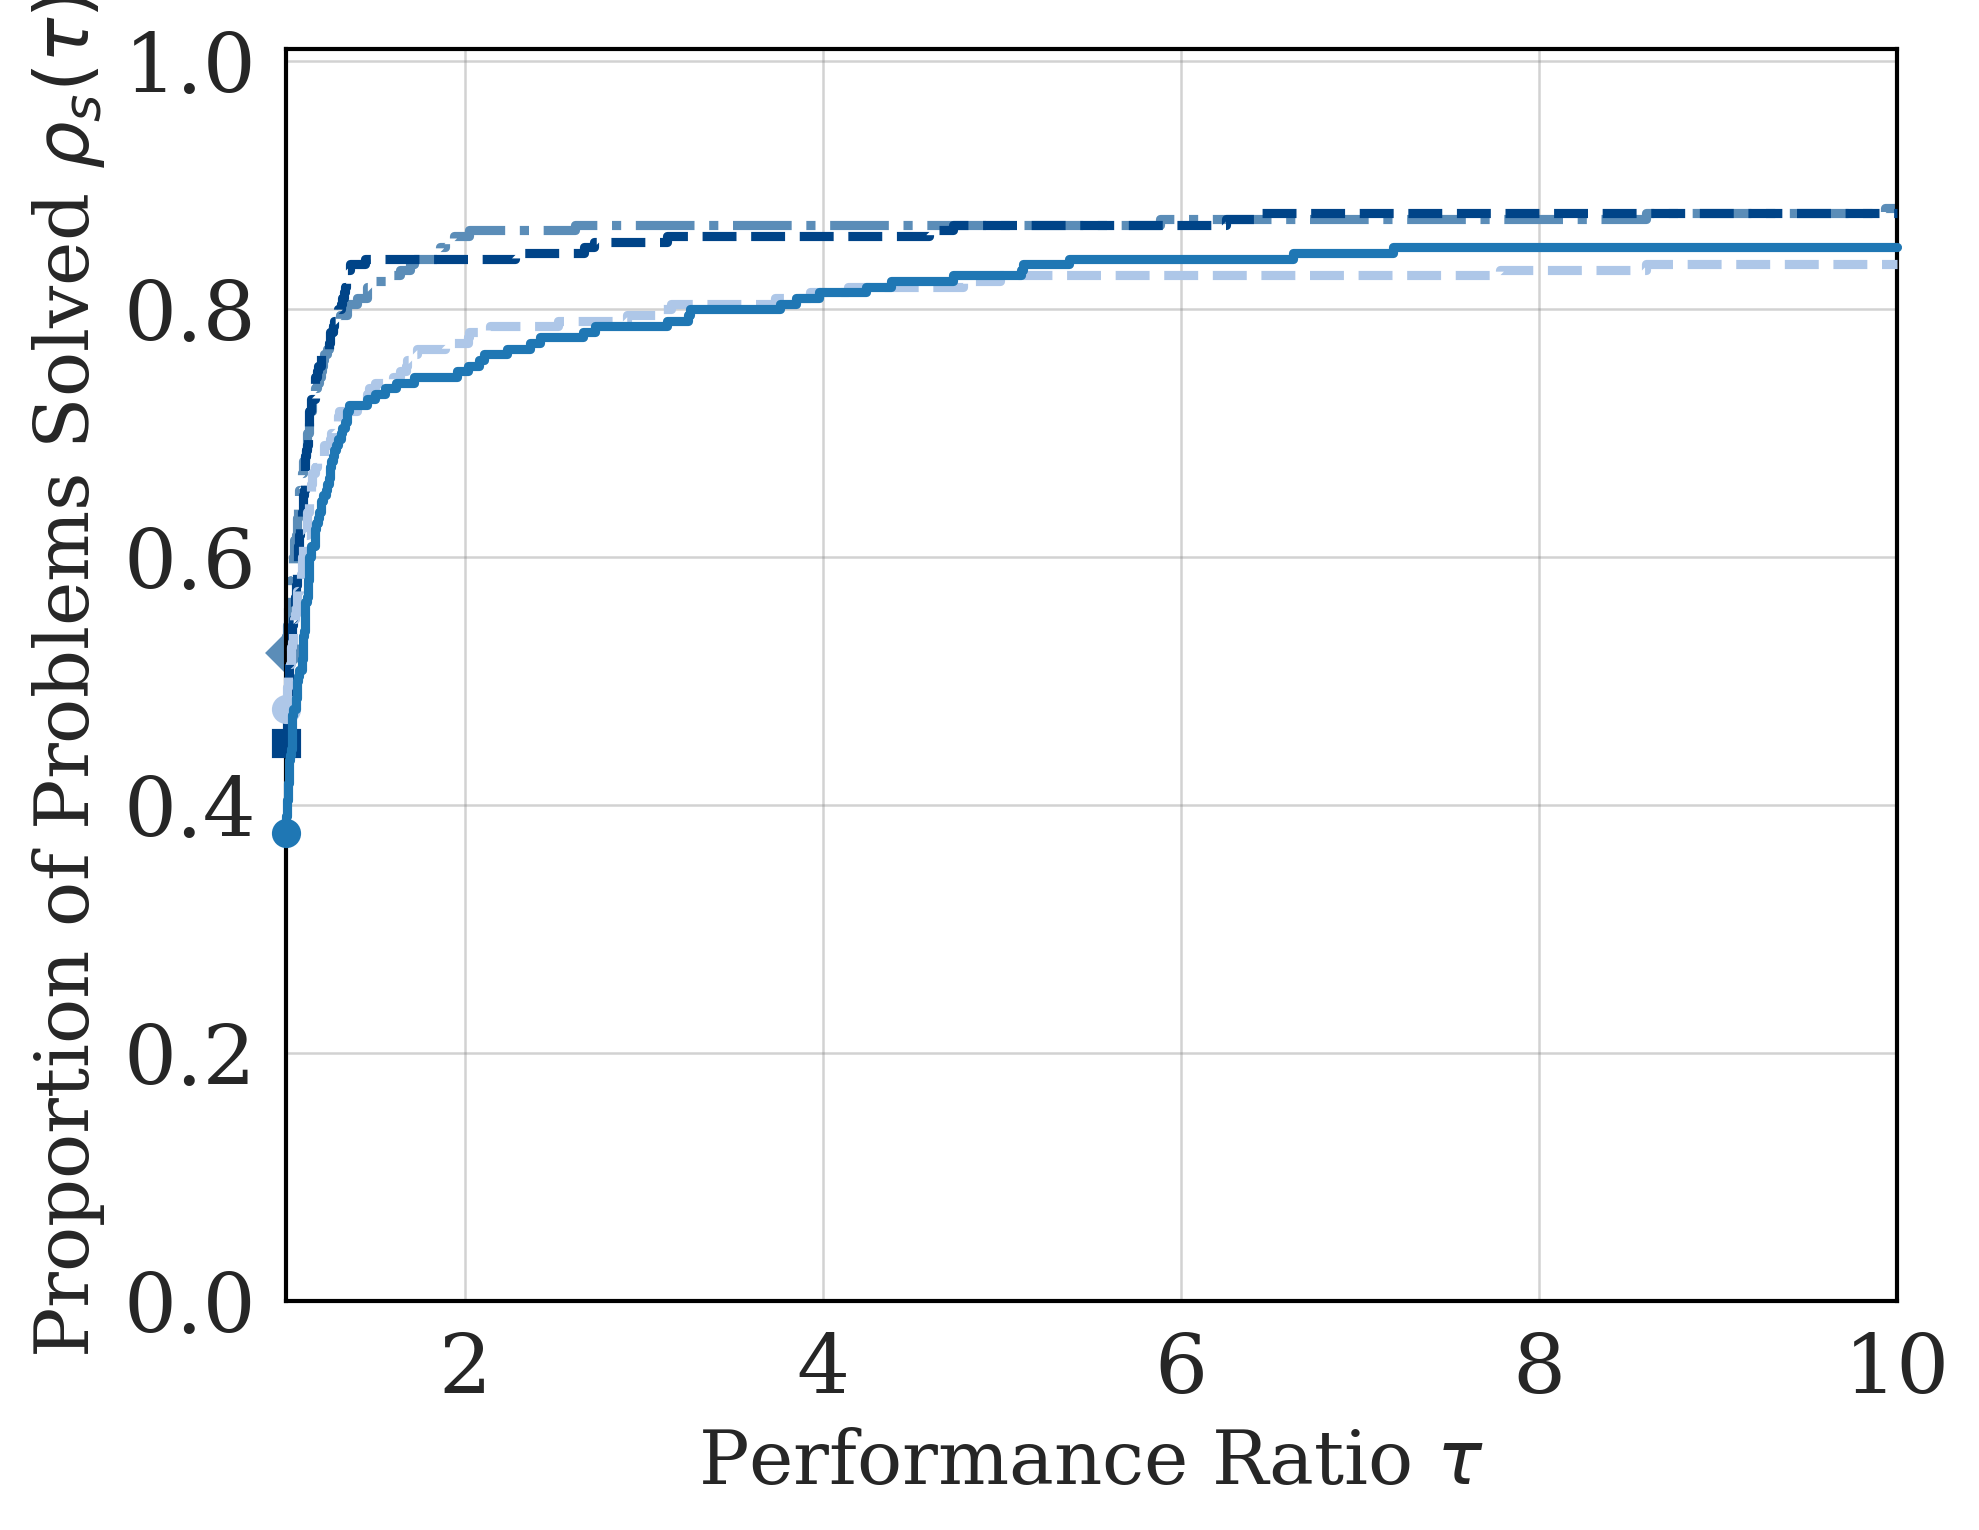

,solved (percent),"fastest, ties included (percent)"
NTRQN,85.909091,37.727273
NTRQN-MS,85.454545,47.727273
NTRQN-Restart,87.727273,45.000000
NTRQN-MS-Restart,88.636364,52.272727


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,216,4,0,27
NTRQN-MS,220,0,213,7,0,25
NTRQN-Restart,220,0,215,5,0,22
NTRQN-MS-Restart,220,0,213,7,0,18


,mean,median,maximum,cap reached
method,,,,
NTRQN-Restart,1.490909,0.0,10,12
NTRQN-MS-Restart,1.477273,0.0,10,11


Saved figure to doc/imgs/compare/_pp_ntqn_termination_gtol1e-02.pdf


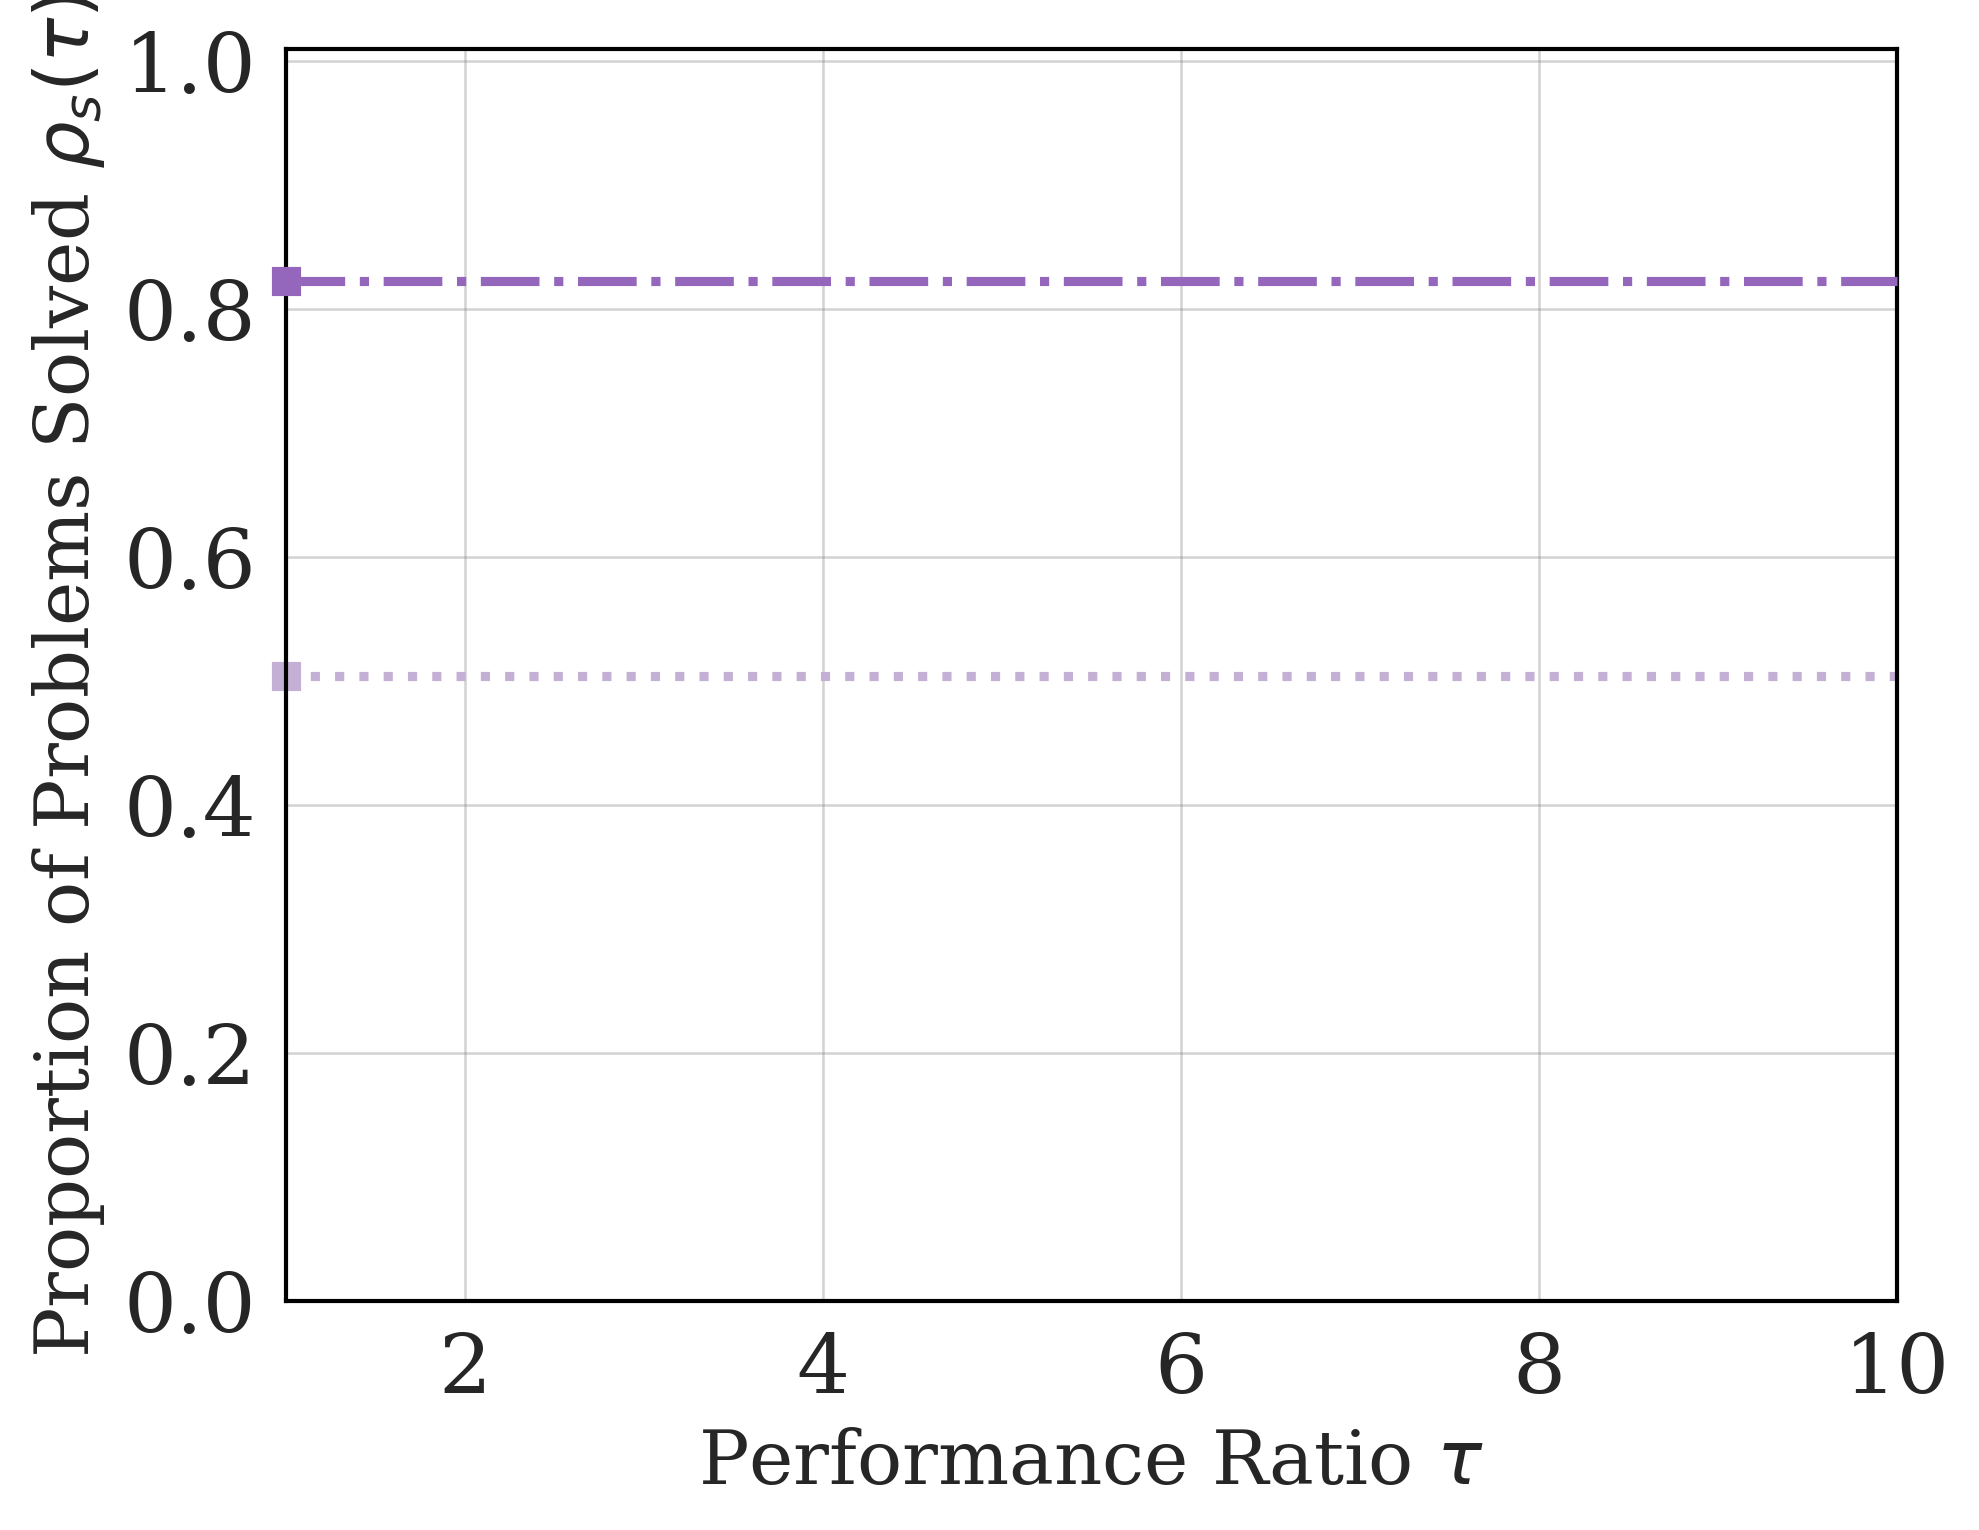

,solved (percent),"fastest, ties included (percent)"
NTQN,82.272727,82.272727
NTQN-Default-Termination,50.454545,50.454545


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTQN,220,0,219,1,0,1
NTQN-Default-Termination,220,0,220,0,0,0


flag,0,2,4,6
method,,,,
NTQN,181,1,0,37
NTQN-Default-Termination,90,0,124,6


Saved figure to doc/imgs/compare/_pp_noise0.001_gtol1e-02.pdf


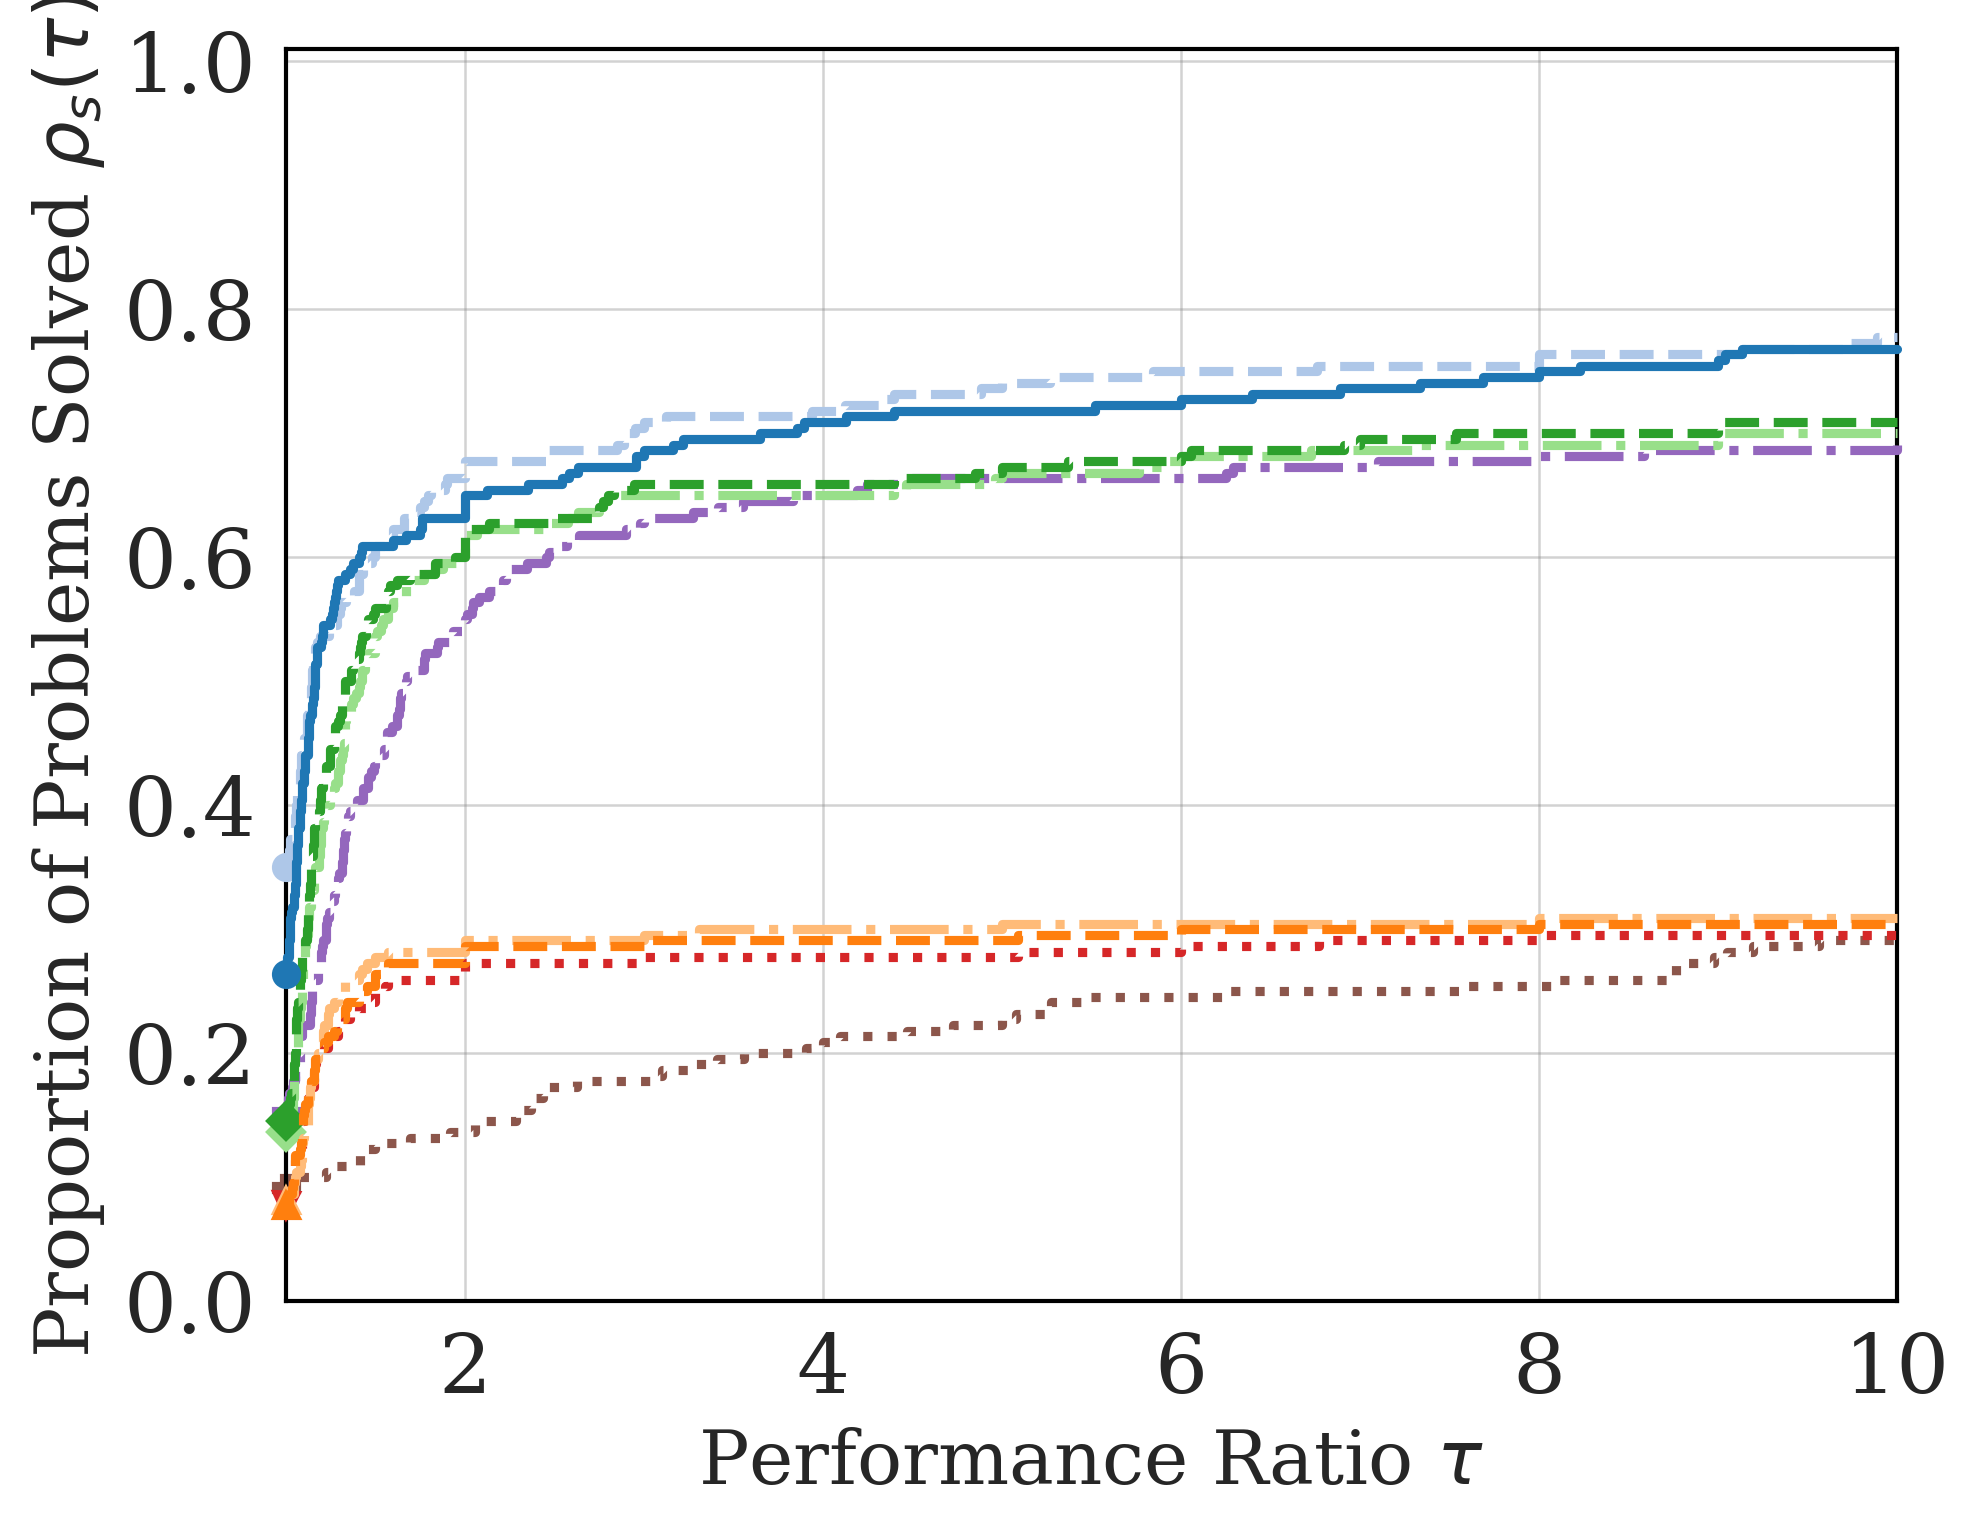

Saved figure to doc/imgs/compare/_dp_joint_noise_gtol1e-02.pdf


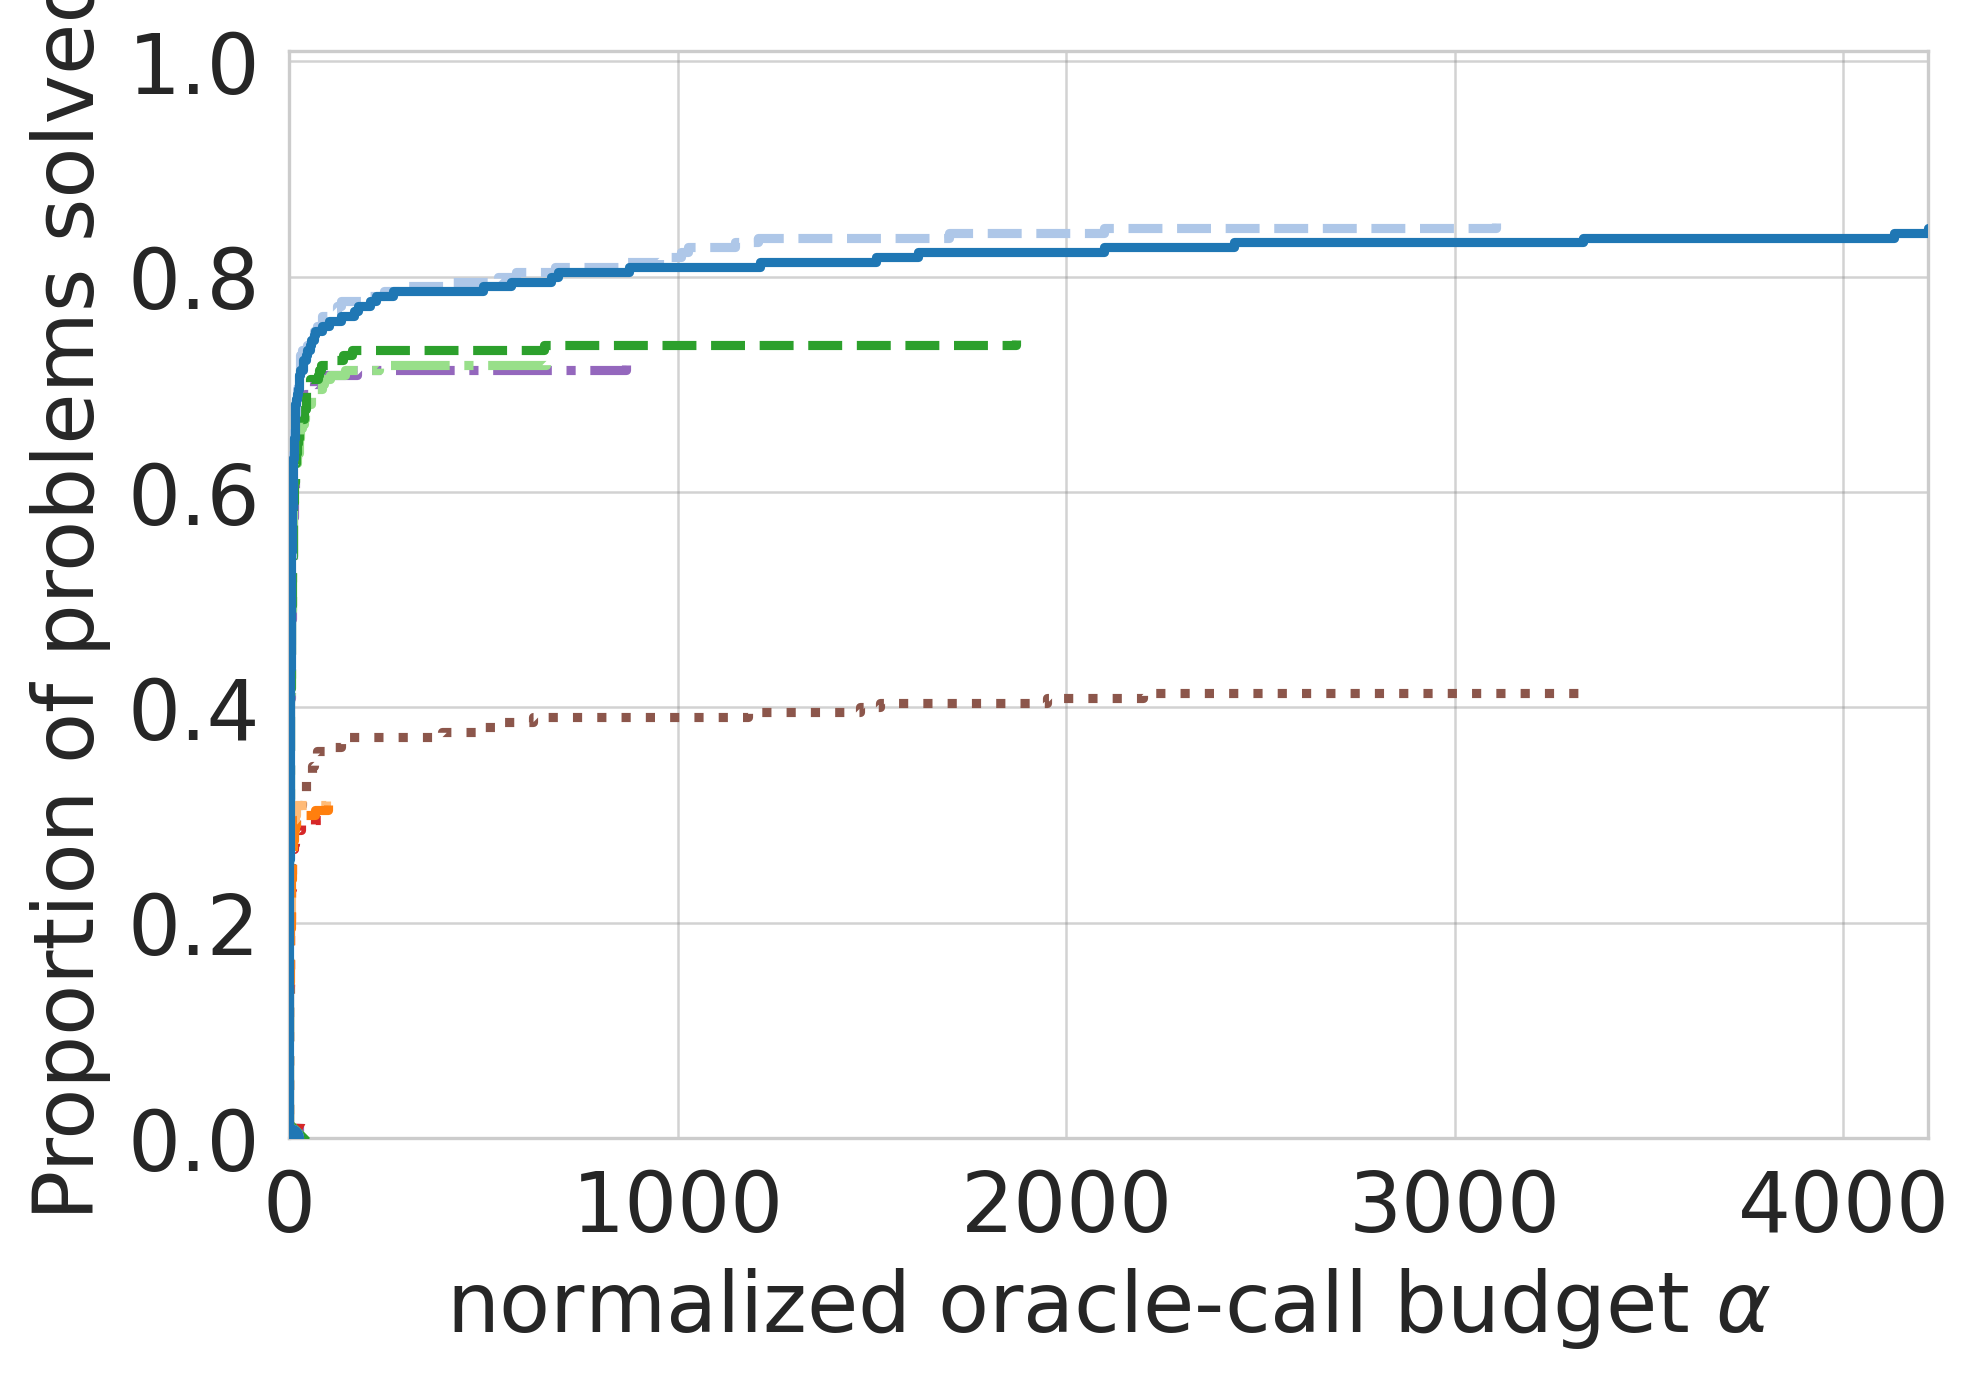

,NTRQN,NTRQN-MS,Line,Line-MS,Reg,Reg-Sec,SciPy,NTQN,ASTR1-Adagrad
AKIVA (seed=0),41.0,42.0,inf,inf,47.0,45.0,inf,inf,4560.0
ALLINITU (seed=0),23.0,23.0,22.0,24.0,20.0,22.0,22.0,23.0,49.0
ARGLINA (seed=0),8.0,8.0,10.0,10.0,14.0,14.0,10.0,5.0,12.0
ARGLINB (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0
ARGLINC (seed=0),8.0,8.0,inf,inf,11.0,11.0,inf,42.0,4.0
...,...,...,...,...,...,...,...,...,...
WOODS (seed=0),46.0,38.0,44.0,44.0,50.0,50.0,44.0,94.0,inf
YATP1LS (seed=0),452.0,inf,inf,inf,50.0,66.0,inf,132.0,inf
YATP2LS (seed=0),inf,inf,inf,86.0,182.0,129.0,inf,26.0,1230.0
YFITU (seed=0),706.0,6794.0,inf,inf,inf,223.0,inf,inf,inf


,solved (percent),"fastest, ties included (percent)"
NTRQN,84.545455,26.363636
NTRQN-MS,85.000000,35.000000
Line,30.909091,7.727273
Line-MS,31.363636,8.181818
Reg,74.090909,14.545455
Reg-Sec,72.272727,13.636364
SciPy,30.000000,7.727273
NTQN,71.818182,14.545455
ASTR1-Adagrad,41.818182,9.090909


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,212,8,0,26
NTRQN-MS,220,0,211,9,0,24
Line,220,0,220,0,0,152
Line-MS,220,0,220,0,0,151
Reg,220,0,217,1,2,69
Reg-Sec,220,0,219,1,0,67
SciPy,220,0,220,0,0,0
NTQN,220,0,215,5,0,1
ASTR1-Adagrad,220,0,216,4,0,124


flag,0,2,6
method,,,
NTQN,158,1,56


Saved figure to doc/imgs/compare/_pp_eps_under_gtol1e-02.pdf


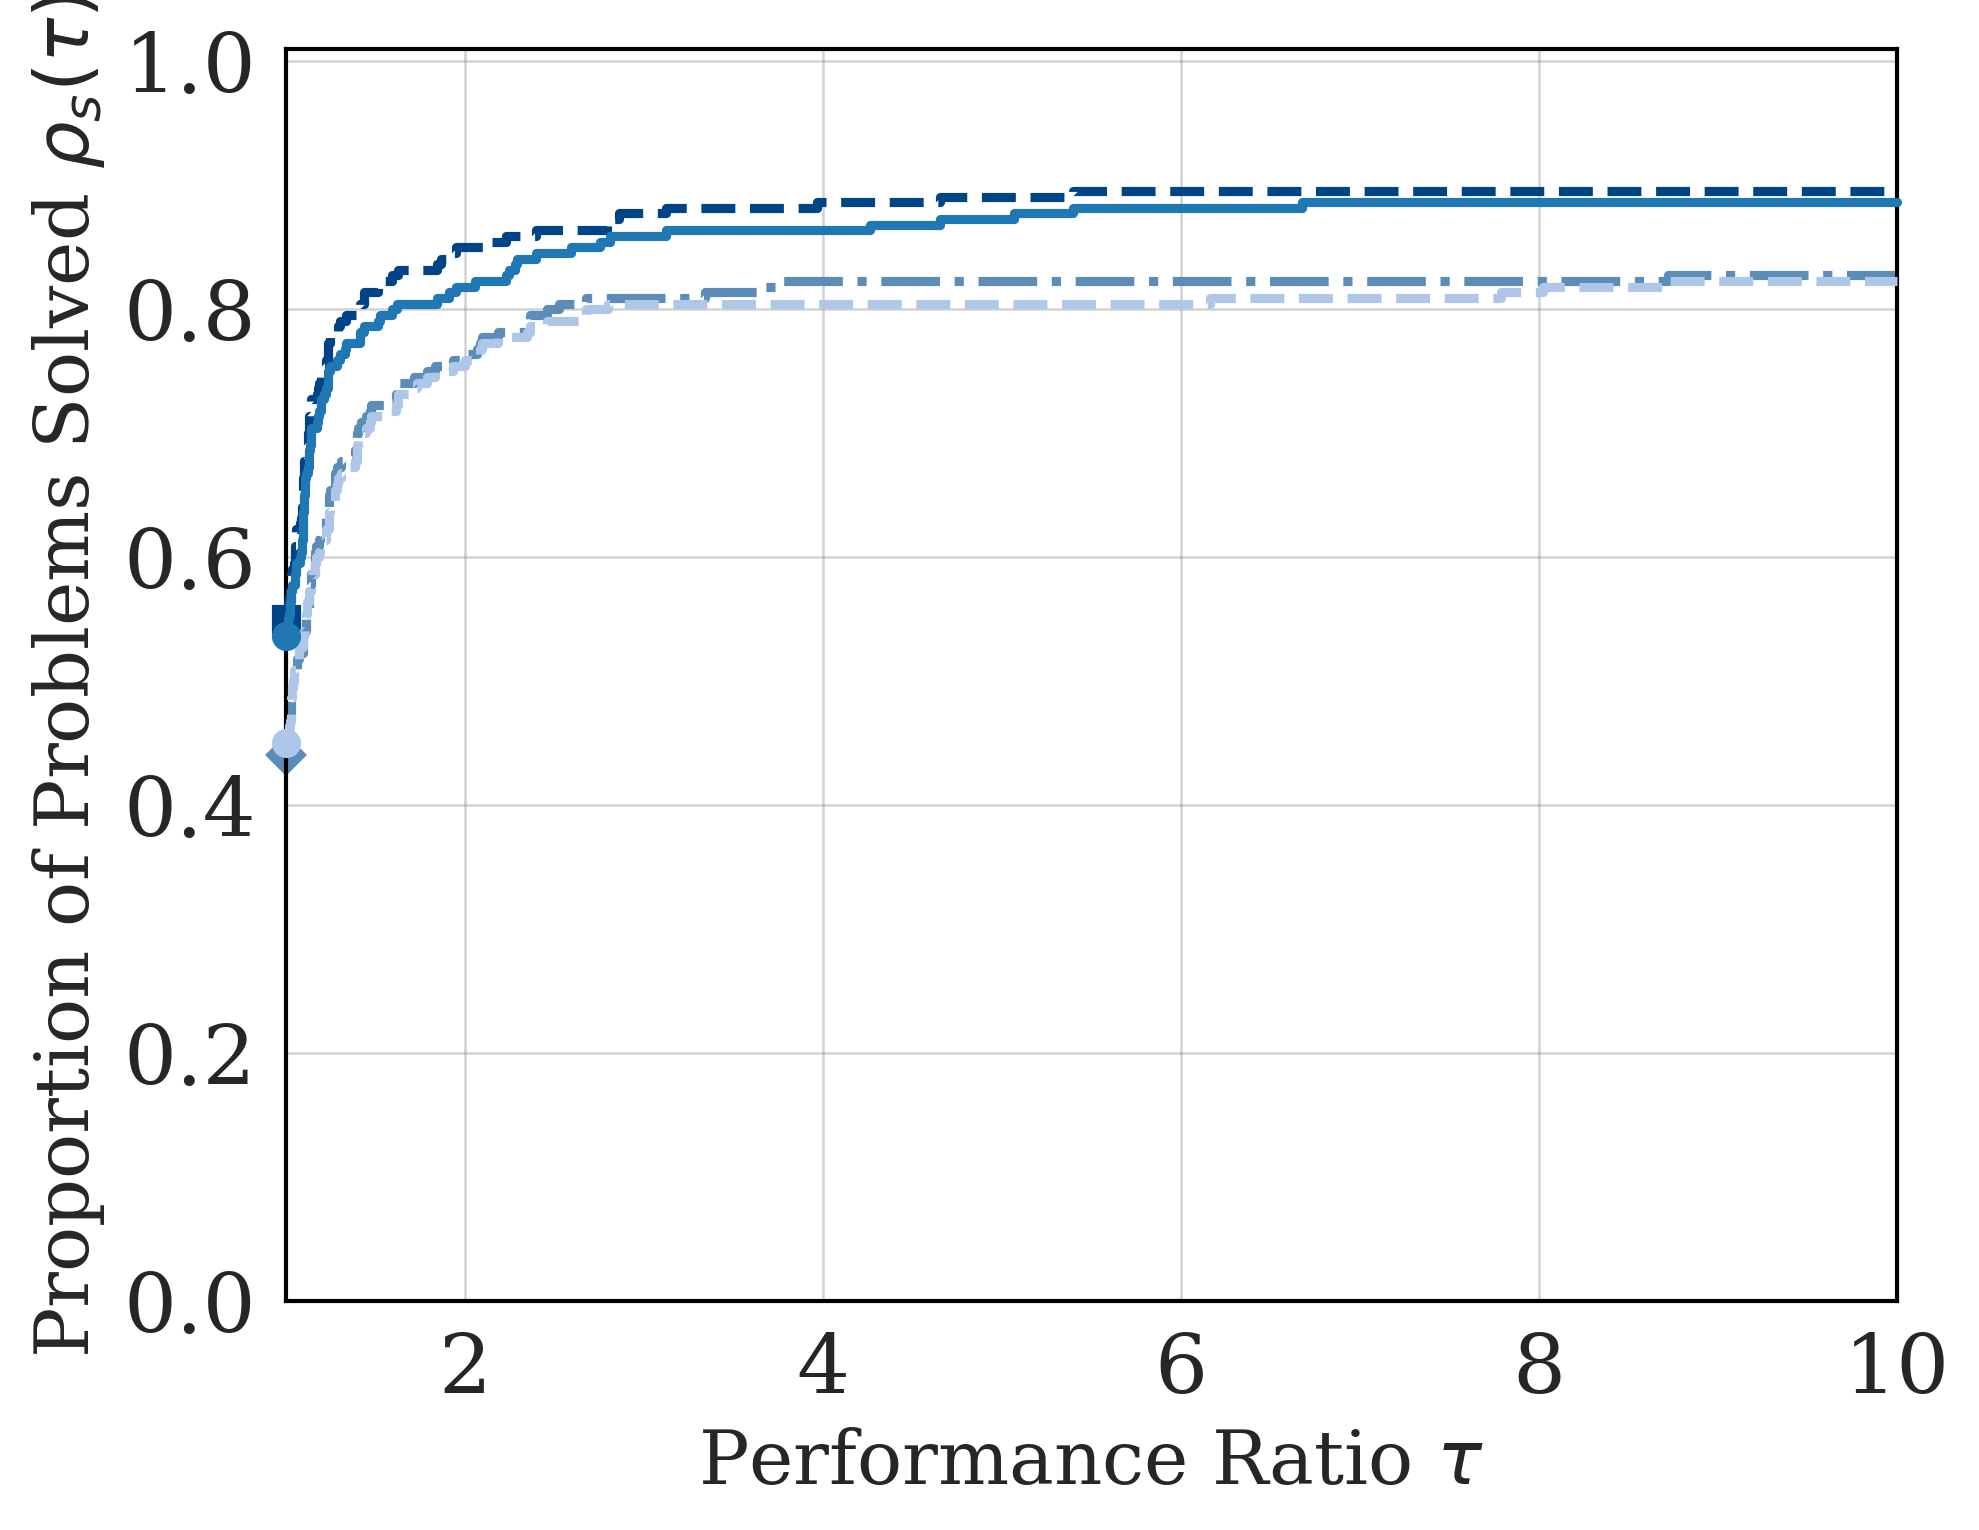

Skipping data profile because some result metadata lack dimensions.


,NTRQN,NTRQN-MS,NTRQN-Restart,NTRQN-MS-Restart
AKIVA (seed=0),47.0,38.0,47.0,38.0
ALLINITU (seed=0),21.0,23.0,21.0,23.0
ARGLINA (seed=0),6.0,6.0,6.0,6.0
ARGLINB (seed=0),8.0,8.0,8.0,8.0
ARGLINC (seed=0),8.0,8.0,8.0,8.0
...,...,...,...,...
WOODS (seed=0),42.0,38.0,42.0,38.0
YATP1LS (seed=0),39.0,36.0,39.0,36.0
YATP2LS (seed=0),122.0,124.0,53.0,47.0
YFITU (seed=0),217.0,216.0,217.0,216.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,88.636364,53.636364
NTRQN-MS,82.727273,45.000000
NTRQN-Restart,89.545455,55.000000
NTRQN-MS-Restart,83.636364,44.090909


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,214,6,0,19
NTRQN-MS,220,0,215,5,0,33
NTRQN-Restart,220,0,215,5,0,18
NTRQN-MS-Restart,220,0,215,5,0,31


,mean,median,maximum,cap reached
method,,,,
NTRQN-Restart,0.531818,0.0,10,5
NTRQN-MS-Restart,0.586364,0.0,10,6


Saved figure to doc/imgs/compare/_pp_eps_nominal_gtol1e-02.pdf


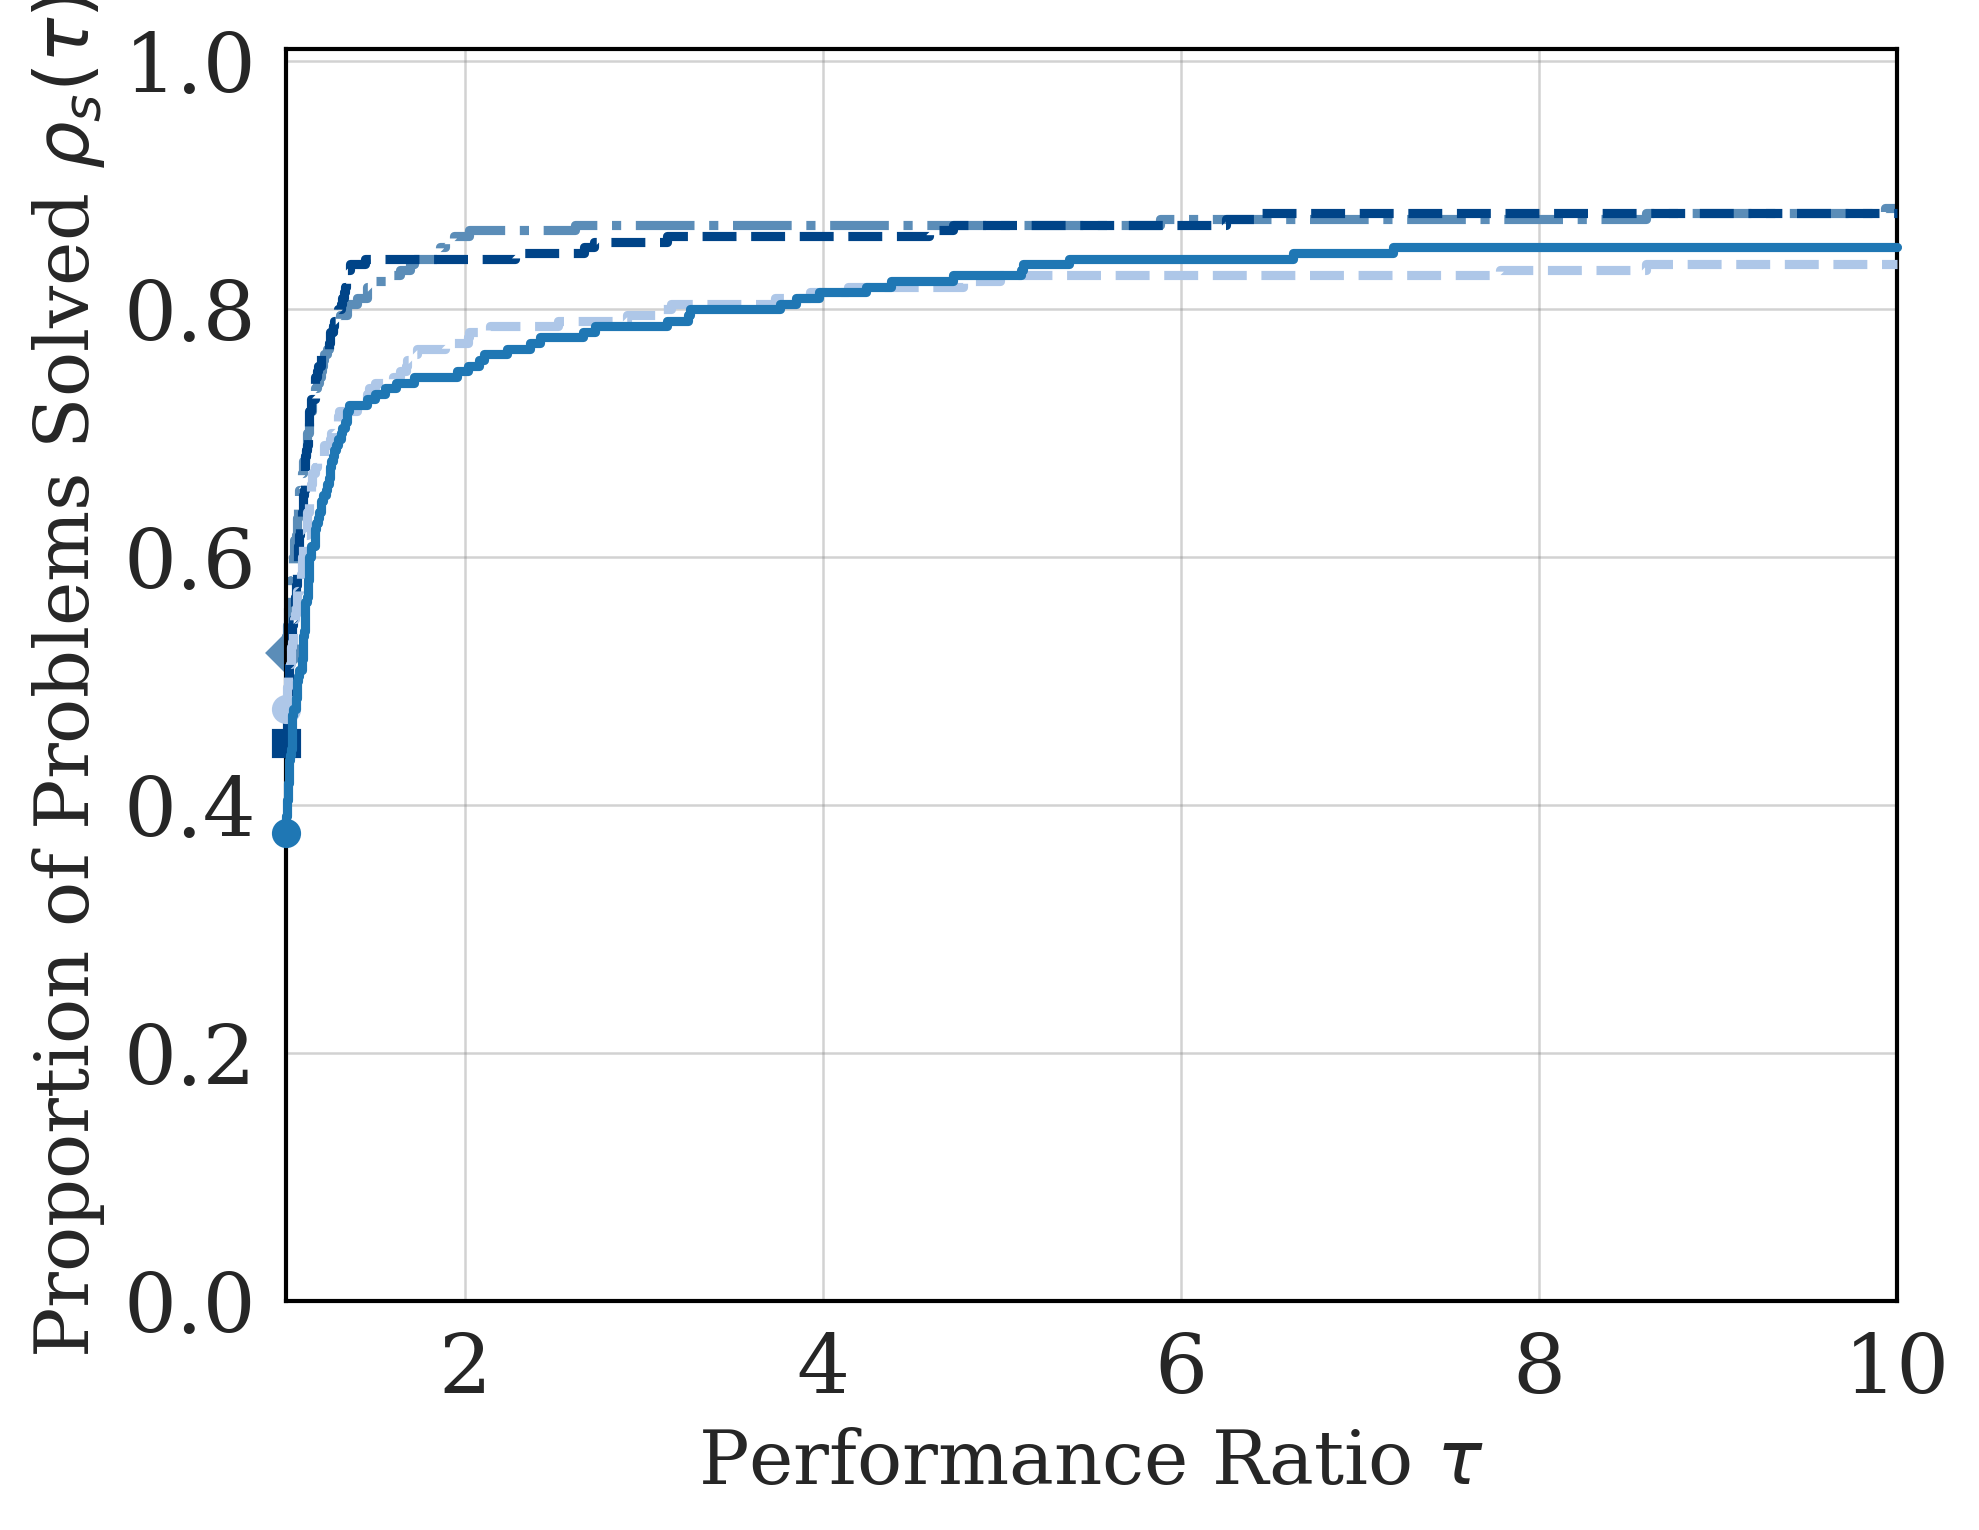

Skipping data profile because some result metadata lack dimensions.


,NTRQN,NTRQN-MS,NTRQN-Restart,NTRQN-MS-Restart
AKIVA (seed=0),35.0,42.0,35.0,42.0
ALLINITU (seed=0),23.0,25.0,23.0,25.0
ARGLINA (seed=0),6.0,6.0,6.0,6.0
ARGLINB (seed=0),8.0,8.0,8.0,8.0
ARGLINC (seed=0),8.0,8.0,8.0,8.0
...,...,...,...,...
WOODS (seed=0),42.0,38.0,42.0,38.0
YATP1LS (seed=0),130.0,126.0,43.0,40.0
YATP2LS (seed=0),inf,inf,inf,inf
YFITU (seed=0),111.0,101.0,109.0,103.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,85.909091,37.727273
NTRQN-MS,85.454545,47.727273
NTRQN-Restart,87.727273,45.000000
NTRQN-MS-Restart,88.636364,52.272727


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,216,4,0,27
NTRQN-MS,220,0,213,7,0,25
NTRQN-Restart,220,0,215,5,0,22
NTRQN-MS-Restart,220,0,213,7,0,18


,mean,median,maximum,cap reached
method,,,,
NTRQN-Restart,1.490909,0.0,10,12
NTRQN-MS-Restart,1.477273,0.0,10,11


Saved figure to doc/imgs/compare/_pp_eps_over_gtol1e-02.pdf


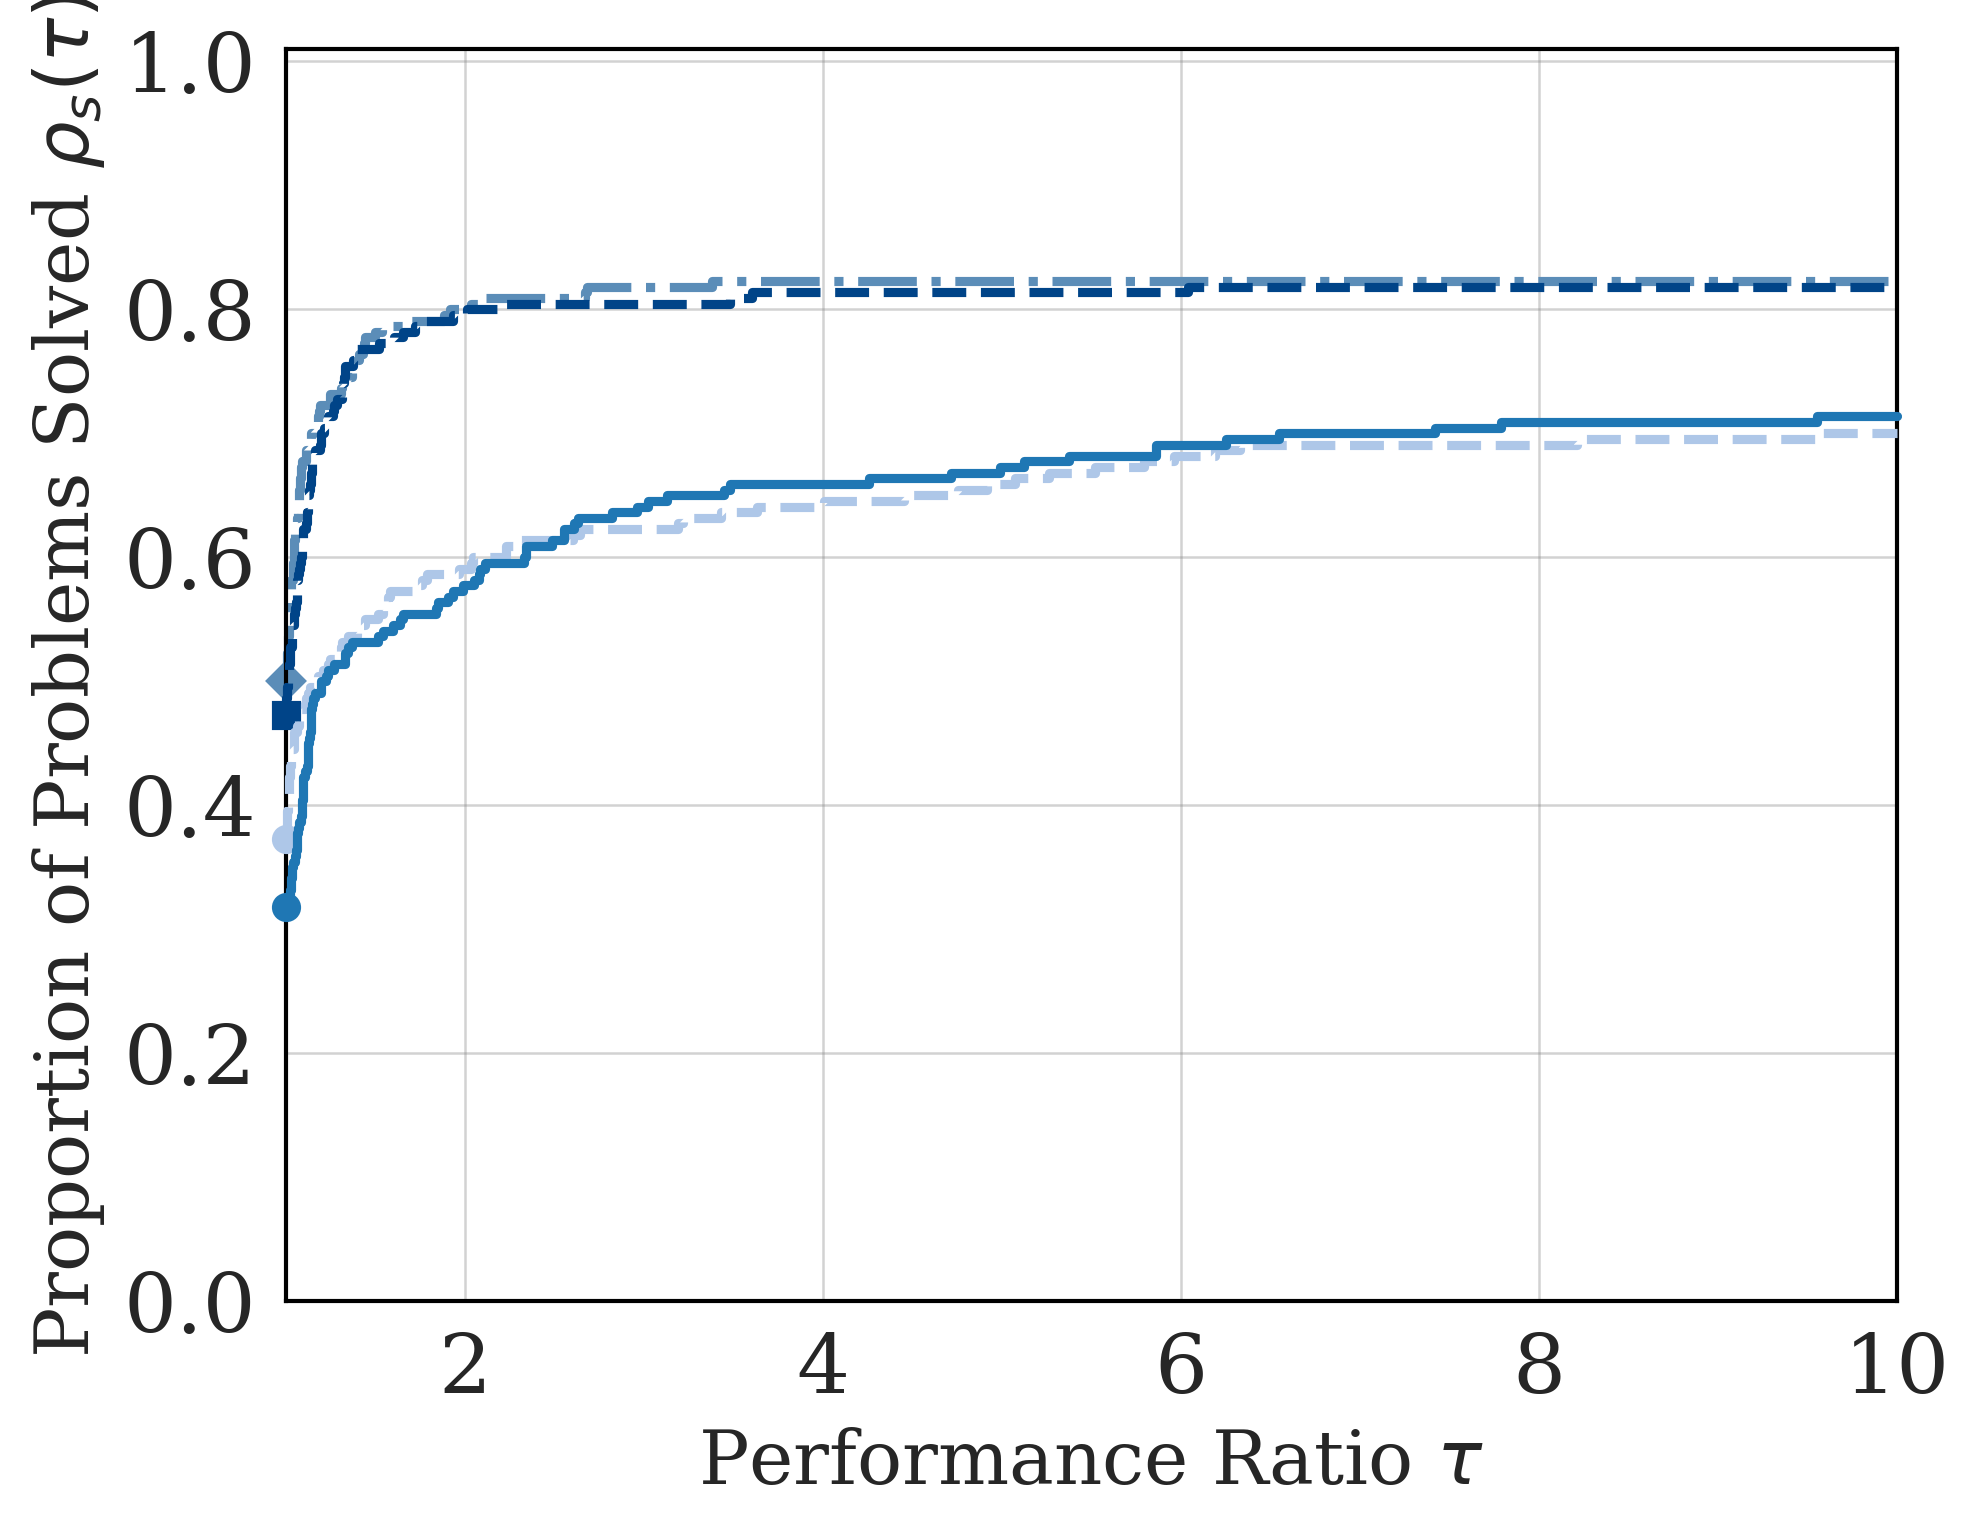

Skipping data profile because some result metadata lack dimensions.


,NTRQN,NTRQN-MS,NTRQN-Restart,NTRQN-MS-Restart
AKIVA (seed=0),55.0,53.0,49.0,51.0
ALLINITU (seed=0),23.0,21.0,23.0,21.0
ARGLINA (seed=0),8.0,8.0,8.0,8.0
ARGLINB (seed=0),10.0,10.0,10.0,10.0
ARGLINC (seed=0),8.0,10.0,8.0,10.0
...,...,...,...,...
WOODS (seed=0),275.0,inf,46.0,44.0
YATP1LS (seed=0),2148.0,1784.0,49.0,50.0
YATP2LS (seed=0),inf,inf,inf,inf
YFITU (seed=0),inf,23101.0,6727.0,6913.0


,solved (percent),"fastest, ties included (percent)"
NTRQN,75.909091,31.818182
NTRQN-MS,75.909091,37.272727
NTRQN-Restart,81.818182,47.272727
NTRQN-MS-Restart,82.727273,50.000000


,result files,missing files,completed,timeouts,exceptions,error return codes
method,,,,,,
NTRQN,220,0,212,8,0,45
NTRQN-MS,220,0,213,7,0,46
NTRQN-Restart,220,0,213,7,0,33
NTRQN-MS-Restart,220,0,213,7,0,31


,mean,median,maximum,cap reached
method,,,,
NTRQN-Restart,1.640909,1.0,10,10
NTRQN-MS-Restart,1.663636,1.0,10,10


In [13]:
SCENARIOS_TO_PLOT = [
    "float64",
    "float32",
    "float16",
    "function_only",
    "joint_noise",
    "eps_under",
    "eps_nominal",
    "eps_over",
]


def display_result_summaries(alg_names, calls, metadata):
    best_calls = calls.min(axis=0)
    fastest = (calls == best_calls) & np.isfinite(best_calls)[None, :]
    display(
        pd.DataFrame(
            {
                "solved (percent)": 100.0 * np.isfinite(calls).mean(axis=1),
                "fastest, ties included (percent)": 100.0 * fastest.mean(axis=1),
            },
            index=alg_names,
        )
    )
    display(summarize_run_metadata(alg_names, metadata))
    restart_summary, ntqn_summary = summarize_diagnostics(alg_names, metadata)
    if not restart_summary.empty:
        display(restart_summary.set_index("method"))
    if not ntqn_summary.empty:
        display(ntqn_summary)


_, ALGORITHM_COLORS, ALGORITHM_LINE_STYLES = get_methods()
for label in (
    "ASTR1-Adagrad",
    "NTRQN-Restart",
    "NTRQN-MS-Restart",
    "NTQN-Default-Termination",
):
    ALGORITHM_COLORS[label] = COLORS[label]
    ALGORITHM_LINE_STYLES[label] = LINE_STYLES[label]
for scenario in SCENARIOS_TO_PLOT:
    config = SCENARIOS[scenario]
    for gtol in config["score_gtols"]:
        seeds = get_scenario_seeds(scenario)
        primary_labels = METHODS_TO_RUN or SCENARIO_DEFAULT_LABELS[scenario]
        if scenario == "function_only" and METHODS_TO_RUN is None:
            primary_labels = primary_labels - {
                "NTRQN-Restart",
                "NTRQN-MS-Restart",
            }
        alg_names, calls, instances, metadata = load_scenario_results(
            scenario, seeds, gtol, labels=primary_labels
        )
        output_path = None
        if scenario not in {"float64", "float32", "float16", "joint_noise"}:
            gtol_name = f"{gtol:.0e}".replace("+", "")
            output_path = (
                Path("doc/imgs/compare") / f"_pp_{scenario}_gtol{gtol_name}.pdf"
            )
        draw_pp(
            alg_names,
            calls,
            ALGORITHM_COLORS,
            ALGORITHM_LINE_STYLES,
            config["precision"],
            np.float64(max(config["function_noise"], config["gradient_noise"])),
            np.float64(gtol),
            output_path=output_path,
        )
        table = pd.DataFrame(calls.T, index=instances, columns=alg_names)
        display(table)

        display_result_summaries(alg_names, calls, metadata)

        if len(seeds) > 1:
            solved_by_seed = []
            for seed in seeds:
                _, seed_calls, _, _ = load_scenario_results(
                    scenario, [seed], gtol, labels=primary_labels
                )
                solved_by_seed.append(np.isfinite(seed_calls).mean(axis=1))
            solved_by_seed = np.asarray(solved_by_seed)
            seed_summary = pd.DataFrame(
                {
                    "mean solved fraction": solved_by_seed.mean(axis=0),
                    "std. dev. across seeds": solved_by_seed.std(axis=0, ddof=1),
                },
                index=alg_names,
            )
            display(seed_summary)

        if scenario == "function_only" and METHODS_TO_RUN is None:
            restart_labels = {
                "NTRQN",
                "NTRQN-MS",
                "NTRQN-Restart",
                "NTRQN-MS-Restart",
            }
            restart_names, restart_calls, _, restart_metadata = (
                load_scenario_results(scenario, seeds, gtol, labels=restart_labels)
            )
            restart_stem = f"function_only_restart_gtol{gtol_name}"
            draw_pp(
                restart_names,
                restart_calls,
                ALGORITHM_COLORS,
                ALGORITHM_LINE_STYLES,
                config["precision"],
                np.float64(config["function_noise"]),
                np.float64(gtol),
                output_path=Path("doc/imgs/compare") / f"_pp_{restart_stem}.pdf",
            )
            display_result_summaries(restart_names, restart_calls, restart_metadata)

            termination_labels = {"NTQN", "NTQN-Default-Termination"}
            termination_names, termination_calls, _, termination_metadata = (
                load_scenario_results(scenario, seeds, gtol, labels=termination_labels)
            )
            draw_pp(
                termination_names,
                termination_calls,
                ALGORITHM_COLORS,
                ALGORITHM_LINE_STYLES,
                config["precision"],
                np.float64(config["function_noise"]),
                np.float64(gtol),
                output_path=(
                    Path("doc/imgs/compare")
                    / f"_pp_ntqn_termination_gtol{gtol_name}.pdf"
                ),
            )
            display_result_summaries(
                termination_names, termination_calls, termination_metadata
            )